# Введение

## Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

## Постановка задачи

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

# Описание датасета

Для работы выбран датасет [Industrial Equipment 🖥️Monitoring 🖲️Dataset](https://www.kaggle.com/datasets/dnkumars/industrial-equipment-monitoring-dataset). 

Этот датасет содержит симулированные данные, имитирующие мониторинг промышленного оборудования в реальном времени, включая турбины, компрессоры и насосы. Каждая строка датасета соответствует уникальному наблюдению и фиксирует ключевые параметры работы оборудования: температуру, давление, уровень вибрации и влажность. Также в набор данных включена информация о типе оборудования, месте его расположения и о том, считается ли оборудование неисправным.

Признаки:

| Название переменной | Тип переменной            | Описание                                                                                                      |
| ---------------     | ------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **temperature**     | Числовая                  | Температура оборудования в момент наблюдения (°C). Характеризует тепловой режим работы.                       |
| **pressure**        | Числовая                  | Давление в системе в момент наблюдения (bar). Отражает рабочие условия и возможные отклонения.                |
| **vibration**       | Числовая                  | Уровень вибрации (нормированные единицы). Повышенные значения могут сигнализировать о механических проблемах. |
| **humidity**        | Числовая                  | Влажность окружающей среды в месте установки оборудования (%). Влияет на условия эксплуатации.                |
| **equipment**       | Категориальная            | Тип промышленного оборудования (например, Turbine, Compressor, Pump).                                         |
| **location**        | Категориальная            | Локация/город, где находится оборудование (например, Atlanta, Chicago и т.д.).                                |
| **faulty**          | Категориальная (бинарная) | Индикатор неисправности: 0 — исправно, 1 — неисправно. Используется для анализа/проверки кластеров.           |







In [29]:
import pandas as pd
import math
import scipy.stats as stats
import matplotlib.pyplot as plt


df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## Информация о датасете

In [30]:
print("Размерность (rows, cols):", df.shape)

print("Число объектов (строк):", df.shape[0])
print("Число признаков (столбцов):", df.shape[1])

df.info()

Размерность (rows, cols): (440, 8)
Число объектов (строк): 440
Число признаков (столбцов): 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


Как мы видим в датасете отсутвуют пропуски. Признаки temperature, pressure, vibration, humidity являются числовыми, по ним мы и будем проводить кластеризацию. А признакники equipment, location, faulty - категориальные. При этом faulty явялется бинарным и имеет значения 0 или 1; equipment и location уже в виде текста.

## Дескриптивный анализ

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Channel,1.32,1.0,1,1,2,0.47,2.200000e-01,0.76,-1.43,p=3.796e-75 → Далеко от нормального
1,Region,2.54,3.0,3,1,3,0.77,6.000000e-01,-1.28,-0.10,p=2.728e-78 → Далеко от нормального
2,Fresh,12000.30,8504.0,3,3,112151,12647.33,1.599549e+08,2.56,11.54,p=8.977e-12 → Далеко от нормального
3,Milk,5796.27,3627.0,577,55,73498,7380.38,5.446997e+07,4.05,24.67,p=6.791e-19 → Далеко от нормального
4,Grocery,7951.28,4755.5,683,3,92780,9503.16,9.031010e+07,3.59,20.91,p=1.986e-16 → Далеко от нормального
5,Frozen,3071.93,1526.0,133,25,60869,4854.67,2.356785e+07,5.91,54.69,p=8.649e-28 → Далеко от нормального
6,Detergents_Paper,2881.49,816.5,3,3,40827,4767.85,2.273244e+07,3.63,19.01,p=1.810e-29 → Далеко от нормального
7,Delicassen,1524.87,965.5,3,3,47943,2820.11,7.952998e+06,11.15,170.69,p=2.306e-34 → Далеко от нормального


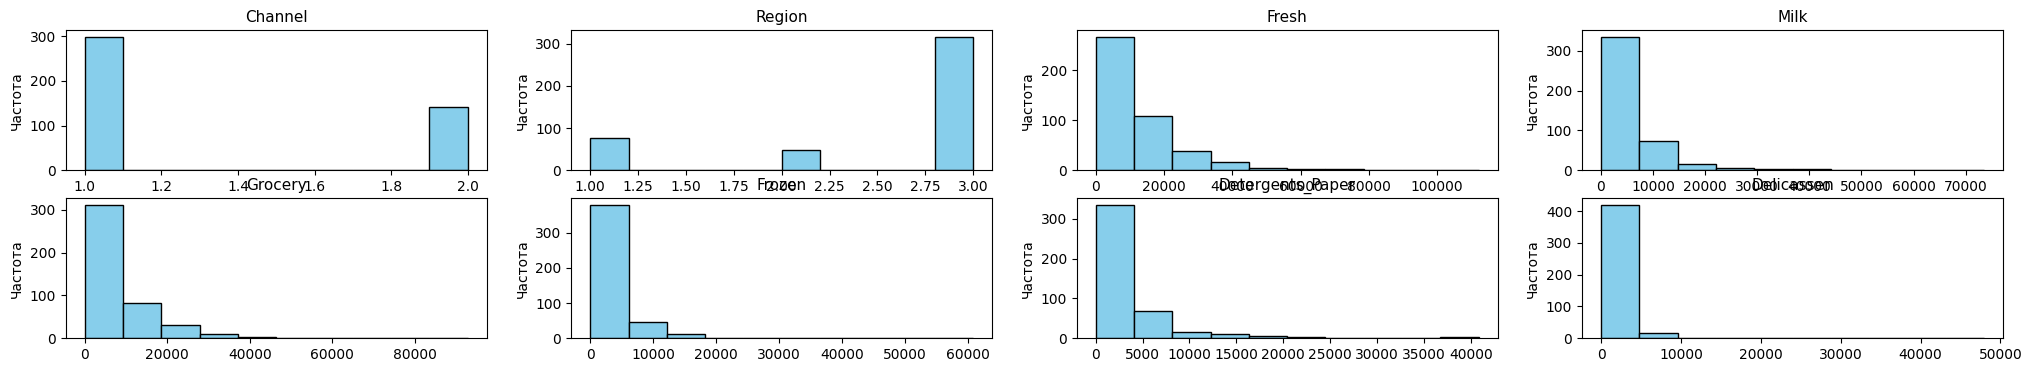

In [35]:
n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
features = df.columns
fig, axes = plt.subplots(2, 4, figsize=(25, 4))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    stat["Признак"].append(feature)
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    k_ = k if feature != "quality" else 6
    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

По гистограммам и рассчитанным показателям (асимметрия, эксцесс, тест Колмогорова–Смирнова) видно, что все числовые признаки далеки от нормального распределения.

temperature: среднее 70.92, медиана 70.16 — центр примерно совпадает, но асимметрия 0.94 и высокий эксцесс 5.41 указывают на вытянутый правый хвост и наличие экстремальных значений. Тест Колмогорова–Смирнова даёт p≈2.95e−63, то есть нормальность уверенно отвергается.

pressure: среднее 35.74, медиана 35.23, асимметрия 0.73 и эксцесс 2.36, распределение также с правым хвостом. p≈5.65e−19 → далеко от нормального.

vibration: заметно более «тяжёлое» распределение: асимметрия 1.49 и эксцесс 4.40, что говорит о сильной правосторонней асимметрии и пиковости, вероятно из-за редких режимов повышенной вибрации. p≈2.28e−53 → не нормально.

humidity: почти симметричное (асимметрия −0.02), эксцесс 0.82 — распределение ближе к «приплюснутому», но тест всё равно отвергает нормальность (p≈1.53e−3).

faulty: бинарная переменная (0/1), для неё нормальность в принципе неприменима, и KS-тест закономерно даёт p≈0.

Вывод: признаки имеют ненормальные распределения, что типично для сенсорных данных и не препятствует кластеризации. Однако это важно учитывать при выборе масштабирования (лучше StandardScaler или RobustScaler).





Отсутствие классов:
Для кластеризации используются только признаки-описания объекта. Переменная faulty является целевой/контрольной меткой (0 — норма, 1 — неисправность) и не должна включаться в кластеризацию.
Таким образом, условие “отсутствие заранее заданных классов” соблюдается: кластеры строятся без использования меток.

Осмысленность кластеризации:
Кластеризация здесь имеет практический смысл: по показаниям датчиков можно выделить режимы работы оборудования (нормальные и аномальные), а затем проверить, концентрируются ли неисправности в отдельных кластерах. Это соответствует задаче мониторинга промышленного оборудования.

Отсутствие выбросов / работа с выбросами:
По статистике видно наличие “тяжёлых хвостов”, особенно у temperature и vibration (высокий эксцесс и асимметрия). Это означает, что выбросы или экстремальные режимы вероятны.
Для сенсорных данных такие точки часто отражают реальные аварийные состояния, поэтому их не нужно автоматически удалять. Корректный подход:

проверить выбросы визуально (boxplot);

для кластеризации применить устойчивое масштабирование (например, RobustScaler), чтобы выбросы не “перетягивали” расстояния;

при необходимости можно отдельно отметить экстремальные точки как потенциальные аномалии.

Вывод: данные подходят для кластеризации; при этом из-за ненормальности и возможных выбросов нужно использовать нормализацию/масштабирование и интерпретировать экстремальные значения как возможные аномальные режимы.


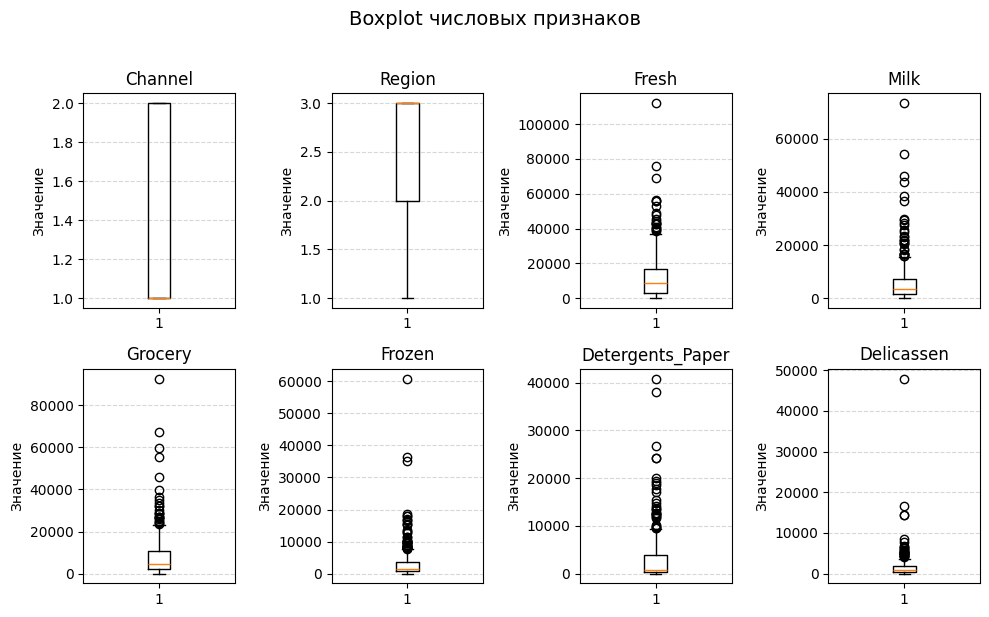

In [39]:
import matplotlib.pyplot as plt

num_cols = df.columns

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel("Значение")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Boxplot числовых признаков", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Судя по твоим boxplot’ам, картина такая:

temperature

Ящик (IQR) узкий вокруг ~65–75, медиана около 70.

Очень много точек выше верхнего уса (примерно >100) и заметно ниже нижнего (примерно <40).

Это означает длинные хвосты и много экстремальных режимов/значений → совпадает с высокой асимметрией и эксцессом в таблице.

pressure

Центр около 30–40, медиана ~35.

Есть выбросы и снизу (очень малые давления), и сверху (до ~80).

Хвосты тоже выраженные, но чуть спокойнее, чем у температуры.

vibration

Основная масса ~1.1–2.0, медиана ~1.5.

Сверху хвост до ~5 — много выбросов.

Есть и отрицательные значения (ниже 0). Для “нормированных единиц” это может быть допустимо (если нормировка относительно нуля), но это точно экстремальные режимы.

humidity

Основная масса ~40–60, медиана ~50.

Выбросы есть, но меньше “катастрофы”, чем в temperature/vibration; хвосты вверх до ~90 и вниз до ~10–20.

По boxplot-графикам выявлены выраженные выбросы в сенсорных признаках, особенно temperature и vibration. Для данных мониторинга оборудования эти экстремальные значения интерпретируются как возможные аномальные режимы работы, поэтому они не удалялись. Для снижения влияния выбросов на расстояния при кластеризации применялось устойчивое масштабирование RobustScaler.

In [42]:
from sklearn.preprocessing import RobustScaler

num_cols = df.columns

# только числовые признаки
X_num = df[num_cols].copy()

# RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_num)

# обратно в DataFrame для удобства
df_scaled = df.copy()
df_scaled[num_cols] = X_scaled

df_scaled.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.0,0.0,0.301680,1.065712,0.329952,-0.466572,0.506787,0.263810
1,1.0,0.0,-0.104810,1.092934,0.565993,0.083926,0.675670,0.574008
2,1.0,0.0,-0.155802,0.915816,0.344418,0.312589,0.736512,4.871459
3,0.0,0.0,0.344850,-0.429714,-0.062862,1.734708,-0.084442,0.582507
4,1.0,0.0,1.022092,0.315171,0.287260,0.849573,0.262056,2.988314


Для масштабирования числовых признаков выбран метод RobustScaler, так как по boxplot-графикам выявлены выраженные выбросы в признаках temperature и vibration, а также ненормальные распределения всех сенсорных параметров. RobustScaler использует медиану и межквартильный размах (IQR), поэтому устойчив к экстремальным значениям и не позволяет выбросам доминировать в метрике расстояния, что критично для алгоритмов кластеризации на основе расстояний.

<Figure size 1000x1000 with 0 Axes>

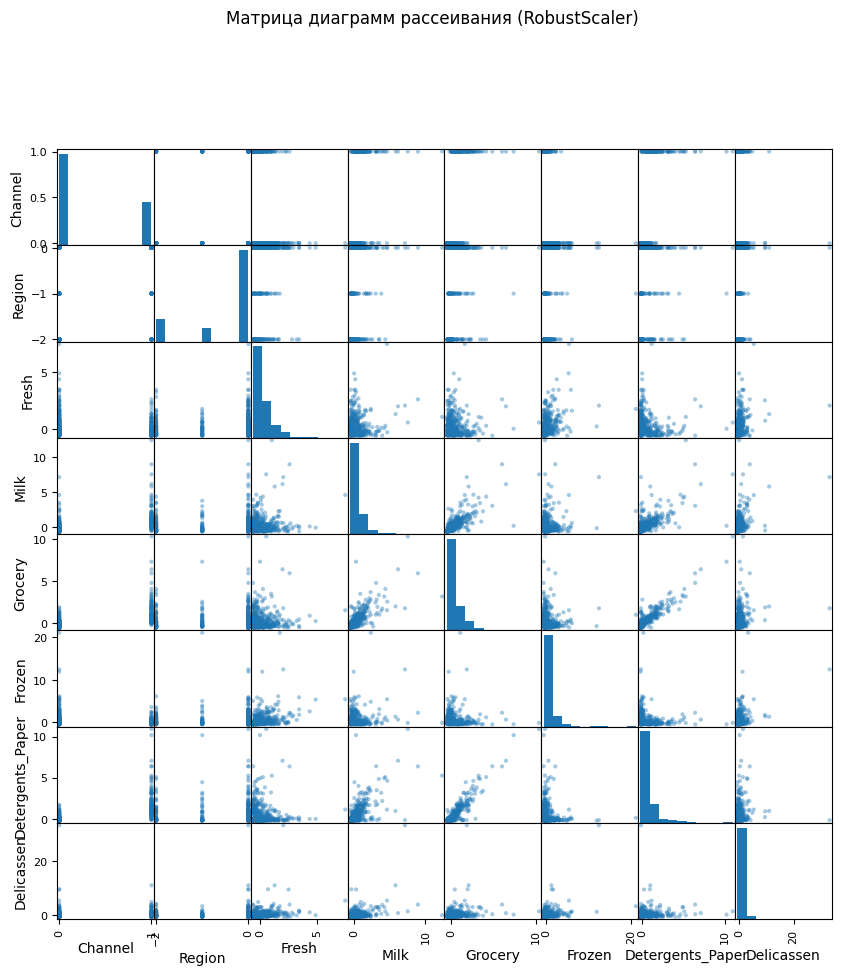

In [43]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# матрица рассеивания на RobustScaler-данных
plt.figure(figsize=(10, 10))
scatter_matrix(
    df_scaled[num_cols],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.4
)
plt.suptitle("Матрица диаграмм рассеивания (RobustScaler)", y=1.02)
plt.show()


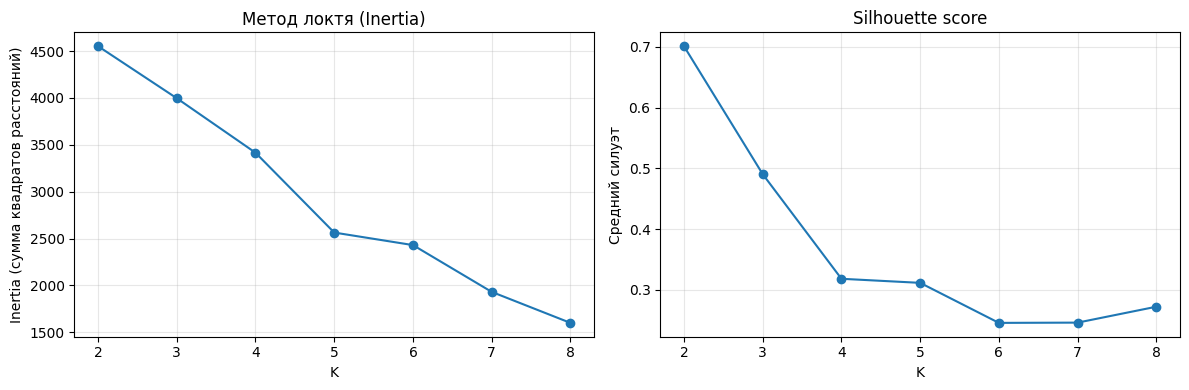

K=2: inertia=4552.48, silhouette=0.701
K=3: inertia=3997.06, silhouette=0.491
K=4: inertia=3415.54, silhouette=0.318
K=5: inertia=2563.65, silhouette=0.312
K=6: inertia=2429.92, silhouette=0.246
K=7: inertia=1930.61, silhouette=0.246
K=8: inertia=1599.86, silhouette=0.272


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

num_cols = df.columns

X = df_scaled[num_cols].values  # уже RobustScaler!

Ks = range(2, 9)  # обычно смотрят 2..8
inertias = []
silhouettes = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# --- графики локтя и силуэта на одной картинке ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(Ks, inertias, marker='o')
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia (сумма квадратов расстояний)")
axes[0].grid(alpha=0.3)

axes[1].plot(Ks, silhouettes, marker='o')
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# табличкой, чтобы проще было выбрать
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")


Размерность (rows, cols): (7195, 26)

Типы признаков и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7195 entries, 0 to 7194
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MFCCs_ 1  7195 non-null   float64
 1   MFCCs_ 2  7195 non-null   float64
 2   MFCCs_ 3  7195 non-null   float64
 3   MFCCs_ 4  7195 non-null   float64
 4   MFCCs_ 5  7195 non-null   float64
 5   MFCCs_ 6  7195 non-null   float64
 6   MFCCs_ 7  7195 non-null   float64
 7   MFCCs_ 8  7195 non-null   float64
 8   MFCCs_ 9  7195 non-null   float64
 9   MFCCs_10  7195 non-null   float64
 10  MFCCs_11  7195 non-null   float64
 11  MFCCs_12  7195 non-null   float64
 12  MFCCs_13  7195 non-null   float64
 13  MFCCs_14  7195 non-null   float64
 14  MFCCs_15  7195 non-null   float64
 15  MFCCs_16  7195 non-null   float64
 16  MFCCs_17  7195 non-null   float64
 17  MFCCs_18  7195 non-null   float64
 18  MFCCs_19  7195 non-null   float64
 19  MFCC

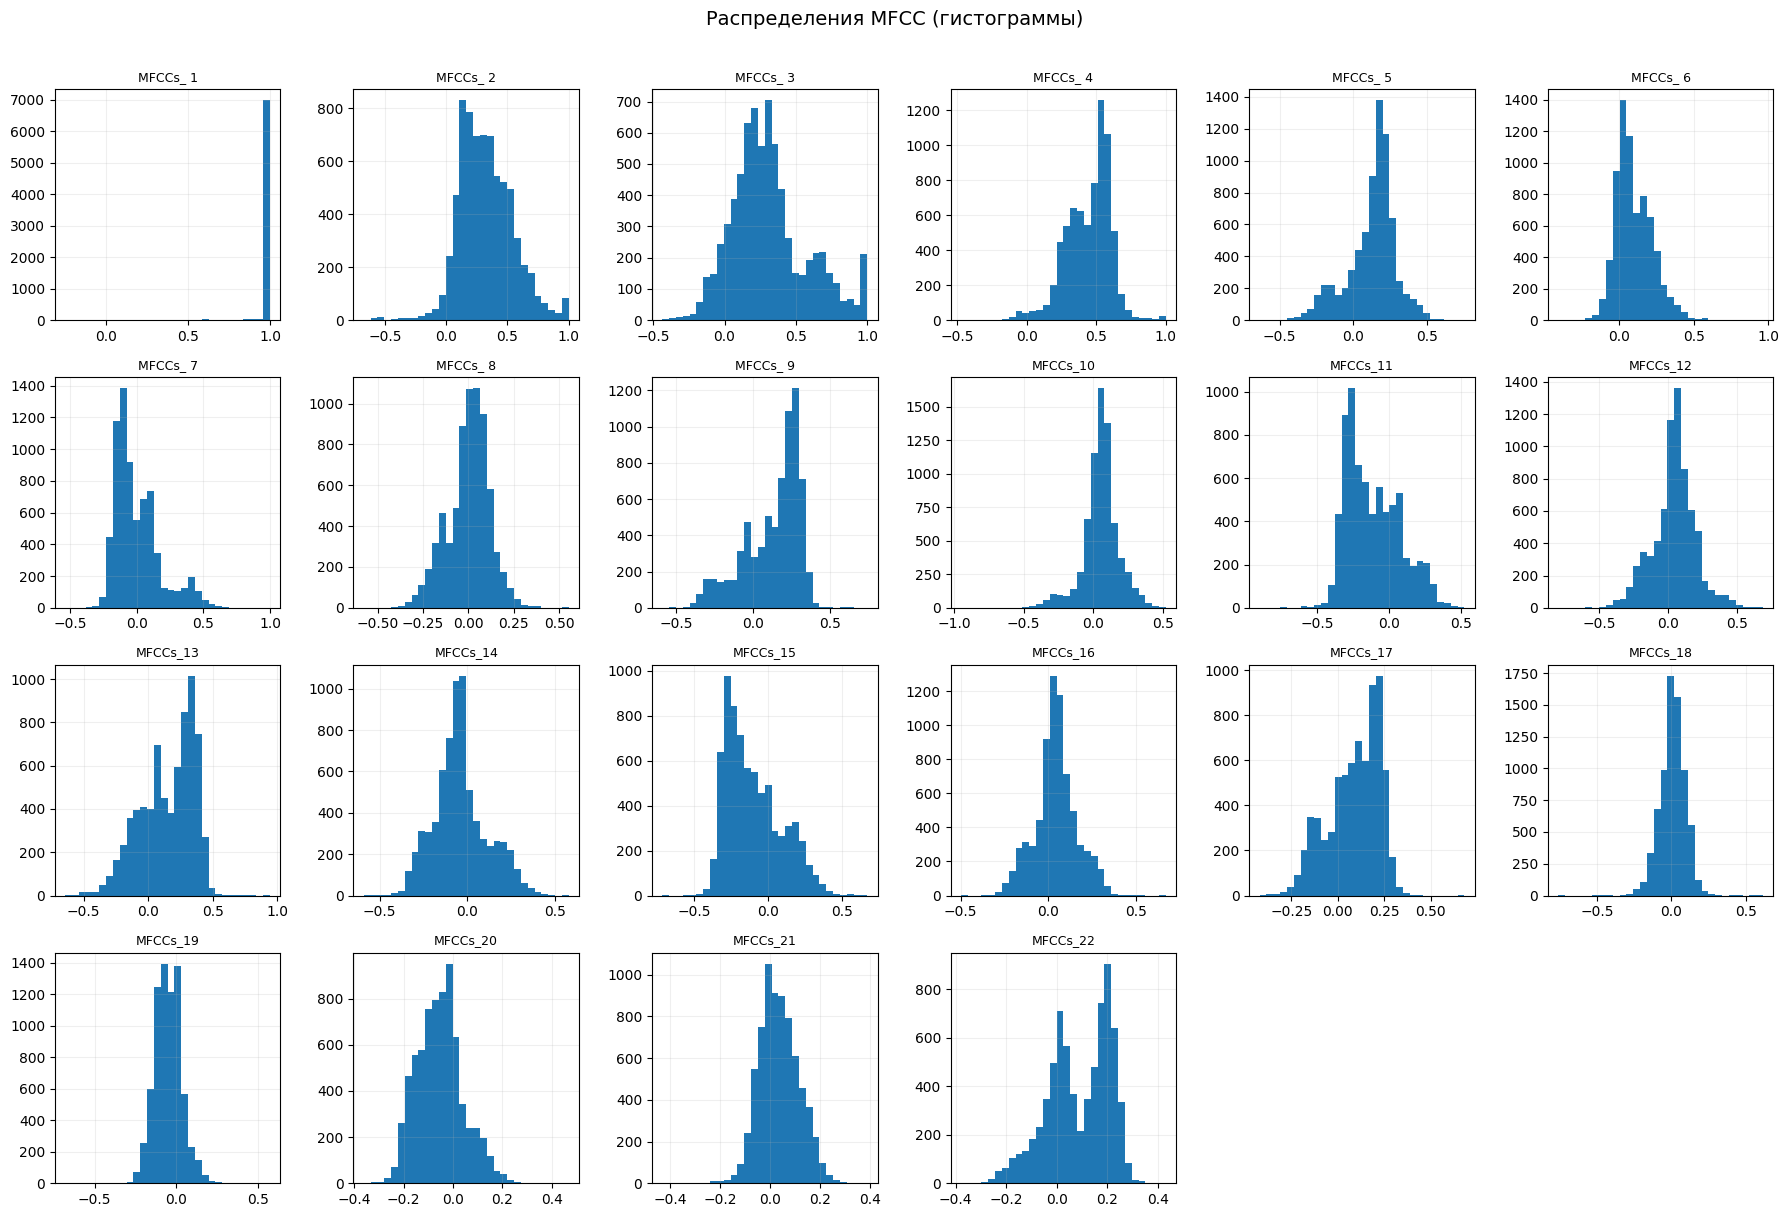

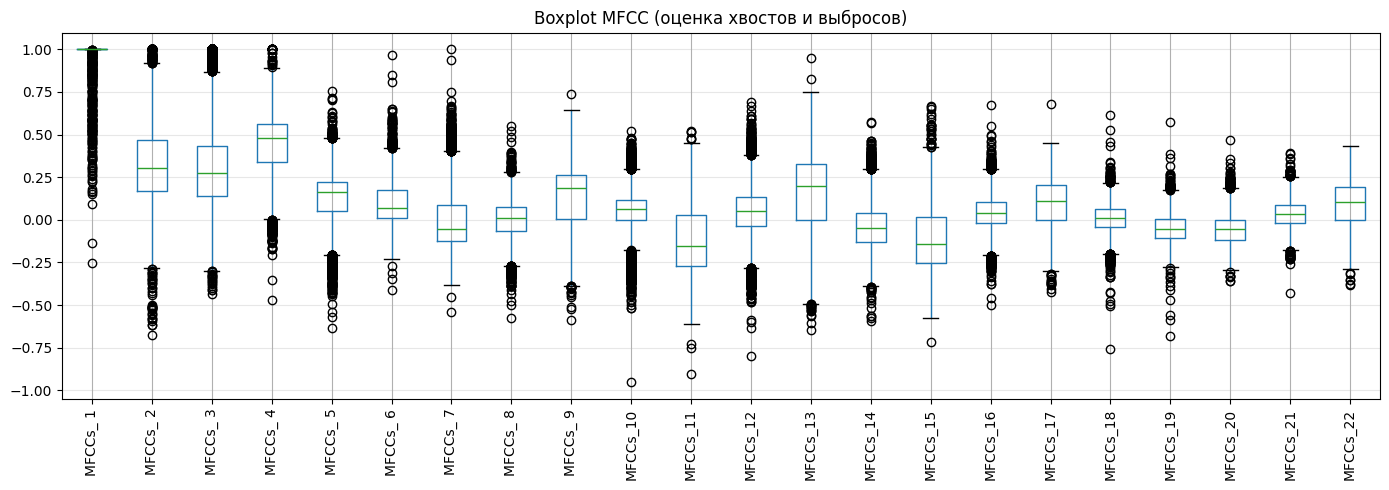

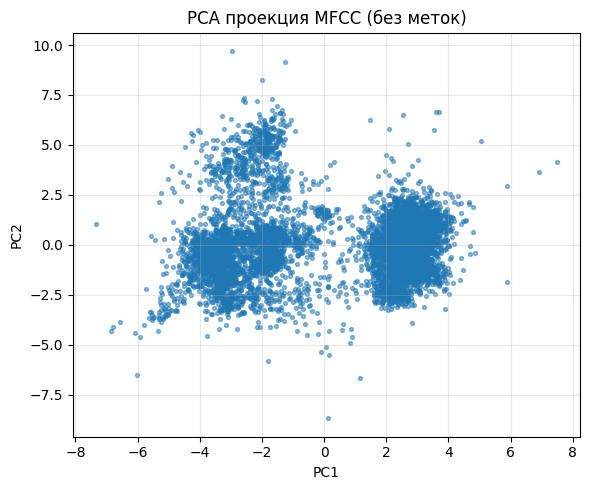

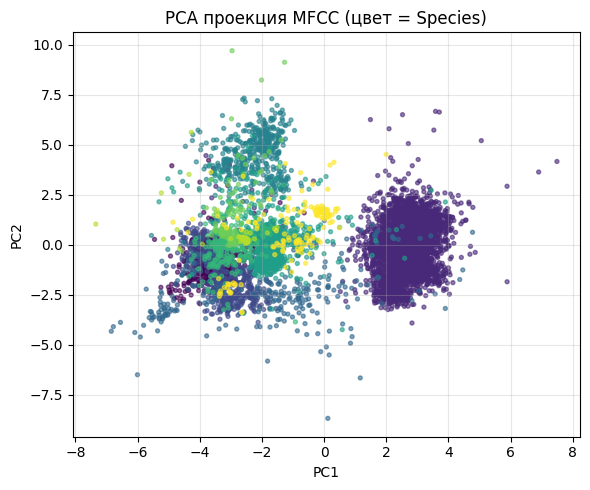

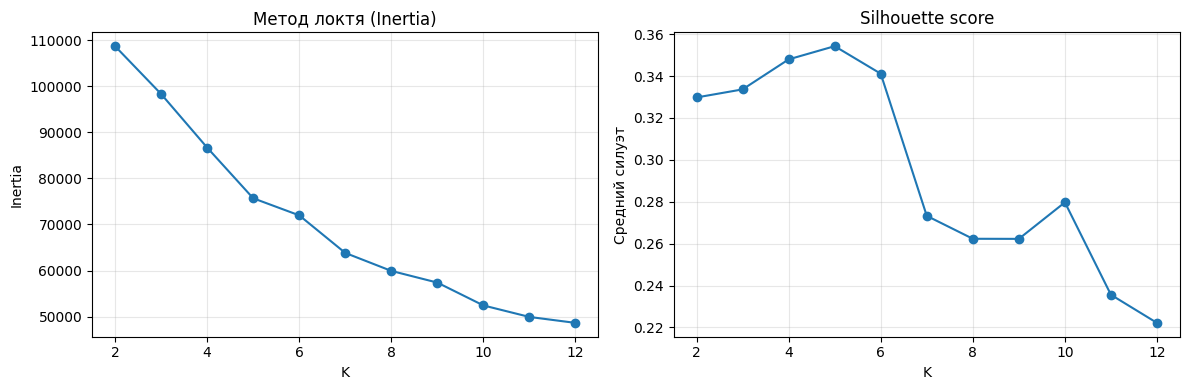


Таблица inertia и silhouette:
K=2: inertia=108667.95, silhouette=0.330
K=3: inertia=98299.48, silhouette=0.334
K=4: inertia=86674.22, silhouette=0.348
K=5: inertia=75684.10, silhouette=0.354
K=6: inertia=71977.75, silhouette=0.341
K=7: inertia=63826.16, silhouette=0.273
K=8: inertia=59928.47, silhouette=0.262
K=9: inertia=57392.00, silhouette=0.262
K=10: inertia=52438.36, silhouette=0.280
K=11: inertia=49942.59, silhouette=0.236
K=12: inertia=48654.18, silhouette=0.222

Авто-подсказка:
Лучший K по silhouette: 5 (silhouette=0.354)
Доля объясненной дисперсии PCA(2): 0.498


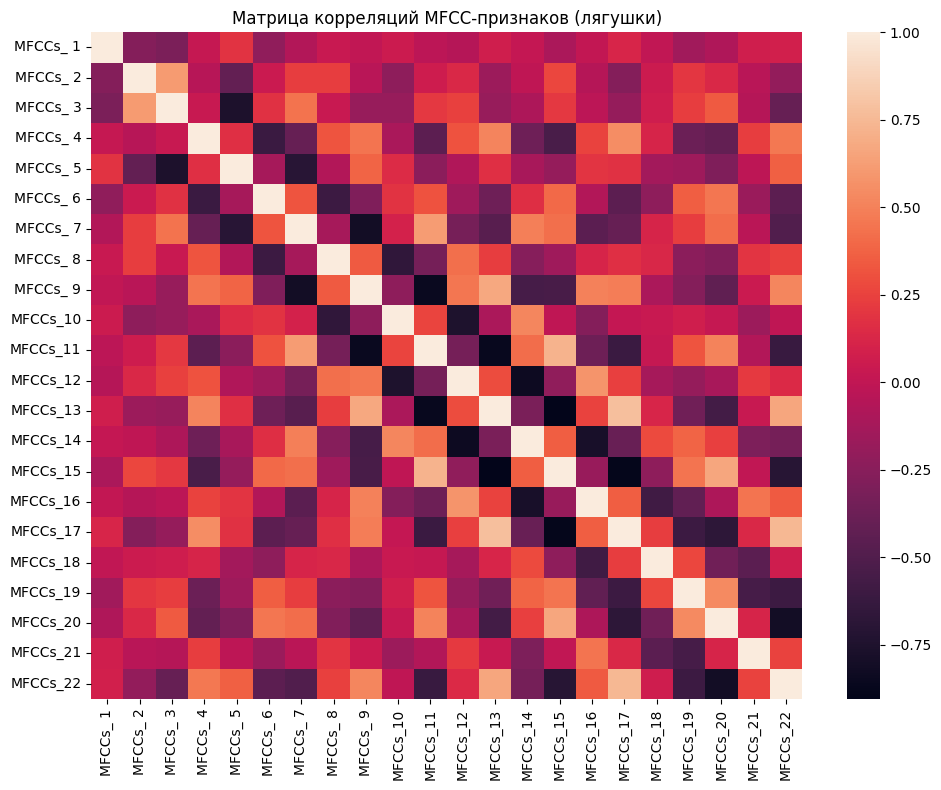

k для 90% дисперсии: 9 (cum_var=0.910)

Матрица компонент PCA (loadings):


,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_13,MFCCs_14,MFCCs_15,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22
PCA1,0.048,-0.080,-0.118,0.237,0.144,-0.201,-0.259,0.148,0.287,-0.093,...,0.295,-0.226,-0.292,0.194,0.297,-0.004,-0.224,-0.257,0.089,0.297
PCA2,-0.136,0.285,0.341,0.032,-0.247,0.028,0.053,0.224,0.065,-0.393,...,-0.081,-0.323,0.148,0.267,-0.114,-0.196,-0.012,0.186,0.192,-0.138
PCA3,-0.108,0.263,0.288,0.141,-0.330,-0.208,0.198,0.240,-0.044,-0.101,...,0.150,0.145,-0.167,-0.336,0.122,0.486,0.124,-0.189,-0.253,0.017
PCA4,0.214,-0.065,-0.008,0.132,-0.197,-0.281,0.328,0.149,-0.332,0.053,...,-0.109,0.093,0.017,-0.006,0.122,-0.083,-0.451,-0.055,0.487,0.136
PCA5,0.299,-0.057,-0.320,-0.012,0.290,-0.349,-0.163,0.457,0.024,-0.345,...,-0.206,0.059,0.239,-0.159,-0.245,0.131,0.132,-0.018,-0.057,-0.086
PCA6,0.528,-0.428,-0.004,-0.202,-0.173,0.175,0.183,-0.142,-0.164,-0.208,...,0.098,-0.222,-0.189,0.029,0.179,0.176,0.055,0.043,-0.173,-0.138
PCA7,0.434,0.032,0.221,0.442,-0.057,-0.278,-0.111,-0.096,0.155,0.255,...,0.153,0.088,-0.055,0.010,-0.028,-0.126,0.242,0.409,0.075,-0.271
PCA8,-0.229,-0.148,0.133,0.427,0.187,-0.177,-0.174,-0.232,-0.168,0.139,...,-0.304,-0.287,0.060,0.097,0.099,0.273,0.026,-0.095,-0.113,-0.055
PCA9,0.524,0.563,0.147,-0.162,0.038,0.048,-0.098,-0.113,0.060,0.196,...,-0.174,-0.124,0.125,0.166,-0.004,0.009,-0.126,-0.331,-0.212,0.146



Доля объяснённой дисперсии PCA:


,Explained variance ratio,Cumulative
PCA1,0.3480,0.3480
PCA2,0.1500,0.4980
PCA3,0.1135,0.6116
PCA4,0.0784,0.6900
PCA5,0.0690,0.7590
PCA6,0.0456,0.8045
PCA7,0.0387,0.8432
PCA8,0.0367,0.8799
PCA9,0.0306,0.9105



Топ-5 признаков, формирующих каждую компоненту:


,Top1,Top2,Top3,Top4,Top5
PCA1,MFCCs_22,MFCCs_17,MFCCs_11,MFCCs_13,MFCCs_15
PCA2,MFCCs_12,MFCCs_10,MFCCs_ 3,MFCCs_14,MFCCs_ 2
PCA3,MFCCs_18,MFCCs_16,MFCCs_ 5,MFCCs_ 3,MFCCs_ 2
PCA4,MFCCs_21,MFCCs_19,MFCCs_ 9,MFCCs_ 7,MFCCs_ 6
PCA5,MFCCs_ 8,MFCCs_ 6,MFCCs_10,MFCCs_ 3,MFCCs_ 1
PCA6,MFCCs_ 1,MFCCs_ 2,MFCCs_12,MFCCs_14,MFCCs_10
PCA7,MFCCs_ 4,MFCCs_ 1,MFCCs_20,MFCCs_ 6,MFCCs_22
PCA8,MFCCs_11,MFCCs_ 4,MFCCs_13,MFCCs_14,MFCCs_18
PCA9,MFCCs_ 2,MFCCs_ 1,MFCCs_20,MFCCs_21,MFCCs_10


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------
# 1) Загрузка и базовая инфа
# ---------------------------
df = pd.read_csv("Frogs_MFCCs.csv")

print("Размерность (rows, cols):", df.shape)
print("\nТипы признаков и пропуски:")
df.info()

print("\nПропуски по столбцам:")
print(df.isna().sum())

# признаки MFCC (числовые)
mfcc_cols = [c for c in df.columns if c.lower().startswith("mfcc")]
# если вдруг названия чуть другие, можно так:
# mfcc_cols = [c for c in df.columns if "MFCC" in c.upper()]

print("\nMFCC признаки:", len(mfcc_cols))

# ---------------------------
# 2) Дескриптивная статистика
# ---------------------------
desc = df[mfcc_cols].describe().T
desc["skew"] = df[mfcc_cols].skew()
desc["kurtosis"] = df[mfcc_cols].kurtosis()
print("\nКраткая статистика MFCC:")
print(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]].head(10))

# ---------------------------
# 3) Хвосты/распределения:
#    гистограммы + boxplot
# ---------------------------
# (3.1) Гистограммы всех MFCC на одной картинке
ncols = 6
nrows = int(np.ceil(len(mfcc_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(mfcc_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

# если осей больше чем признаков
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения MFCC (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# (3.2) Boxplot всех MFCC (видно выбросы/хвосты)
plt.figure(figsize=(14, 5))
df[mfcc_cols].boxplot()
plt.title("Boxplot MFCC (оценка хвостов и выбросов)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 4) Масштабирование
# ---------------------------
# MFCC обычно уже нормированы, но StandardScaler часто улучшает равенство дисперсий
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[mfcc_cols])

# Если хочешь проверить устойчивость к выбросам:
# scaler = RobustScaler()
# X_scaled = scaler.fit_transform(df[mfcc_cols])

# ---------------------------
# 5) Быстрая визуальная оценка структуры:
#    PCA 2D + (опционально цвет по виду)
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, alpha=0.5)
plt.title("PCA проекция MFCC (без меток)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Если хочешь подсветить реальный Species (только для анализа, не для обучения):
if "Species" in df.columns:
    species_codes = df["Species"].astype("category").cat.codes
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=species_codes, s=8, alpha=0.6)
    plt.title("PCA проекция MFCC (цвет = Species)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------
# 6) Подбор K: локоть + silhouette
# ---------------------------
Ks = range(2, 13)   # разумный диапазон (ожидаем >2 кластеров)
inertias = []
silhouettes = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

# ---------------------------
# 7) Мини-вывод на пригодность (авто-подсказка)
# ---------------------------
best_k = list(Ks)[int(np.argmax(silhouettes))]
best_sil = np.max(silhouettes)

print("\nАвто-подсказка:")
print(f"Лучший K по silhouette: {best_k} (silhouette={best_sil:.3f})")
print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Frogs_MFCCs.csv")

mfcc_cols = [c for c in df.columns if c.lower().startswith("mfcc")]
corr = df[mfcc_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False)
plt.title("Матрица корреляций MFCC-признаков (лягушки)")
plt.tight_layout()
plt.show()


import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) MFCC-признаки
mfcc_cols = [c for c in df.columns if c.lower().startswith("mfcc")]
X = df[mfcc_cols].values

# 2) Масштабирование
X_scaled = StandardScaler().fit_transform(X)

# 3) PCA на все компоненты, чтобы выбрать k по порогу дисперсии
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

thr = 0.90  # порог дисперсии, можно 0.95
k = np.argmax(cum_var >= thr) + 1
print(f"k для {thr*100:.0f}% дисперсии: {k} (cum_var={cum_var[k-1]:.3f})")

# 4) Финальный PCA на k компонент
pca = PCA(n_components=k, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 5) Таблица "как скомпоновал" = матрица компонент (loadings)
# строки = PCA-компоненты, столбцы = MFCC
loadings = pd.DataFrame(
    pca.components_,
    columns=mfcc_cols,
    index=[f"PCA{i+1}" for i in range(k)]
)

print("\nМатрица компонент PCA (loadings):")
display(loadings.round(3))

# 6) (Очень полезно) Табличка с объяснённой дисперсией по компонентам
explained = pd.DataFrame({
    "Explained variance ratio": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_)
}, index=[f"PCA{i+1}" for i in range(k)])

print("\nДоля объяснённой дисперсии PCA:")
display(explained.round(4))

# 7) Топ-5 MFCC по вкладу (по модулю) в каждую компоненту
top_features = {}
for comp in loadings.index:
    top = loadings.loc[comp].abs().sort_values(ascending=False).head(5)
    top_features[comp] = list(top.index)

top_df = pd.DataFrame.from_dict(top_features, orient="index", columns=[f"Top{i}" for i in range(1,6)])
print("\nТоп-5 признаков, формирующих каждую компоненту:")
display(top_df)




Размерность (rows, cols): (603, 15)

Типы признаков и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  603 non-null    int64 
 1   title       603 non-null    object
 2   artist      603 non-null    object
 3   top genre   603 non-null    object
 4   year        603 non-null    int64 
 5   bpm         603 non-null    int64 
 6   nrgy        603 non-null    int64 
 7   dnce        603 non-null    int64 
 8   dB          603 non-null    int64 
 9   live        603 non-null    int64 
 10  val         603 non-null    int64 
 11  dur         603 non-null    int64 
 12  acous       603 non-null    int64 
 13  spch        603 non-null    int64 
 14  pop         603 non-null    int64 
dtypes: int64(12), object(3)
memory usage: 70.8+ KB

Пропуски по столбцам:
Unnamed: 0    0
title         0
artist        0
top genre     0
year        

,Unnamed: 0,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,1,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,2,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,3,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,4,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,5,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78



Числовые признаки для кластеризации:
['Unnamed: 0', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch', 'pop']

Краткая статистика:


,mean,std,min,25%,50%,75%,max,skew,kurtosis
Unnamed: 0,302.000000,174.215384,1.0,151.5,302.0,452.5,603.0,0.000000,-1.200000
bpm,118.545605,24.795358,0.0,100.0,120.0,129.0,206.0,0.537042,1.709204
nrgy,70.504146,16.310664,0.0,61.0,74.0,82.0,98.0,-0.985194,1.048001
dnce,64.379768,13.378718,0.0,57.0,66.0,73.0,97.0,-0.679595,1.064175
dB,-5.578773,2.798020,-60.0,-6.0,-5.0,-4.0,-2.0,-12.449699,237.805103
live,17.774461,13.102543,0.0,9.0,12.0,24.0,74.0,1.716040,3.111358
val,52.225539,22.513020,0.0,35.0,52.0,69.0,98.0,-0.073908,-0.822009
dur,224.674959,34.130059,134.0,202.0,221.0,239.5,424.0,1.339546,4.179131
acous,14.326700,20.766165,0.0,2.0,6.0,17.0,99.0,2.202629,4.475531
spch,8.358209,7.483162,0.0,4.0,5.0,9.0,48.0,2.540666,7.096377


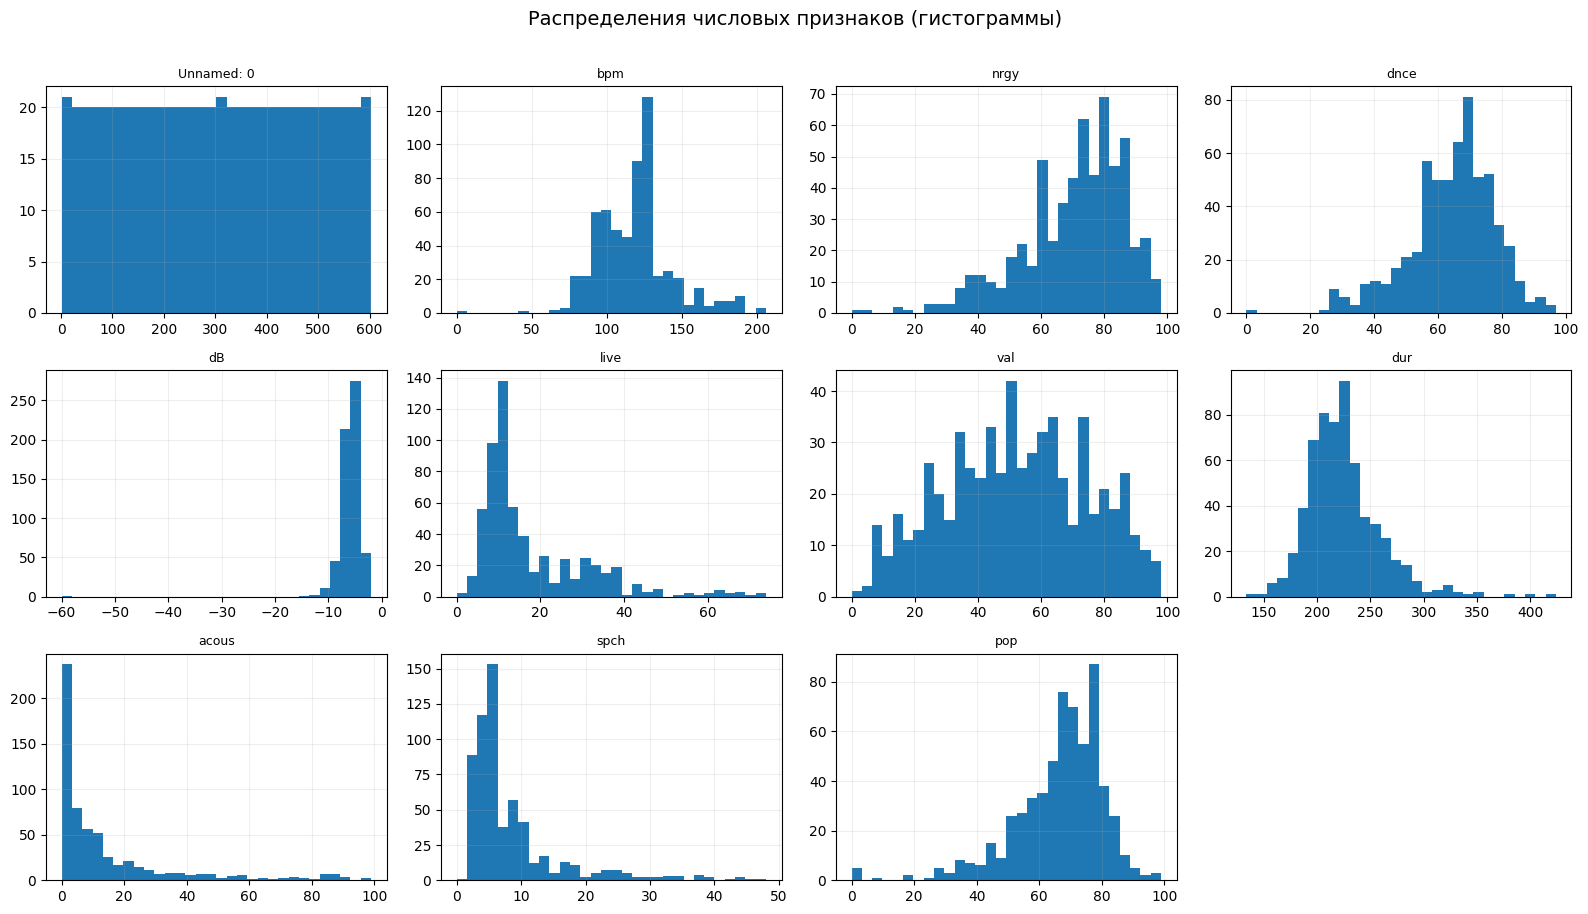

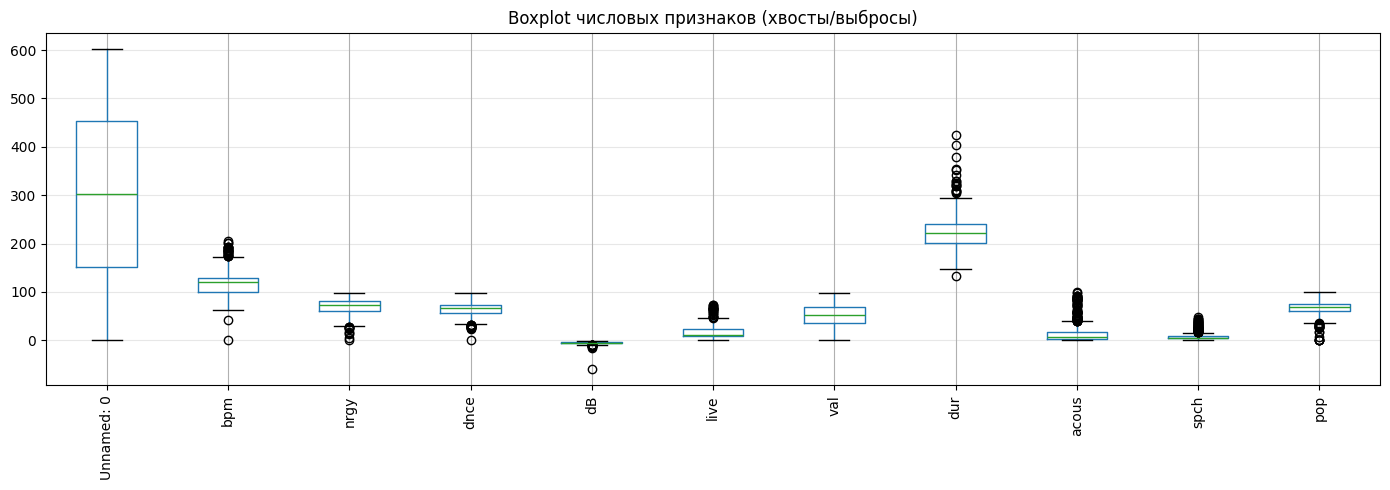

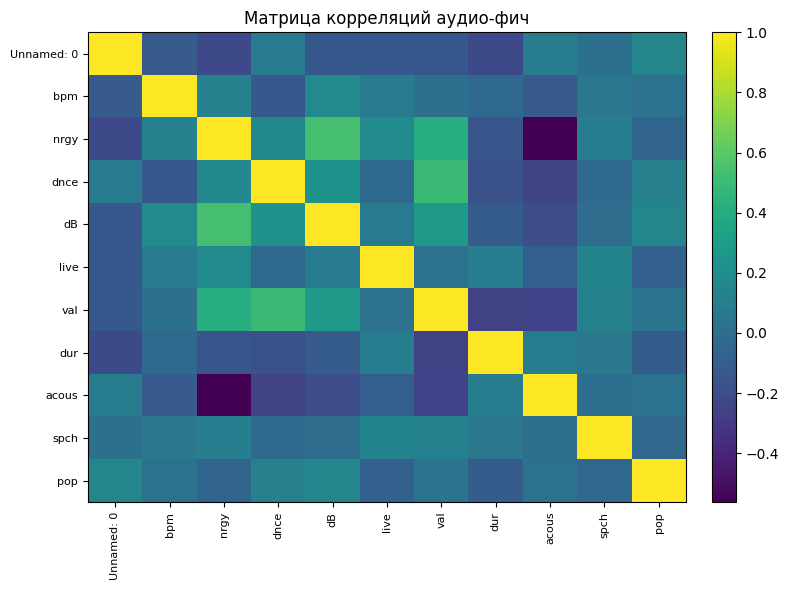

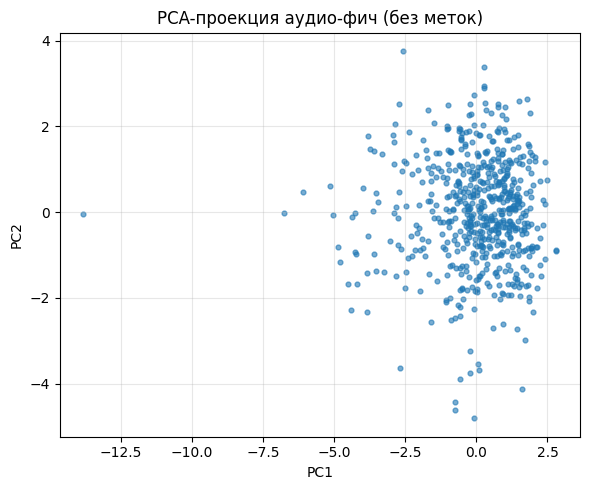

Доля объясненной дисперсии PCA(2): 0.375


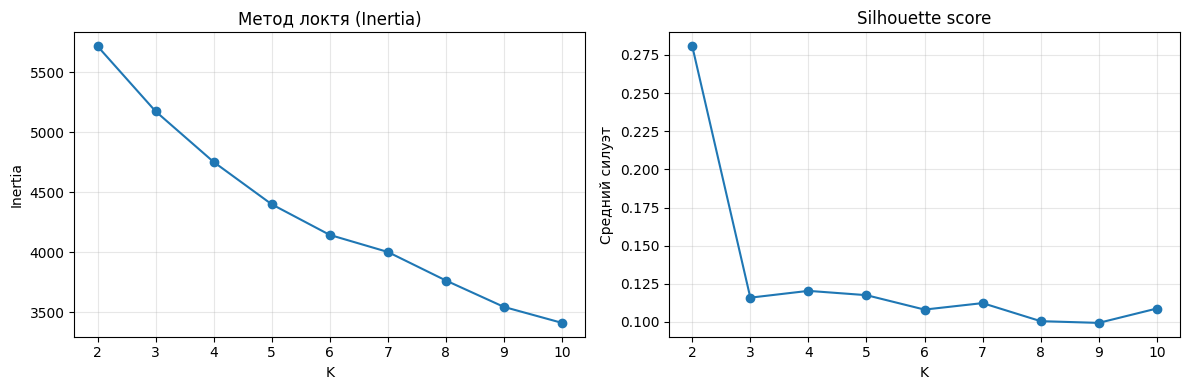


Таблица inertia и silhouette:
K=2: inertia=5715.44, silhouette=0.281
K=3: inertia=5172.90, silhouette=0.116
K=4: inertia=4750.91, silhouette=0.120
K=5: inertia=4398.40, silhouette=0.118
K=6: inertia=4143.23, silhouette=0.108
K=7: inertia=4001.13, silhouette=0.112
K=8: inertia=3763.41, silhouette=0.101
K=9: inertia=3543.34, silhouette=0.099
K=10: inertia=3410.38, silhouette=0.109

Лучший K по silhouette: 2 (silhouette=0.281)


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------
# 1) Загрузка и базовая инфа
# ---------------------------
df = pd.read_csv("top10s.csv", encoding="cp1252")

print("Размерность (rows, cols):", df.shape)
print("\nТипы признаков и пропуски:")
df.info()

print("\nПропуски по столбцам:")
print(df.isna().sum())

print("\nПервые строки:")
display(df.head())

# ---------------------------
# 2) Выбор числовых признаков
#    (оставляем только аудио-фичи)
# ---------------------------
# убираем явные не-фичи (имена/артисты/жанры/год)
drop_cols = [c for c in df.columns if c.lower() in
             ["title", "artist", "top genre", "genre", "year"]]

num_cols = df.drop(columns=drop_cols, errors="ignore").select_dtypes(include=[np.number]).columns.tolist()

print("\nЧисловые признаки для кластеризации:")
print(num_cols)

# ---------------------------
# 3) Дескриптивная статистика
# ---------------------------
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()
print("\nКраткая статистика:")
display(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]])

# ---------------------------
# 4) Распределения/хвосты:
#    гистограммы + boxplot
# ---------------------------
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения числовых признаков (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
df[num_cols].boxplot()
plt.title("Boxplot числовых признаков (хвосты/выбросы)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Матрица корреляций
# ---------------------------
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr.values, aspect="auto")
plt.title("Матрица корреляций аудио-фич")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=8)
plt.yticks(range(len(num_cols)), num_cols, fontsize=8)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Масштабирование
# ---------------------------
# для Spotify-фич обычно хватает StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

# если увидишь сильные выбросы — можно заменить на RobustScaler:
# scaler = RobustScaler()
# X_scaled = scaler.fit_transform(df[num_cols])

# ---------------------------
# 7) Визуальная структура PCA 2D
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=12, alpha=0.6)
plt.title("PCA-проекция аудио-фич (без меток)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")

# ---------------------------
# 8) Подбор K: локоть + silhouette
# ---------------------------
Ks = range(2, 11)  # обычно для песен 2..10 достаточно
inertias = []
silhouettes = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

best_k = list(Ks)[int(np.argmax(silhouettes))]
best_sil = np.max(silhouettes)
print(f"\nЛучший K по silhouette: {best_k} (silhouette={best_sil:.3f})")


Размерность (rows, cols): (991, 22)

Типы признаков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       991 non-null    int64  
 1   brand                       991 non-null    object 
 2   Model                       991 non-null    object 
 3   Price                       991 non-null    int64  
 4   Rating                      991 non-null    int64  
 5   processor_brand             991 non-null    object 
 6   processor_tier              991 non-null    object 
 7   num_cores                   991 non-null    int64  
 8   num_threads                 991 non-null    int64  
 9   ram_memory                  991 non-null    int64  
 10  primary_storage_type        991 non-null    object 
 11  primary_storage_capacity    991 non-null    int64  
 12  secondary_storage_type      991 non-nul

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,secondary_storage_type,secondary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,No secondary storage,0,amd,dedicated,False,15.6,1920,1080,windows,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,No secondary storage,0,intel,integrated,False,14.0,1920,1080,windows,1
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,No secondary storage,0,amd,integrated,False,15.6,1920,1080,windows,1



Числовые признаки: ['Price', 'Rating', 'num_cores', 'num_threads', 'ram_memory', 'primary_storage_capacity', 'secondary_storage_capacity', 'is_touch_screen', 'display_size', 'resolution_width', 'resolution_height']

Категориальные признаки: ['brand', 'Model', 'processor_brand', 'processor_tier', 'primary_storage_type', 'secondary_storage_type', 'gpu_brand', 'gpu_type', 'OS', 'year_of_warranty']

Статистика числовых признаков:


,mean,std,min,25%,50%,75%,max,skew,kurtosis
Price,77266.504541,57384.910269,9800.0,43595.0,61900.0,89245.0,454490.0,2.779863,10.605194
Rating,63.931382,10.190575,24.0,58.0,64.0,71.0,89.0,-0.199286,0.406801
num_cores,8.128153,4.215499,2.0,6.0,8.0,10.0,24.0,1.125503,2.521836
num_threads,12.191726,5.585115,0.0,8.0,12.0,16.0,32.0,0.764674,1.977031
ram_memory,13.047427,5.591188,2.0,8.0,16.0,16.0,36.0,1.222642,2.900453
primary_storage_capacity,610.938446,266.927666,32.0,512.0,512.0,512.0,2048.0,1.735108,5.515427
secondary_storage_capacity,4.004036,33.553936,0.0,0.0,0.0,0.0,512.0,9.135307,92.599302
is_touch_screen,0.088799,0.284597,0.0,0.0,0.0,0.0,1.0,2.895546,6.397095
display_size,15.171241,0.938089,10.1,14.0,15.6,15.6,18.0,-0.942590,1.306193
resolution_width,2003.503532,361.965292,1080.0,1920.0,1920.0,1920.0,3840.0,1.515221,4.125688


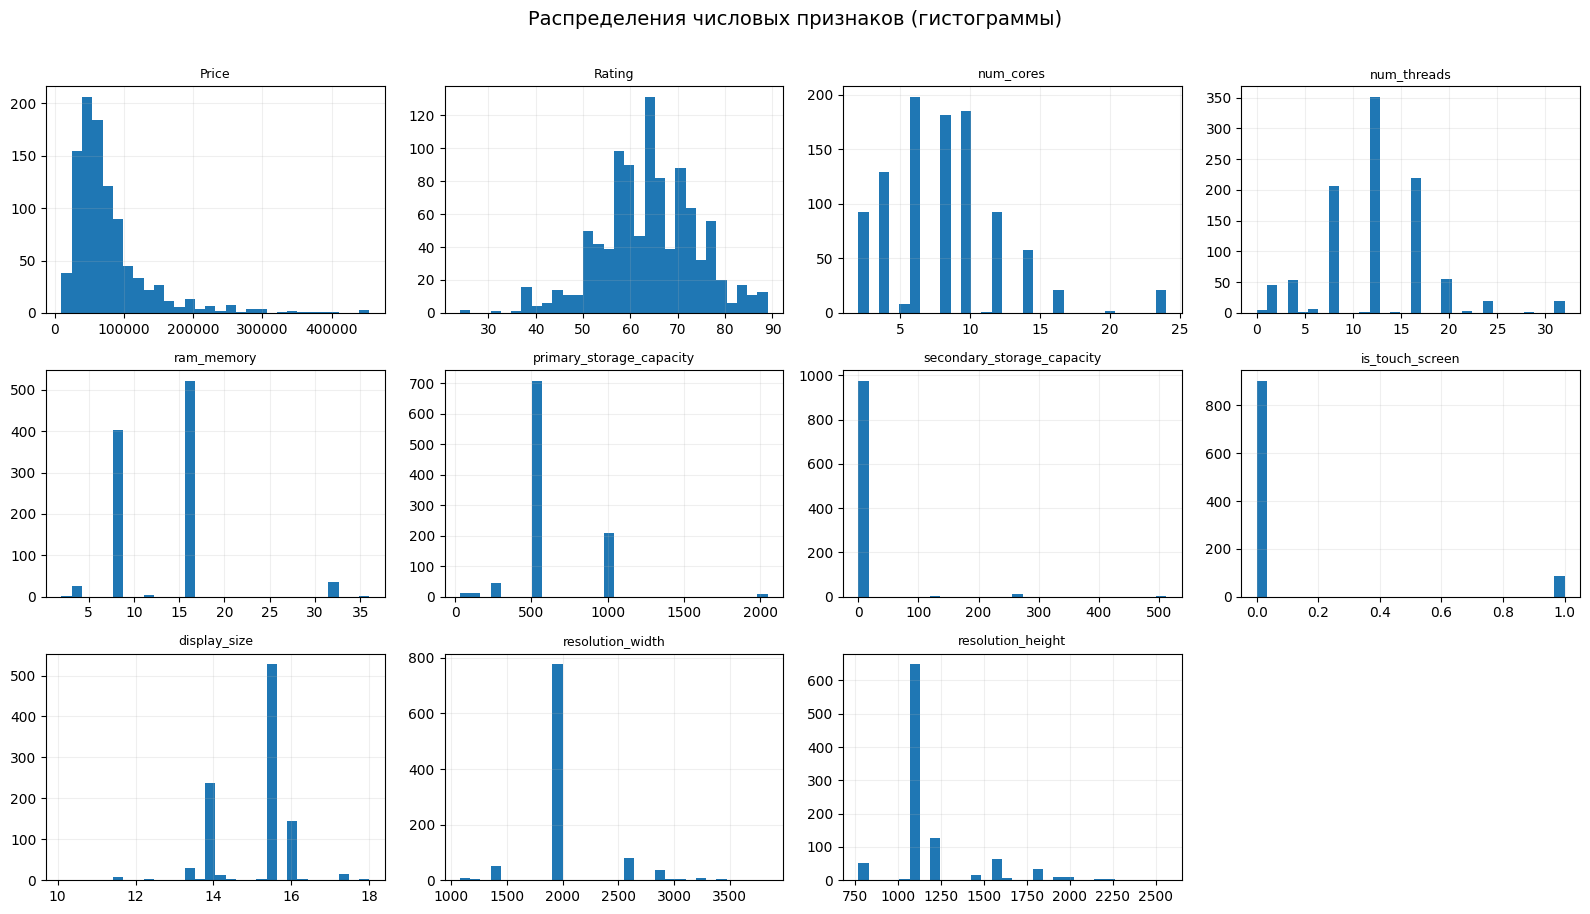

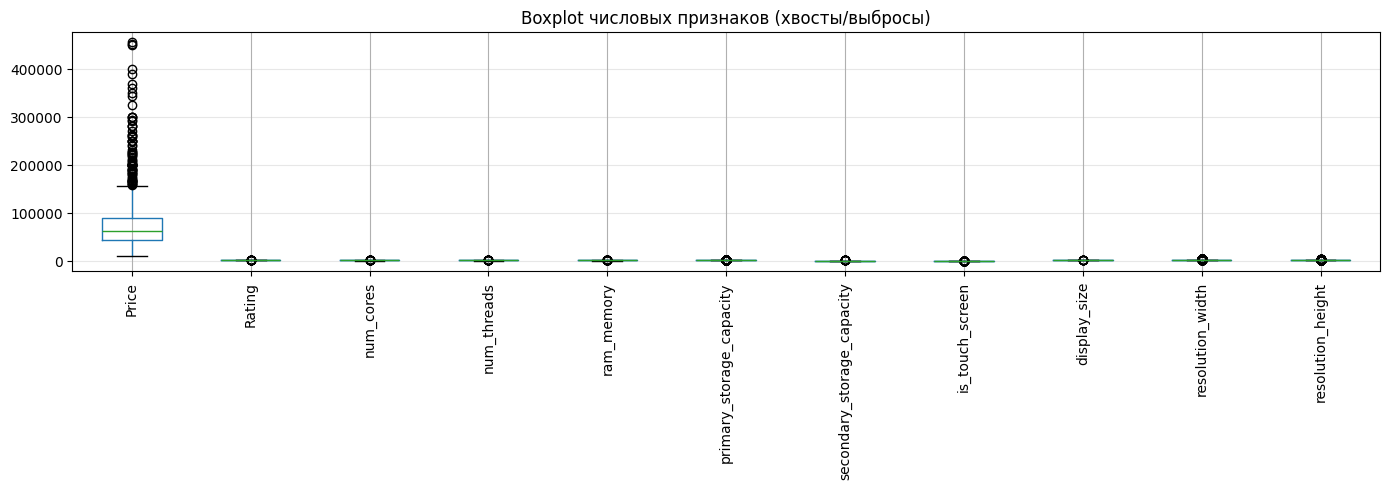

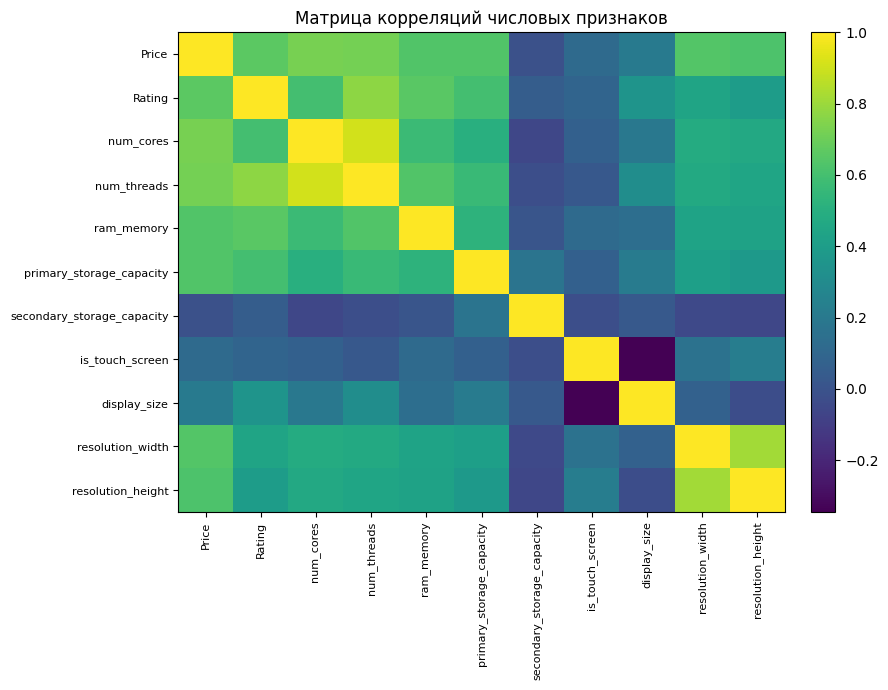

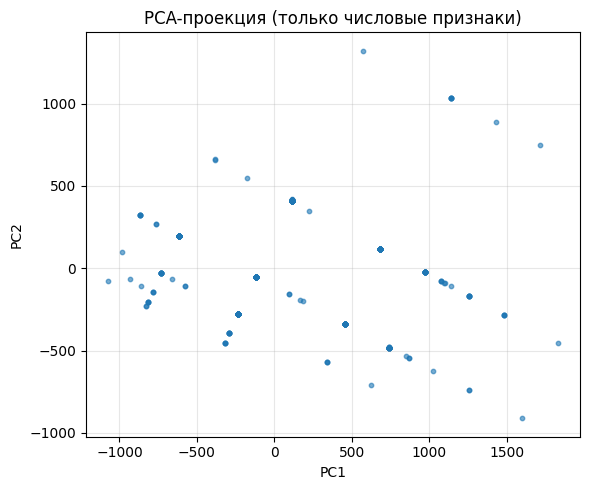

Доля объясненной дисперсии PCA(2): 0.995


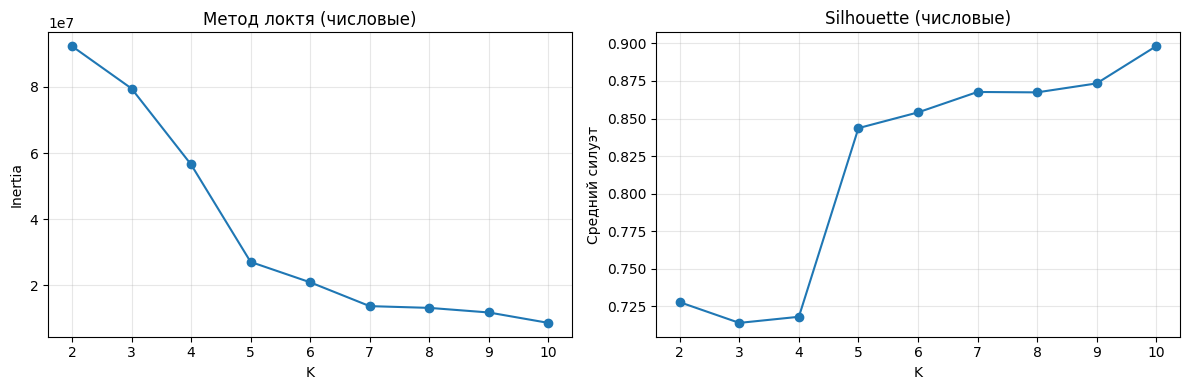


Таблица inertia и silhouette:
K=2: inertia=92327156.11, silhouette=0.728
K=3: inertia=79529272.98, silhouette=0.714
K=4: inertia=56564573.19, silhouette=0.718
K=5: inertia=27118226.56, silhouette=0.844
K=6: inertia=20958778.57, silhouette=0.854
K=7: inertia=13758760.00, silhouette=0.868
K=8: inertia=13230288.17, silhouette=0.867
K=9: inertia=11840663.52, silhouette=0.873
K=10: inertia=8694420.40, silhouette=0.898

Лучший K по silhouette (числовые): 10, sil=0.898

Подсказка:
Категориальные признаки НЕ включались в подбор K.
Их можно:
  A) не включать в кластеризацию, а использовать для интерпретации кластеров (бренды/CPU/GPU/OS).
  B) либо one-hot закодировать и потом сделать PCA перед кластеризацией (если хочешь учитывать всё).


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------
# 1) Загрузка и базовая инфа
# ---------------------------
df = pd.read_csv("laptops.csv")

print("Размерность (rows, cols):", df.shape)
print("\nТипы признаков:")
df.info()

print("\nПропуски по столбцам:")
print(df.isna().sum())

print("\nПервые строки:")
display(df.head())

# ---------------------------
# 2) Приведение некоторых столбцов
# ---------------------------
# index — служебный, не нужен как признак
if "index" in df.columns:
    df = df.drop(columns=["index"])

# is_touch_screen может быть строкой 'True/False' -> приведём к bool (если нужно)
if "is_touch_screen" in df.columns:
    df["is_touch_screen"] = df["is_touch_screen"].astype(str).str.lower().map({"true":1, "false":0}).fillna(df["is_touch_screen"])

# ---------------------------
# 3) Разделим признаки на числовые / категориальные
# ---------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("\nЧисловые признаки:", num_cols)
print("\nКатегориальные признаки:", cat_cols)

# ---------------------------
# 4) Дескриптивная статистика числовых
# ---------------------------
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()

print("\nСтатистика числовых признаков:")
display(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]])

# ---------------------------
# 5) Распределения/хвосты:
#    гистограммы + boxplot
# ---------------------------
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения числовых признаков (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
df[num_cols].boxplot()
plt.title("Boxplot числовых признаков (хвосты/выбросы)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Корреляции по числовым
# ---------------------------
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr.values, aspect="auto")
plt.title("Матрица корреляций числовых признаков")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=8)
plt.yticks(range(len(num_cols)), num_cols, fontsize=8)
plt.tight_layout()
plt.show()

# ---------------------------
# 7) Масштабирование числовых
# ---------------------------
# Цена/память/ядра часто имеют хвосты, RobustScaler может быть чуть стабильнее
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[num_cols])

# ---------------------------
# 8) PCA 2D для визуальной структуры
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.6)
plt.title("PCA-проекция (только числовые признаки)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")

# ---------------------------
# 9) Подбор K (по числовым признакам)
# ---------------------------
Ks = range(2, 11)
inertias, silhouettes = [], []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (числовые)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette (числовые)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

best_k = list(Ks)[int(np.argmax(silhouettes))]
print(f"\nЛучший K по silhouette (числовые): {best_k}, sil={np.max(silhouettes):.3f}")

# ---------------------------
# 10) Мини-вывод про категориальные
# ---------------------------
print("\nПодсказка:")
print("Категориальные признаки НЕ включались в подбор K.")
print("Их можно:")
print("  A) не включать в кластеризацию, а использовать для интерпретации кластеров (бренды/CPU/GPU/OS).")
print("  B) либо one-hot закодировать и потом сделать PCA перед кластеризацией (если хочешь учитывать всё).")


Размерность X: (13611, 16)
Размерность y: (13611, 1)

Типы признаков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  f

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166



Распределение классов (для проверки, НЕ использовать в кластеризации):


Class   
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


Числовые признаки: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']

Статистика признаков:


,mean,std,min,25%,50%,75%,max,skew,kurtosis
Area,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000,2.952931,10.800814
Perimeter,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000,1.626124,3.588123
MajorAxisLength,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154,1.357815,2.531902
MinorAxisLength,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497,2.238211,6.651067
AspectRatio,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306,0.582573,0.113814
Eccentricity,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423,-1.062824,1.387456
ConvexArea,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000,2.941821,10.743640
EquivDiameter,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358,1.948958,5.192057
Extent,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195,-0.895348,0.643319
Solidity,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677,-2.550093,12.799621


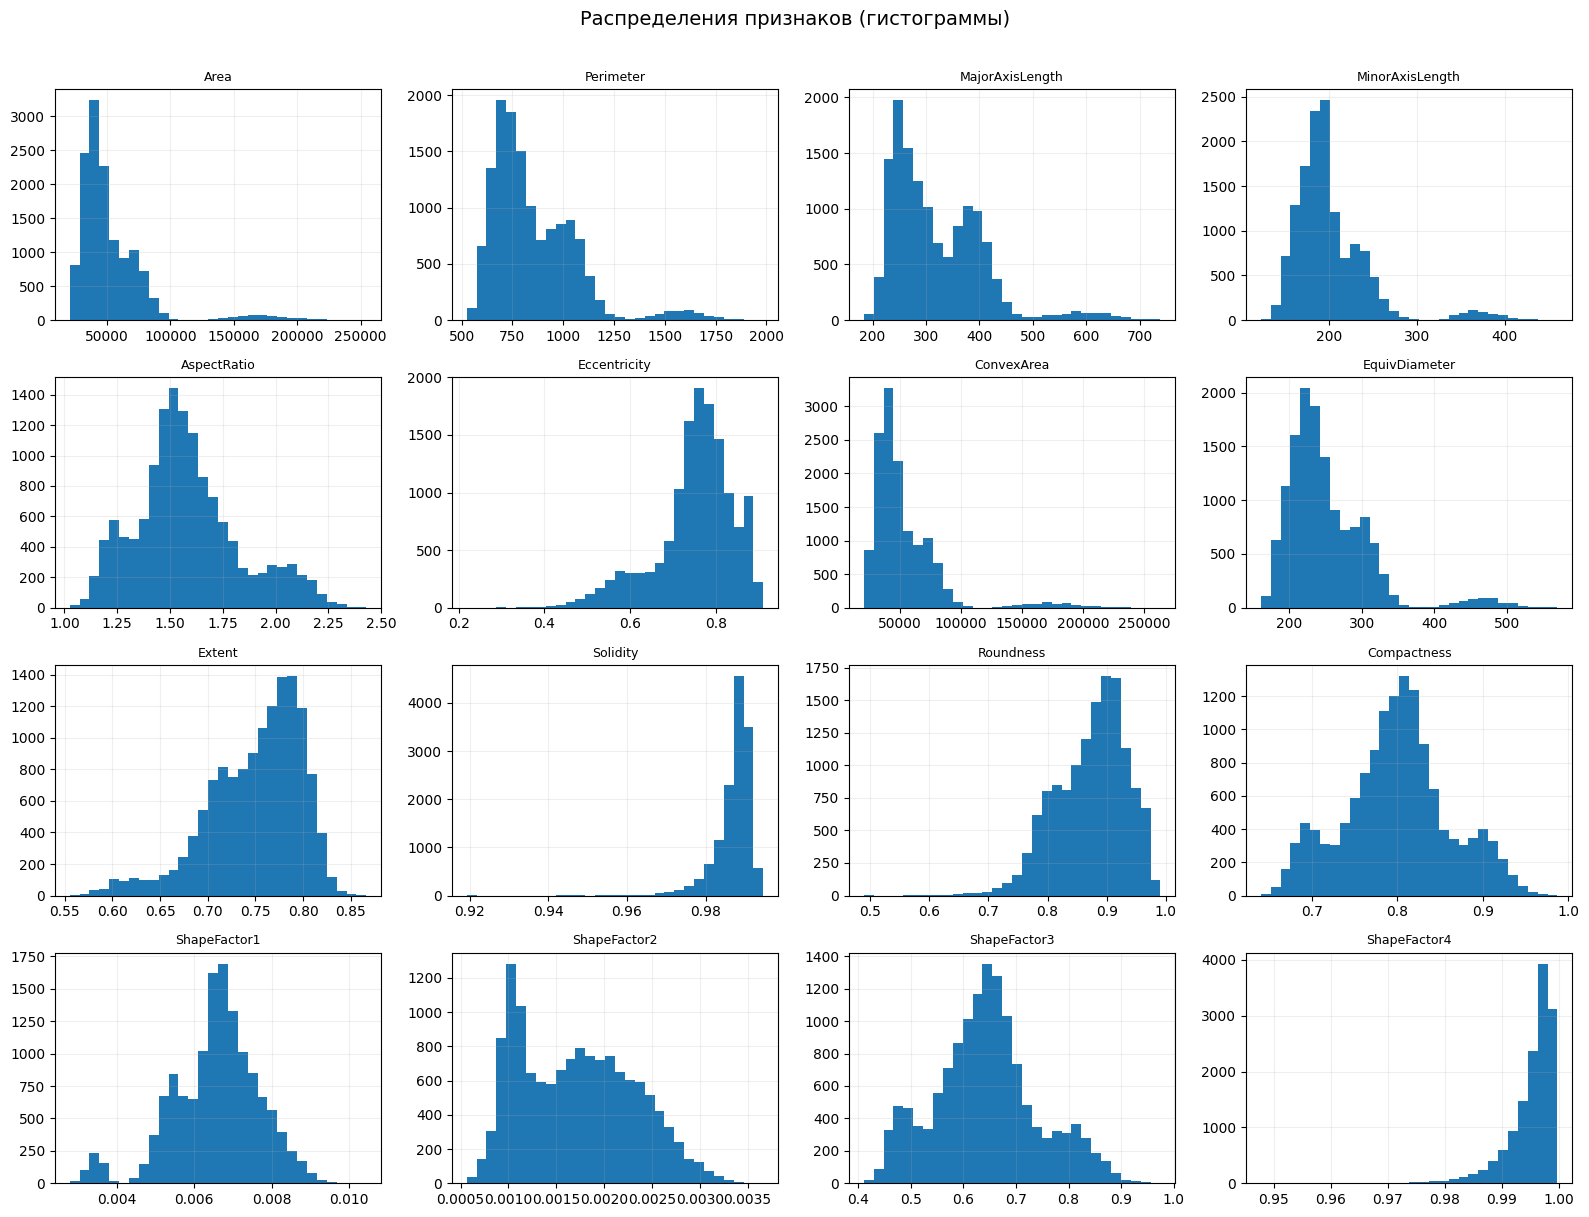

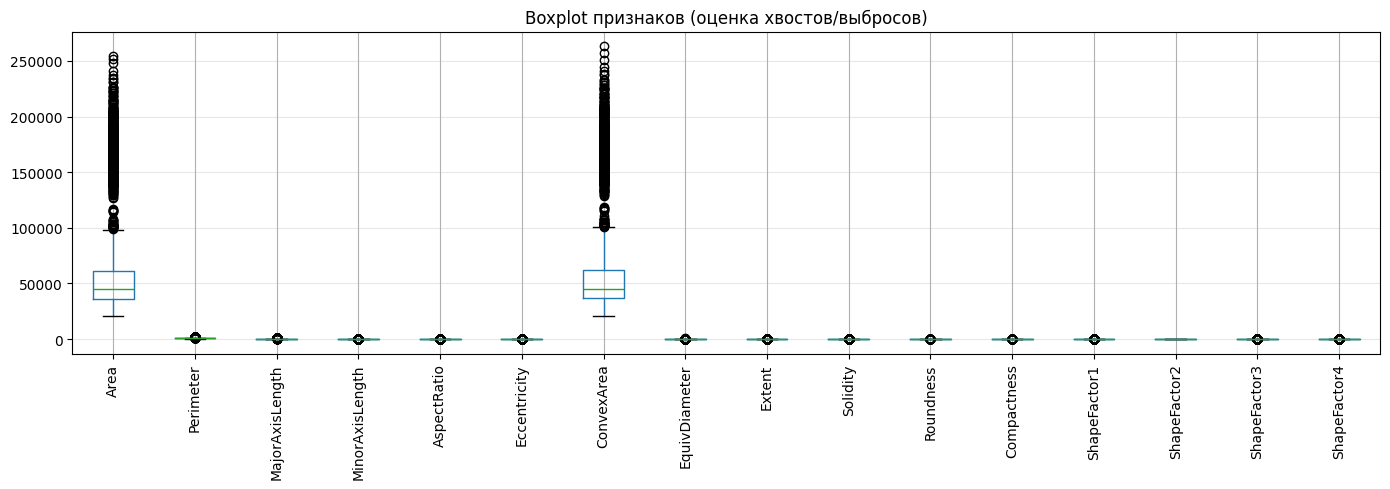

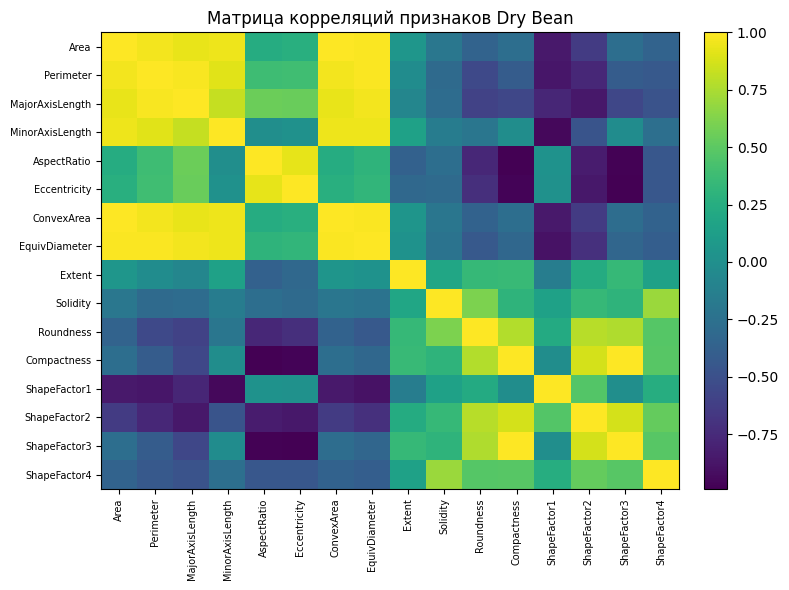

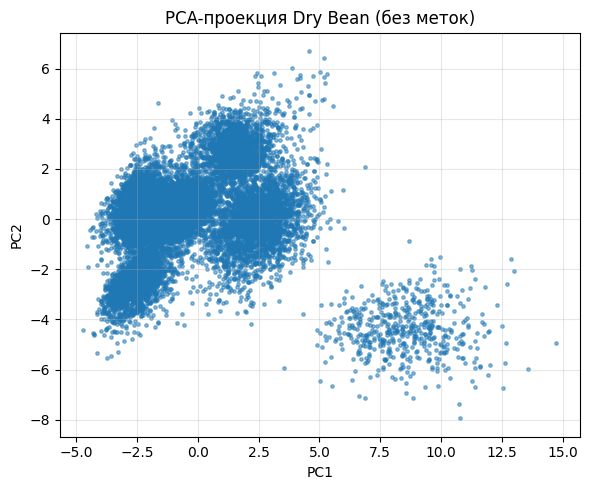

Доля объясненной дисперсии PCA(2): 0.817


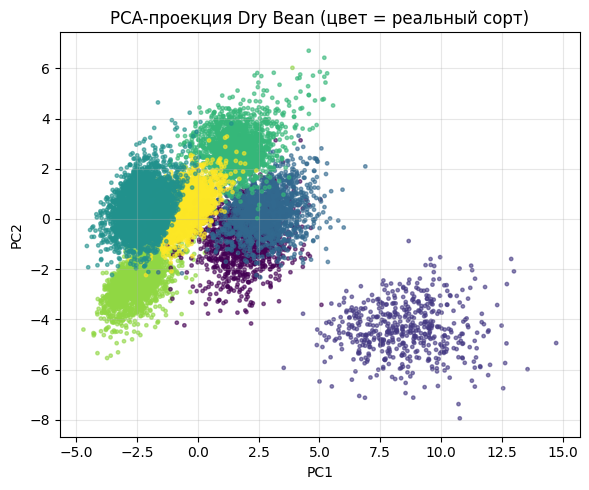

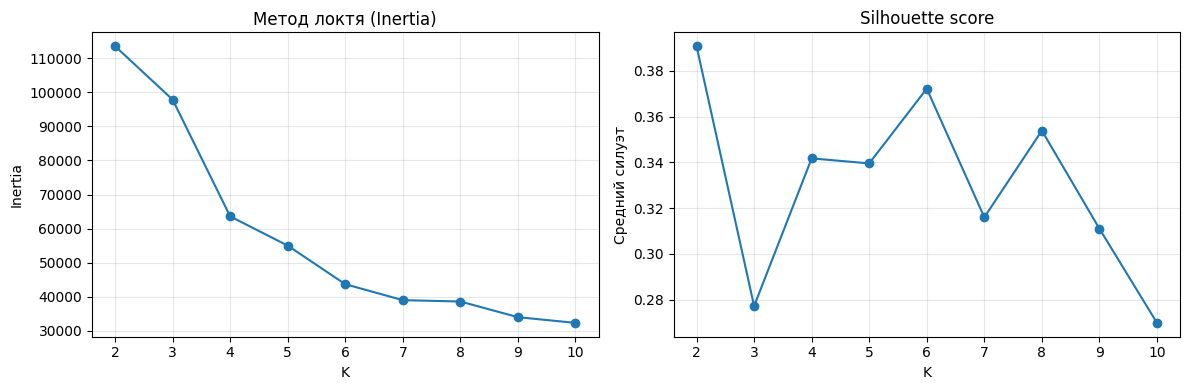


Таблица inertia и silhouette:
K=2: inertia=113495.47, silhouette=0.391
K=3: inertia=97826.98, silhouette=0.277
K=4: inertia=63599.71, silhouette=0.342
K=5: inertia=55021.57, silhouette=0.340
K=6: inertia=43705.82, silhouette=0.372
K=7: inertia=39032.01, silhouette=0.316
K=8: inertia=38636.22, silhouette=0.354
K=9: inertia=34043.82, silhouette=0.311
K=10: inertia=32367.44, silhouette=0.270

Лучший K по silhouette: 2 (sil=0.391)


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ---------------------------
# 1) Базовая инфа
# ---------------------------
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

print("\nТипы признаков:")
X.info()

print("\nПропуски по столбцам:")
print(X.isna().sum())

print("\nПервые строки X:")
display(X.head())

print("\nРаспределение классов (для проверки, НЕ использовать в кластеризации):")
display(y.value_counts())

# ---------------------------
# 2) Числовые признаки
# (в dry bean все фичи числовые)
# ---------------------------
num_cols = X.columns.tolist()
print("\nЧисловые признаки:", num_cols)

# ---------------------------
# 3) Дескриптивная статистика
# ---------------------------
desc = X.describe().T
desc["skew"] = X.skew()
desc["kurtosis"] = X.kurtosis()

print("\nСтатистика признаков:")
display(desc[["mean","std","min","25%","50%","75%","max","skew","kurtosis"]])

# ---------------------------
# 4) Распределения/хвосты
# ---------------------------
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    axes[i].hist(X[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(alpha=0.2)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Распределения признаков (гистограммы)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
X.boxplot()
plt.title("Boxplot признаков (оценка хвостов/выбросов)")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Матрица корреляций
# ---------------------------
corr = X.corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr.values, aspect="auto")
plt.title("Матрица корреляций признаков Dry Bean")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=7)
plt.yticks(range(len(num_cols)), num_cols, fontsize=7)
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Масштабирование
# ---------------------------
# у бобов могут быть хвосты => RobustScaler обычно уместен
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# 7) PCA 2D для визуальной оценки структуры
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=6, alpha=0.5)
plt.title("PCA-проекция Dry Bean (без меток)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля объясненной дисперсии PCA(2): {pca.explained_variance_ratio_.sum():.3f}")

# (опционально) раскраска по реальным типам бобов — только для проверки
y_codes = y.iloc[:,0].astype("category").cat.codes
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_codes, s=6, alpha=0.6)
plt.title("PCA-проекция Dry Bean (цвет = реальный сорт)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# 8) Подбор K (локоть + silhouette)
# ---------------------------
Ks = range(2, 11)
inertias, silhouettes = [], []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(list(Ks), inertias, marker="o")
axes[0].set_title("Метод локтя (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Средний силуэт")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nТаблица inertia и silhouette:")
for k, iner, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}: inertia={iner:.2f}, silhouette={sil:.3f}")

best_k = list(Ks)[int(np.argmax(silhouettes))]
print(f"\nЛучший K по silhouette: {best_k} (sil={np.max(silhouettes):.3f})")


Первые строки датасета:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Размер датасета (строки, столбцы): (768, 9)

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Описательная статистика по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Распределение целевой переменной Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64

Доли классов Outcome:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


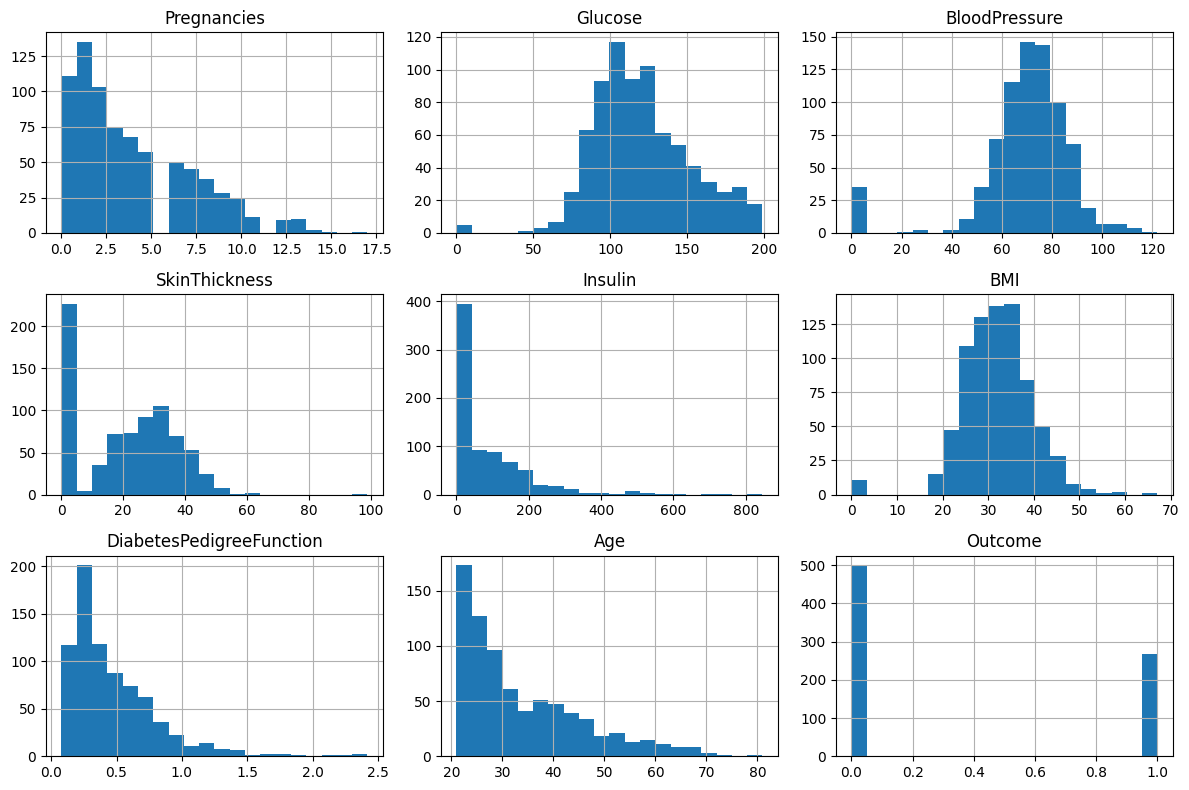


Матрица корреляций (включая Outcome):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


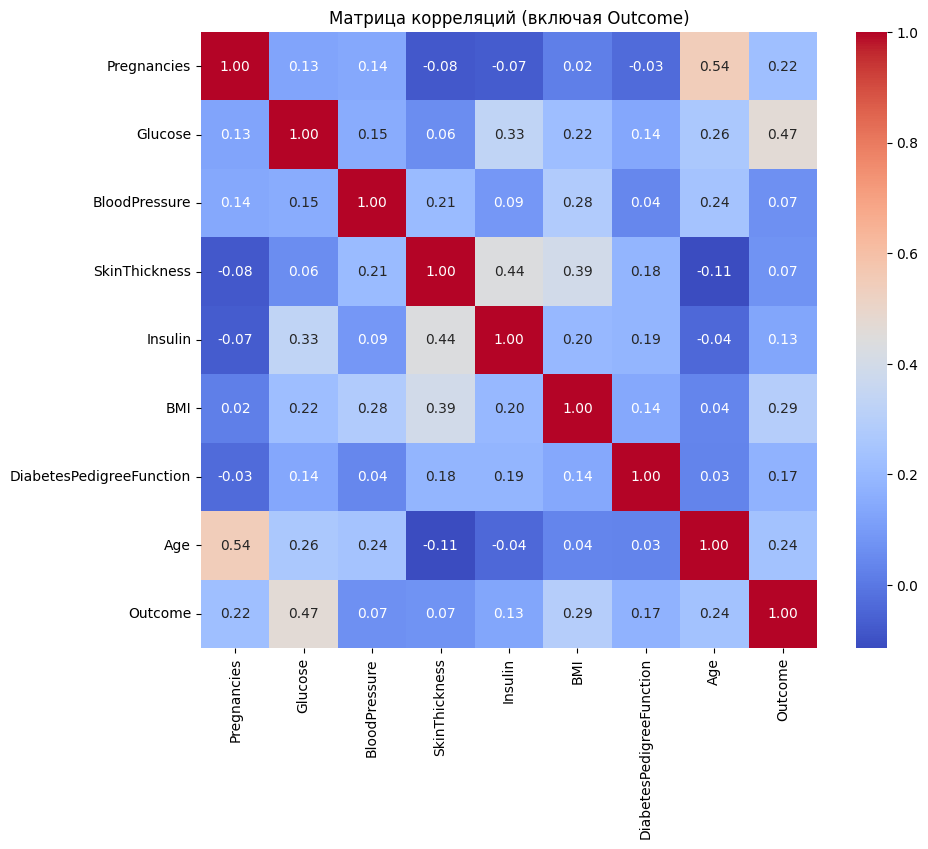


Матрица корреляций только по признакам (без Outcome):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


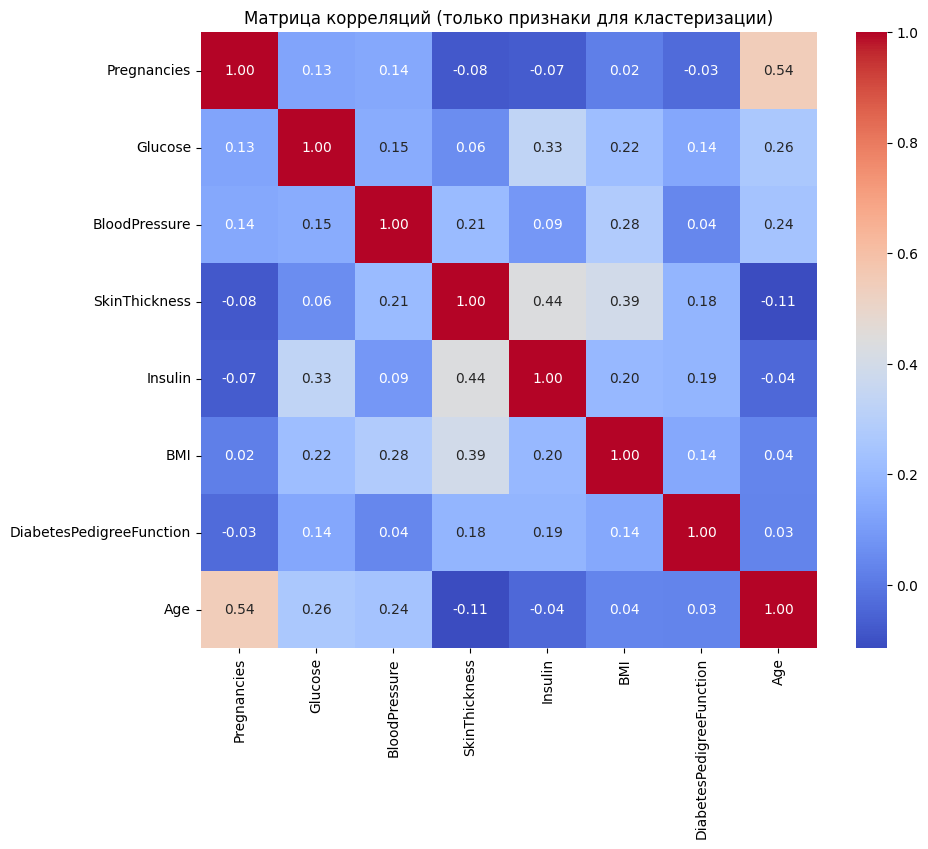

k = 2: silhouette = 0.1646, inertia = 5156.25
k = 3: silhouette = 0.1807, inertia = 4360.47
k = 4: silhouette = 0.1570, inertia = 4013.44
k = 5: silhouette = 0.1883, inertia = 3625.74
k = 6: silhouette = 0.1983, inertia = 3405.14
k = 7: silhouette = 0.1692, inertia = 3139.81
k = 8: silhouette = 0.1614, inertia = 3002.47
k = 9: silhouette = 0.1585, inertia = 2882.34
k = 10: silhouette = 0.1570, inertia = 2836.91

Лучшее k по среднему силуэту: 6 (silhouette = 0.1983)


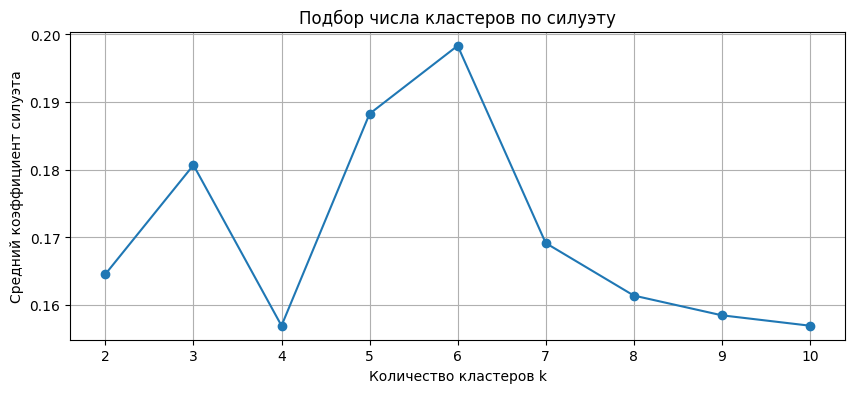

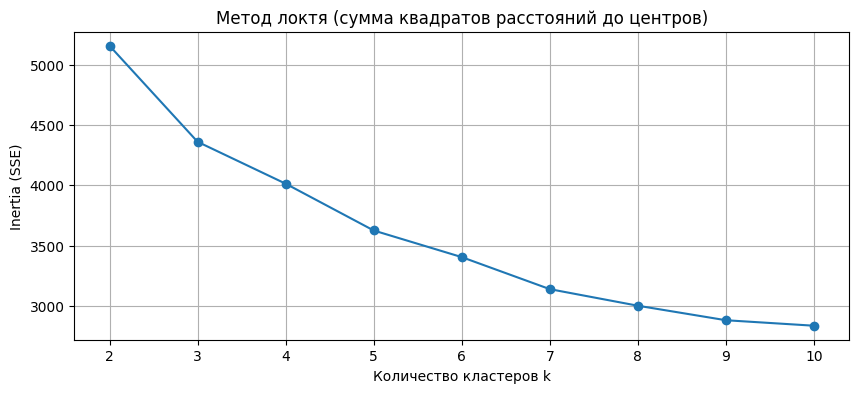

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- чтобы графики показывались в ноутбуке ---
%matplotlib inline

# =========================
# 1. Загрузка и первичный обзор
# =========================

df = pd.read_csv("diabetes.csv")

print("Первые строки датасета:")
display(df.head())

print("\nРазмер датасета (строки, столбцы):", df.shape)

print("\nИнформация о колонках:")
df.info()

print("\nОписательная статистика по числовым признакам:")
display(df.describe().T)

print("\nРаспределение целевой переменной Outcome:")
print(df["Outcome"].value_counts())
print("\nДоли классов Outcome:")
print(df["Outcome"].value_counts(normalize=True))

# Гистограммы признаков (для первичного понимания распределений)
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# =========================
# 2. Матрица корреляций
# =========================

print("\nМатрица корреляций (включая Outcome):")
corr_full = df.corr()
display(corr_full)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Матрица корреляций (включая Outcome)")
plt.show()

# Если нужно отдельно только по признакам (без Outcome):
features = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
            "Insulin","BMI","DiabetesPedigreeFunction","Age"]

corr_features = df[features].corr()
print("\nМатрица корреляций только по признакам (без Outcome):")
display(corr_features)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_features, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Матрица корреляций (только признаки для кластеризации)")
plt.show()

# =========================
# 3. Подготовка данных для кластеризации
# =========================

X = df[features].copy()   # только признаки, без Outcome

# Масштабирование признаков (очень важно для кластеризации)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. Подбор числа кластеров по силуэту
# =========================

sil_scores = {}
inertias = {}

k_values = range(2, 11)  # попробуем от 2 до 10 кластеров

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
    inertias[k] = kmeans.inertia_
    
    print(f"k = {k}: silhouette = {sil:.4f}, inertia = {inertias[k]:.2f}")

# Определим k с максимальным силуэтом
best_k = max(sil_scores, key=sil_scores.get)
print(f"\nЛучшее k по среднему силуэту: {best_k} (silhouette = {sil_scores[best_k]:.4f})")

# =========================
# 5. Графики: силуэт и локоть (inertia)
# =========================

plt.figure(figsize=(10, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Средний коэффициент силуэта")
plt.title("Подбор числа кластеров по силуэту")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Inertia (SSE)")
plt.title("Метод локтя (сумма квадратов расстояний до центров)")
plt.grid(True)
plt.show()


Первые строки датасета:


,Record_ID,Auction_ID,Bidder_ID,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration,Class
0,1,732,_***i,0.200000,0.400000,0.0,0.000028,0.0,0.993593,0.000028,0.666667,5,0
1,2,732,g***r,0.024390,0.200000,0.0,0.013123,0.0,0.993593,0.013123,0.944444,5,0
2,3,732,t***p,0.142857,0.200000,0.0,0.003042,0.0,0.993593,0.003042,1.000000,5,0
3,4,732,7***n,0.100000,0.200000,0.0,0.097477,0.0,0.993593,0.097477,1.000000,5,0
4,5,900,z***z,0.051282,0.222222,0.0,0.001318,0.0,0.000000,0.001242,0.500000,7,0



Размер датасета (строки, столбцы): (6321, 13)

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6321 entries, 0 to 6320
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Record_ID               6321 non-null   int64  
 1   Auction_ID              6321 non-null   int64  
 2   Bidder_ID               6321 non-null   object 
 3   Bidder_Tendency         6321 non-null   float64
 4   Bidding_Ratio           6321 non-null   float64
 5   Successive_Outbidding   6321 non-null   float64
 6   Last_Bidding            6321 non-null   float64
 7   Auction_Bids            6321 non-null   float64
 8   Starting_Price_Average  6321 non-null   float64
 9   Early_Bidding           6321 non-null   float64
 10  Winning_Ratio           6321 non-null   float64
 11  Auction_Duration        6321 non-null   int64  
 12  Class                   6321 non-null   int64  
dtypes: float64(8), int64(4

,count,mean,std,min,25%,50%,75%,max
Record_ID,6321.0,7535.829457,4364.759137,1.000000,3778.000000,7591.000000,11277.000000,15144.000000
Auction_ID,6321.0,1241.388230,735.770789,5.000000,589.000000,1246.000000,1867.000000,2538.000000
Bidder_Tendency,6321.0,0.142541,0.197084,0.000000,0.027027,0.062500,0.166667,1.000000
Bidding_Ratio,6321.0,0.127670,0.131530,0.011765,0.043478,0.083333,0.166667,1.000000
Successive_Outbidding,6321.0,0.103781,0.279698,0.000000,0.000000,0.000000,0.000000,1.000000
Last_Bidding,6321.0,0.463119,0.380097,0.000000,0.047928,0.440937,0.860363,0.999900
Auction_Bids,6321.0,0.231606,0.255252,0.000000,0.000000,0.142857,0.454545,0.788235
Starting_Price_Average,6321.0,0.472821,0.489912,0.000000,0.000000,0.000000,0.993593,0.999935
Early_Bidding,6321.0,0.430683,0.380785,0.000000,0.026620,0.360104,0.826761,0.999900
Winning_Ratio,6321.0,0.367731,0.436573,0.000000,0.000000,0.000000,0.851852,1.000000



Распределение целевой переменной Class:
Class
0    5646
1     675
Name: count, dtype: int64

Доли классов Class:
Class
0    0.893213
1    0.106787
Name: proportion, dtype: float64


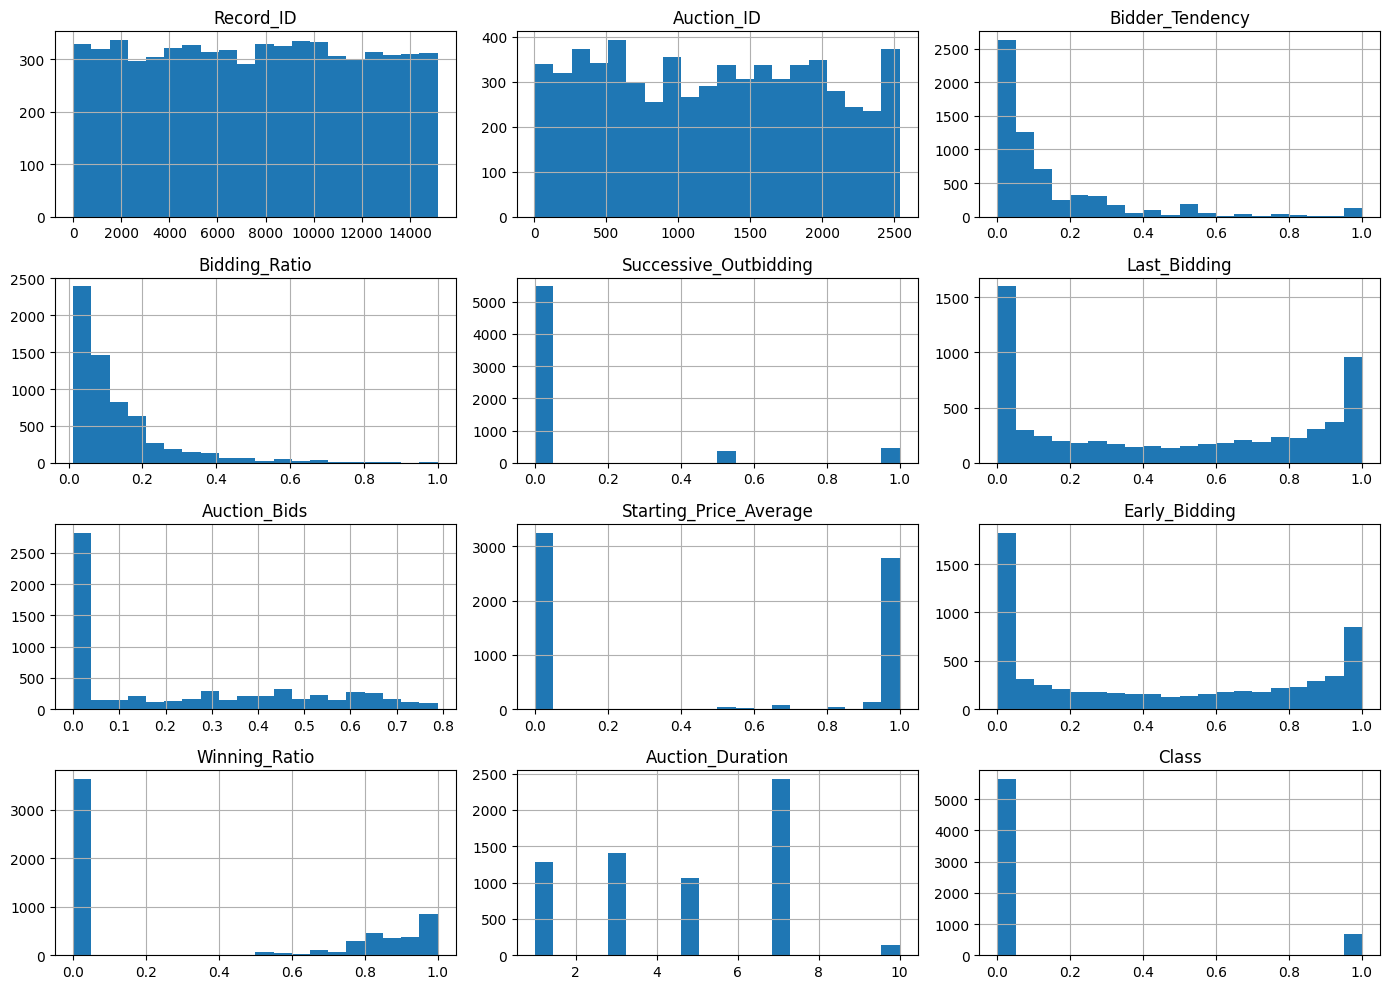


Матрица корреляций по всем числовым колонкам:


,Record_ID,Auction_ID,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration,Class
Record_ID,1.000000,-0.003776,0.011075,-0.040123,0.005271,0.037588,0.048377,0.001265,0.031719,-0.057151,-0.012150,-0.003731
Auction_ID,-0.003776,1.000000,-0.006902,-0.021424,-0.003175,0.070341,0.097558,0.016182,0.068427,-0.039779,0.024918,-0.007985
Bidder_Tendency,0.011075,-0.006902,1.000000,0.293076,0.313510,0.044999,0.086564,0.073242,0.019978,0.212170,0.000244,0.295533
Bidding_Ratio,-0.040123,-0.021424,0.293076,1.000000,0.604828,-0.066541,-0.347831,-0.252289,-0.147773,0.642905,-0.019205,0.569435
Successive_Outbidding,0.005271,-0.003175,0.313510,0.604828,1.000000,0.098941,0.065361,0.052263,0.056798,0.382002,0.010091,0.901035
Last_Bidding,0.037588,0.070341,0.044999,-0.066541,0.098941,1.000000,0.297639,0.293323,0.950096,-0.076726,0.011454,0.097655
Auction_Bids,0.048377,0.097558,0.086564,-0.347831,0.065361,0.297639,1.000000,0.629086,0.298878,-0.381442,0.093331,0.044964
Starting_Price_Average,0.001265,0.016182,0.073242,-0.252289,0.052263,0.293323,0.629086,1.000000,0.302958,-0.262655,0.022990,0.042604
Early_Bidding,0.031719,0.068427,0.019978,-0.147773,0.056798,0.950096,0.298878,0.302958,1.000000,-0.137005,0.011296,0.053570
Winning_Ratio,-0.057151,-0.039779,0.212170,0.642905,0.382002,-0.076726,-0.381442,-0.262655,-0.137005,1.000000,-0.023965,0.394122


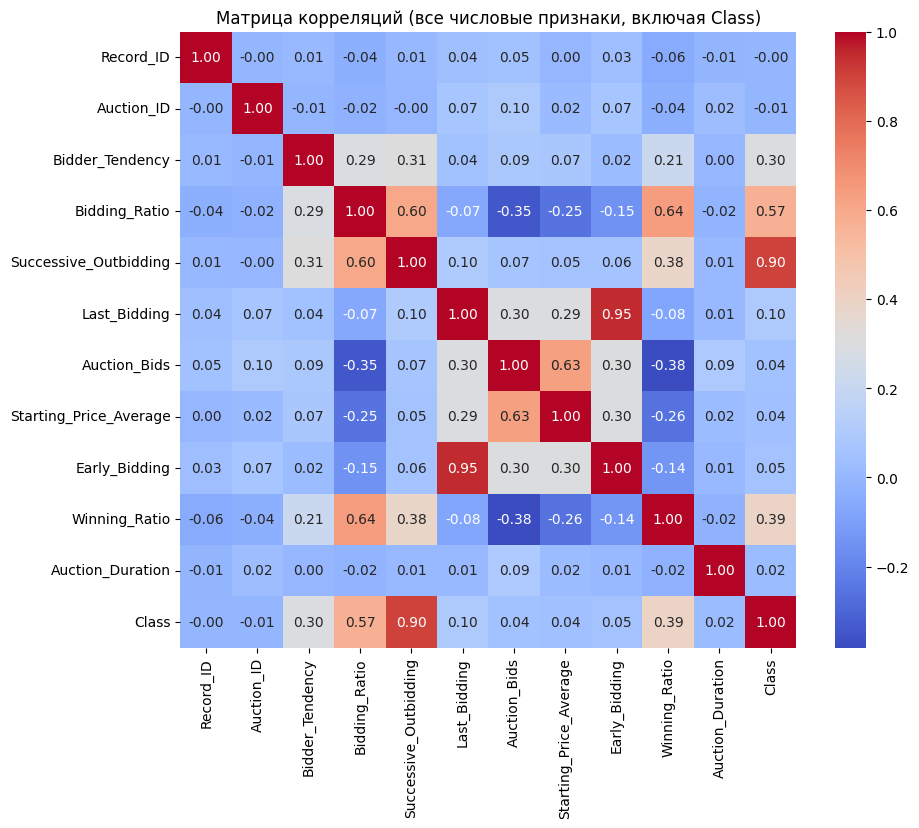


Матрица корреляций только по признакам для кластеризации:


,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration
Bidder_Tendency,1.000000,0.293076,0.313510,0.044999,0.086564,0.073242,0.019978,0.212170,0.000244
Bidding_Ratio,0.293076,1.000000,0.604828,-0.066541,-0.347831,-0.252289,-0.147773,0.642905,-0.019205
Successive_Outbidding,0.313510,0.604828,1.000000,0.098941,0.065361,0.052263,0.056798,0.382002,0.010091
Last_Bidding,0.044999,-0.066541,0.098941,1.000000,0.297639,0.293323,0.950096,-0.076726,0.011454
Auction_Bids,0.086564,-0.347831,0.065361,0.297639,1.000000,0.629086,0.298878,-0.381442,0.093331
Starting_Price_Average,0.073242,-0.252289,0.052263,0.293323,0.629086,1.000000,0.302958,-0.262655,0.022990
Early_Bidding,0.019978,-0.147773,0.056798,0.950096,0.298878,0.302958,1.000000,-0.137005,0.011296
Winning_Ratio,0.212170,0.642905,0.382002,-0.076726,-0.381442,-0.262655,-0.137005,1.000000,-0.023965
Auction_Duration,0.000244,-0.019205,0.010091,0.011454,0.093331,0.022990,0.011296,-0.023965,1.000000


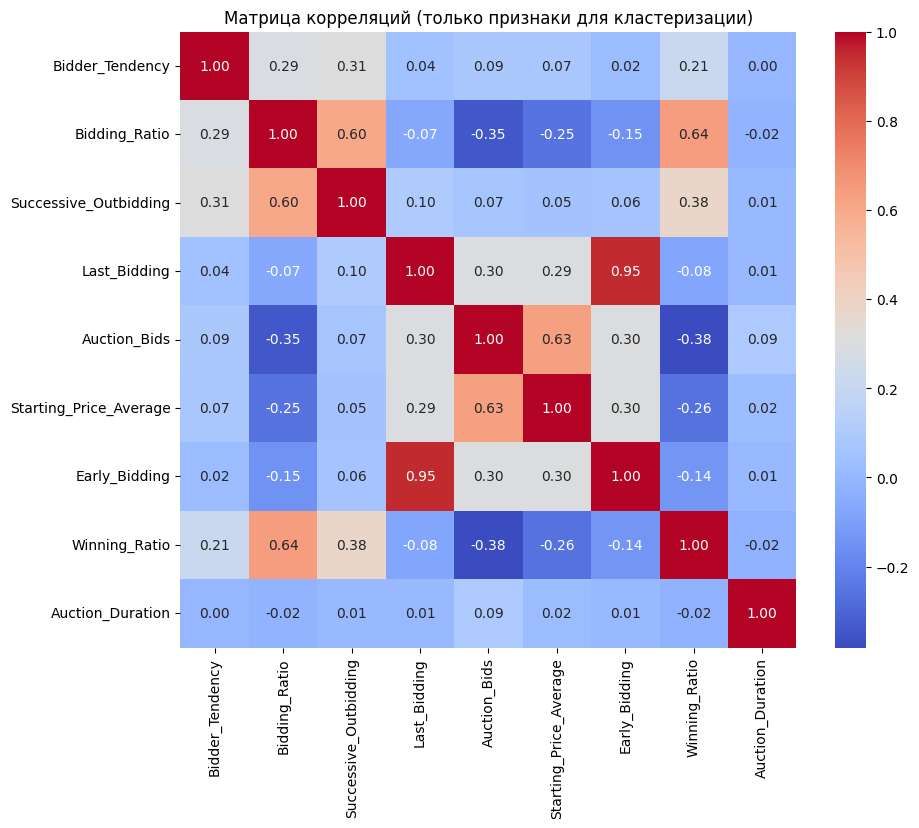

k = 2: silhouette = 0.2281, inertia = 44356.04
k = 3: silhouette = 0.2493, inertia = 36100.90
k = 4: silhouette = 0.2348, inertia = 31129.80
k = 5: silhouette = 0.2307, inertia = 28154.94
k = 6: silhouette = 0.2314, inertia = 25821.20
k = 7: silhouette = 0.2405, inertia = 23700.02
k = 8: silhouette = 0.2479, inertia = 22107.93
k = 9: silhouette = 0.2510, inertia = 20686.24
k = 10: silhouette = 0.2484, inertia = 19669.54

Лучшее k по среднему силуэту: 9 (silhouette = 0.2510)


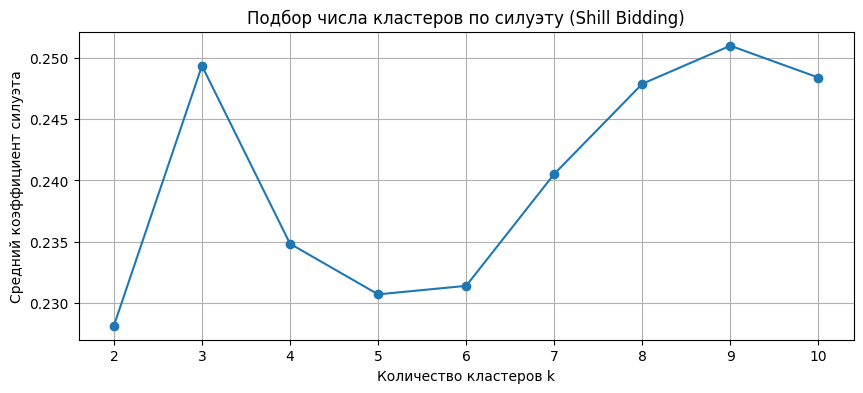

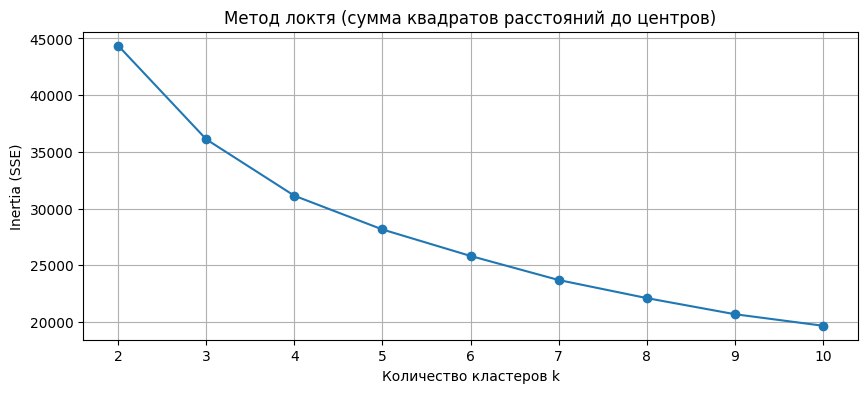

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- чтобы графики показывались в ноутбуке ---
%matplotlib inline

# =========================
# 1. Загрузка и первичный обзор
# =========================

df = pd.read_csv("Shill Bidding Dataset.csv")

print("Первые строки датасета:")
display(df.head())

print("\nРазмер датасета (строки, столбцы):", df.shape)

print("\nИнформация о колонках:")
df.info()

print("\nОписательная статистика по числовым признакам:")
display(df.describe().T)

# Распределение класса (0/1) — для информации, в кластеризации не используем
if "Class" in df.columns:
    print("\nРаспределение целевой переменной Class:")
    print(df["Class"].value_counts())
    print("\nДоли классов Class:")
    print(df["Class"].value_counts(normalize=True))

# Гистограммы числовых признаков
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# =========================
# 2. Матрица корреляций
# =========================

print("\nМатрица корреляций по всем числовым колонкам:")
corr_full = df[num_cols].corr()
display(corr_full)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Матрица корреляций (все числовые признаки, включая Class)")
plt.show()

# =========================
# 3. Признаки для кластеризации
# =========================
# Не берём идентификаторы и целевой класс:
# Record_ID, Auction_ID, Bidder_ID (строковый), Class

feature_cols = [
    "Bidder_Tendency",
    "Bidding_Ratio",
    "Successive_Outbidding",
    "Last_Bidding",
    "Auction_Bids",
    "Starting_Price_Average",
    "Early_Bidding",
    "Winning_Ratio",
    "Auction_Duration",
]

# Проверка, что все нужные признаки есть в датафрейме
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"В датасете нет колонок: {missing}")

X = df[feature_cols].copy()

print("\nМатрица корреляций только по признакам для кластеризации:")
corr_features = X.corr()
display(corr_features)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_features, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Матрица корреляций (только признаки для кластеризации)")
plt.show()

# =========================
# 4. Масштабирование признаков
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 5. Подбор числа кластеров по силуэту
# =========================

sil_scores = {}
inertias = {}

k_values = range(2, 11)  # перебираем k от 2 до 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
    inertias[k] = kmeans.inertia_
    
    print(f"k = {k}: silhouette = {sil:.4f}, inertia = {inertias[k]:.2f}")

# Лучшее k по среднему силуэту
best_k = max(sil_scores, key=sil_scores.get)
print(f"\nЛучшее k по среднему силуэту: {best_k} (silhouette = {sil_scores[best_k]:.4f})")

# =========================
# 6. Графики: силуэт и локоть (inertia)
# =========================

plt.figure(figsize=(10, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Средний коэффициент силуэта")
plt.title("Подбор числа кластеров по силуэту (Shill Bidding)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Inertia (SSE)")
plt.title("Метод локтя (сумма квадратов расстояний до центров)")
plt.grid(True)
plt.show()


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
hcv_data = fetch_ucirepo(id=571) 
  
# data (as pandas dataframes) 
X = hcv_data.data.features 
y = hcv_data.data.targets 
  
# metadata 
print(hcv_data.metadata) 
  
# variable information 
print(hcv_data.variables) 


{'uci_id': 571, 'name': 'HCV data', 'repository_url': 'https://archive.ics.uci.edu/dataset/571/hcv+data', 'data_url': 'https://archive.ics.uci.edu/static/public/571/data.csv', 'abstract': 'The data set contains laboratory values of blood donors and Hepatitis C patients and demographic values like age.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 615, 'num_features': 12, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['Category'], 'index_col': ['ID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5D612', 'creators': ['Ralf Lichtinghagen', 'Frank Klawonn', 'Georg Hoffmann'], 'intro_paper': {'ID': 237, 'type': 'NATIVE', 'title': 'Using machine learning techniques to generate laboratory diagnostic pathways—a case study', 'authors': 'Georg F. Hoffmann, A. Bietenb

Первые строки датасета:


,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,Category
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7,0=Blood Donor
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0,0=Blood Donor
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2,0=Blood Donor
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6,0=Blood Donor
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6,0=Blood Donor



Размер датасета (строки, столбцы): (615, 13)

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       615 non-null    int64  
 1   Sex       615 non-null    object 
 2   ALB       614 non-null    float64
 3   ALP       597 non-null    float64
 4   AST       615 non-null    float64
 5   BIL       615 non-null    float64
 6   CHE       615 non-null    float64
 7   CHOL      605 non-null    float64
 8   CREA      615 non-null    float64
 9   CGT       615 non-null    float64
 10  PROT      614 non-null    float64
 11  ALT       614 non-null    float64
 12  Category  615 non-null    object 
dtypes: float64(10), int64(1), object(2)
memory usage: 62.6+ KB

Количество пропусков по колонкам:
Age          0
Sex          0
ALB          1
ALP         18
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
CGT   

,count,mean,std,min,25%,50%,75%,max
Age,615.0,47.408130,10.055105,19.00,39.000,47.00,54.000,77.00
ALB,614.0,41.620195,5.780629,14.90,38.800,41.95,45.200,82.20
ALP,597.0,68.283920,26.028315,11.30,52.500,66.20,80.100,416.60
AST,615.0,34.786341,33.090690,10.60,21.600,25.90,32.900,324.00
BIL,615.0,11.396748,19.673150,0.80,5.300,7.30,11.200,254.00
CHE,615.0,8.196634,2.205657,1.42,6.935,8.26,9.590,16.41
CHOL,605.0,5.368099,1.132728,1.43,4.610,5.30,6.060,9.67
CREA,615.0,81.287805,49.756166,8.00,67.000,77.00,88.000,1079.10
CGT,615.0,39.533171,54.661071,4.50,15.700,23.30,40.200,650.90
PROT,614.0,72.044137,5.402636,44.80,69.300,72.20,75.400,90.00



Матрица корреляции (числа, все числовые колонки):


,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
Age,1.000,-0.197,0.173,0.089,0.032,-0.075,0.126,-0.022,0.153,-0.154,-0.006
ALB,-0.197,1.000,-0.142,-0.193,-0.222,0.376,0.208,-0.002,-0.156,0.557,0.002
ALP,0.173,-0.142,1.000,0.064,0.056,0.034,0.125,0.150,0.455,-0.055,0.214
AST,0.089,-0.193,0.064,1.000,0.312,-0.209,-0.210,-0.021,0.491,0.040,0.273
BIL,0.032,-0.222,0.056,0.312,1.000,-0.333,-0.180,0.031,0.217,-0.048,-0.038
CHE,-0.075,0.376,0.034,-0.209,-0.333,1.000,0.425,-0.011,-0.110,0.295,0.147
CHOL,0.126,0.208,0.125,-0.210,-0.180,0.425,1.000,-0.048,-0.007,0.207,0.069
CREA,-0.022,-0.002,0.150,-0.021,0.031,-0.011,-0.048,1.000,0.121,-0.032,-0.043
CGT,0.153,-0.156,0.455,0.491,0.217,-0.110,-0.007,0.121,1.000,-0.012,0.248
PROT,-0.154,0.557,-0.055,0.040,-0.048,0.295,0.207,-0.032,-0.012,1.000,0.095


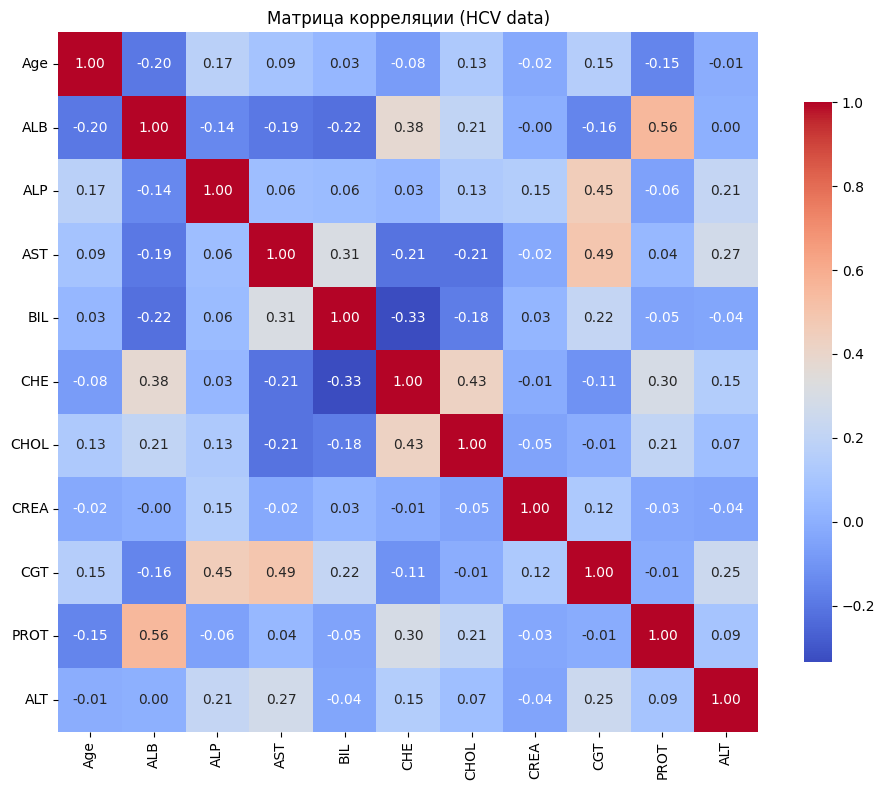


Матрица корреляции (только числовые признаки без таргета):


,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
Age,1.000,-0.197,0.173,0.089,0.032,-0.075,0.126,-0.022,0.153,-0.154,-0.006
ALB,-0.197,1.000,-0.142,-0.193,-0.222,0.376,0.208,-0.002,-0.156,0.557,0.002
ALP,0.173,-0.142,1.000,0.064,0.056,0.034,0.125,0.150,0.455,-0.055,0.214
AST,0.089,-0.193,0.064,1.000,0.312,-0.209,-0.210,-0.021,0.491,0.040,0.273
BIL,0.032,-0.222,0.056,0.312,1.000,-0.333,-0.180,0.031,0.217,-0.048,-0.038
CHE,-0.075,0.376,0.034,-0.209,-0.333,1.000,0.425,-0.011,-0.110,0.295,0.147
CHOL,0.126,0.208,0.125,-0.210,-0.180,0.425,1.000,-0.048,-0.007,0.207,0.069
CREA,-0.022,-0.002,0.150,-0.021,0.031,-0.011,-0.048,1.000,0.121,-0.032,-0.043
CGT,0.153,-0.156,0.455,0.491,0.217,-0.110,-0.007,0.121,1.000,-0.012,0.248
PROT,-0.154,0.557,-0.055,0.040,-0.048,0.295,0.207,-0.032,-0.012,1.000,0.095


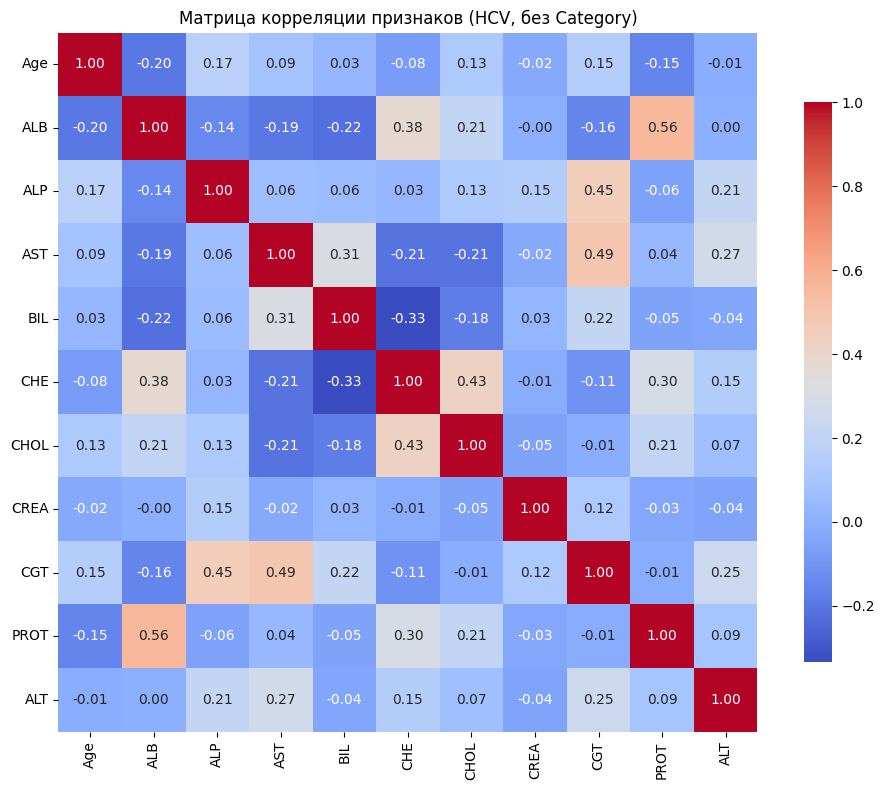


Признаки для кластеризации:
['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT', 'ALT']
k = 2: silhouette = 0.5942, inertia = 5741.50
k = 3: silhouette = 0.1344, inertia = 5203.06
k = 4: silhouette = 0.1391, inertia = 4746.45
k = 5: silhouette = 0.1272, inertia = 4388.94
k = 6: silhouette = 0.1356, inertia = 3971.35
k = 7: silhouette = 0.1359, inertia = 3770.10
k = 8: silhouette = 0.1426, inertia = 3435.23
k = 9: silhouette = 0.1241, inertia = 3272.73
k = 10: silhouette = 0.1318, inertia = 3051.51

Лучшее k по среднему силуэту: 2 (silhouette = 0.5942)


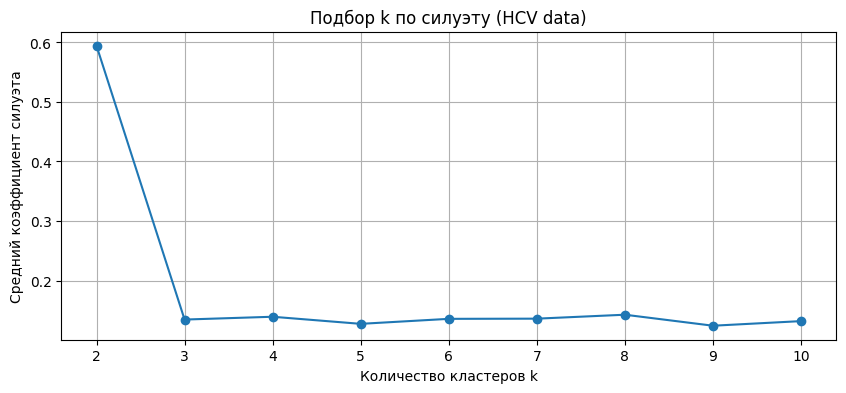

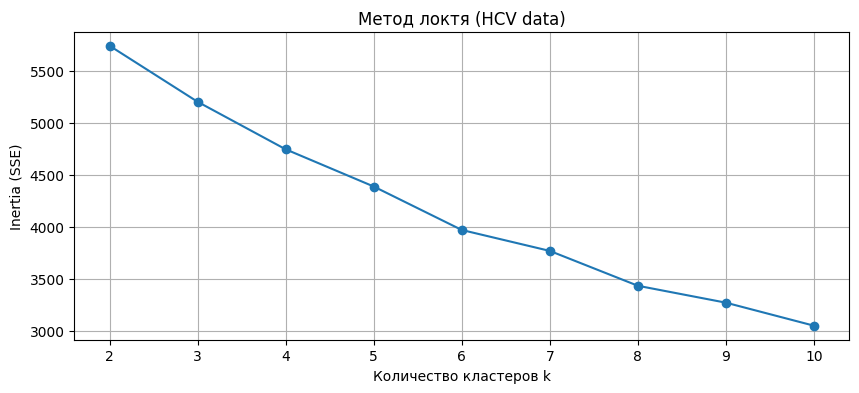

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

# =========================
# 1. Загрузка датасета HCV
# =========================

hcv_data = fetch_ucirepo(id=571)

X = hcv_data.data.features    # ID, Age, Sex, ALB, ALP, AST, BIL, CHE, CHOL, CREA, CGT, PROT, ALT
y = hcv_data.data.targets     # Category

# Соберём всё в один датафрейм для удобства
df = pd.concat([X, y], axis=1)

print("Первые строки датасета:")
display(df.head())

print("\nРазмер датасета (строки, столбцы):", df.shape)

print("\nИнформация о колонках:")
df.info()

print("\nКоличество пропусков по колонкам:")
print(df.isna().sum())

print("\nОписательная статистика по числовым признакам:")
display(df.describe().T)

# =========================
# 2. Матрица корреляции
# =========================

# Матрица корреляций только по числовым признакам (включая Category)
corr_full = df.select_dtypes(include=[np.number]).corr()

print("\nМатрица корреляции (числа, все числовые колонки):")
display(corr_full.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_full,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции (HCV data)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Можно отдельно построить матрицу корреляций только по признакам без таргета Category:
numeric_features = X.select_dtypes(include=[np.number]).columns
corr_features = X[numeric_features].corr()

print("\nМатрица корреляции (только числовые признаки без таргета):")
display(corr_features.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_features,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков (HCV, без Category)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# 3. Подготовка данных для кластеризации
# =========================
# Не используем ID, Sex, Category — это идентификатор, пол и диагноз.
# Берём только числовые лабораторные параметры + возраст.

drop_cols = ["ID", "Sex"]  # Category и так в y
feature_cols = [c for c in X.columns if c not in drop_cols]

print("\nПризнаки для кластеризации:")
print(feature_cols)

X_clust = X[feature_cols].copy()

# Импутация пропусков (медианой)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clust)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =========================
# 4. Подбор числа кластеров по силуэту
# =========================

sil_scores = {}
inertias = {}

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
    inertias[k] = kmeans.inertia_
    
    print(f"k = {k}: silhouette = {sil:.4f}, inertia = {inertias[k]:.2f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nЛучшее k по среднему силуэту: {best_k} "
      f"(silhouette = {sil_scores[best_k]:.4f})")

# =========================
# 5. Графики: силуэт и локоть
# =========================

plt.figure(figsize=(10, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Средний коэффициент силуэта")
plt.title("Подбор k по силуэту (HCV data)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Inertia (SSE)")
plt.title("Метод локтя (HCV data)")
plt.grid(True)
plt.show()


Распределение объектов по кластерам:
Cluster
0    579
1     36
Name: count, dtype: int64


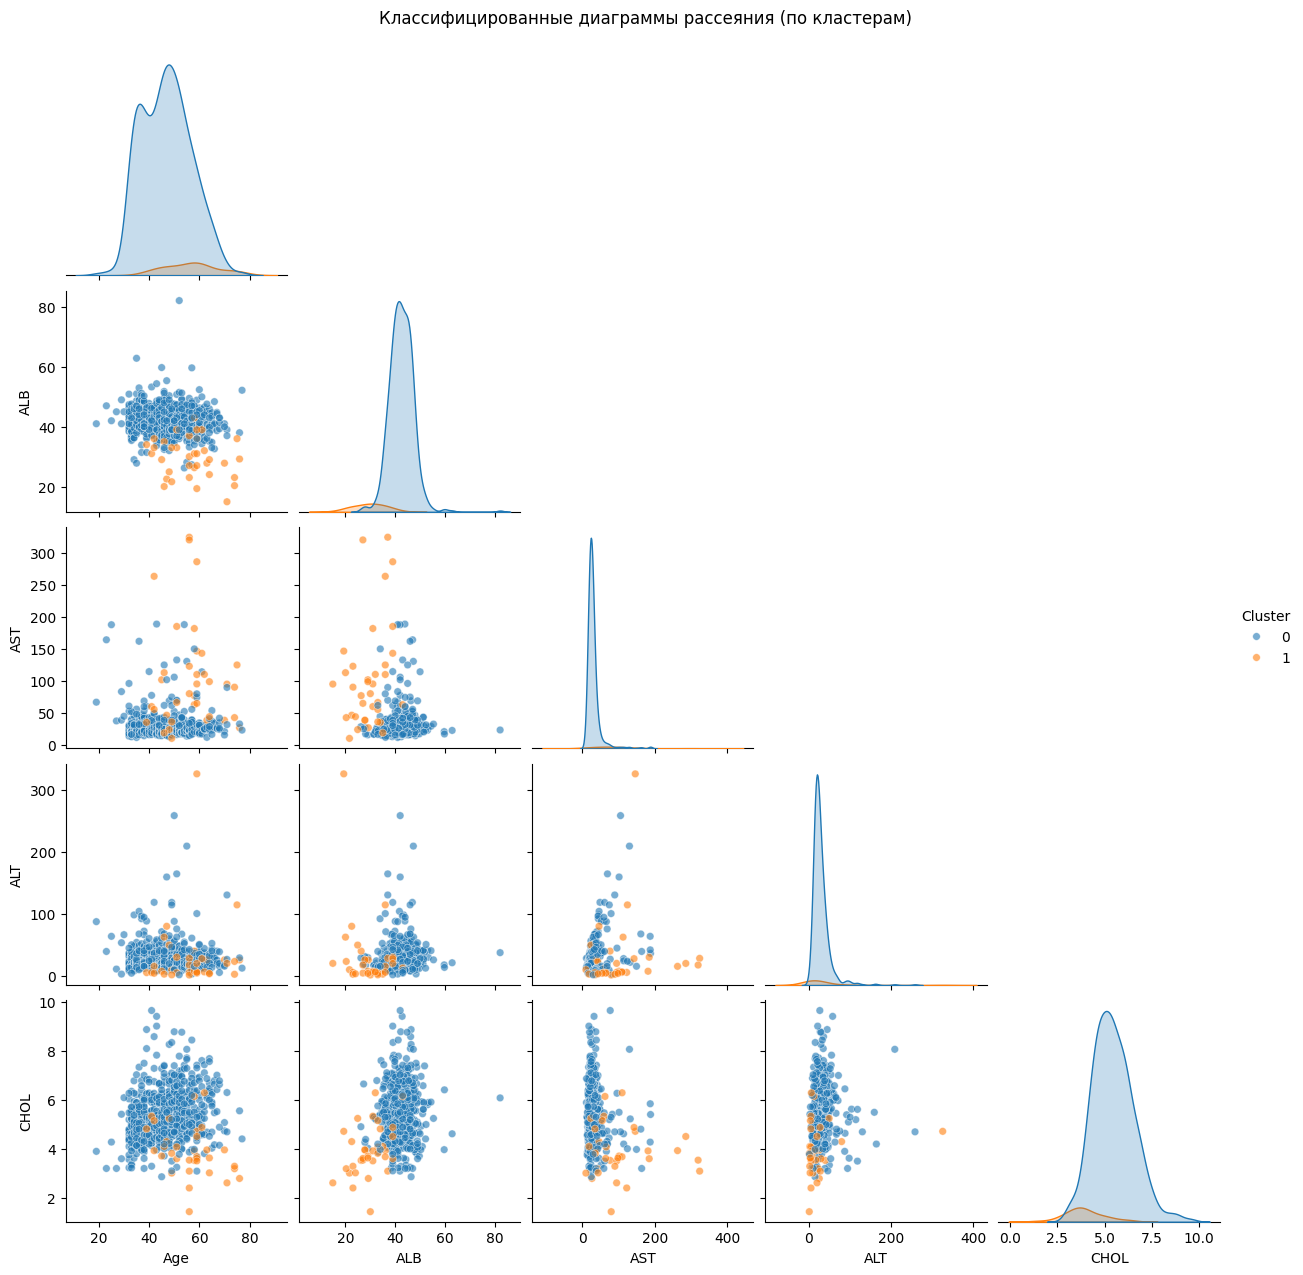

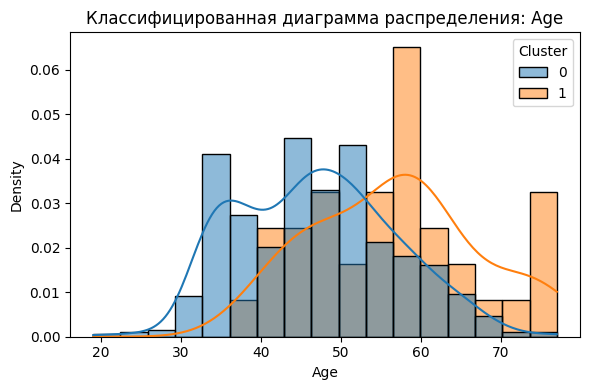

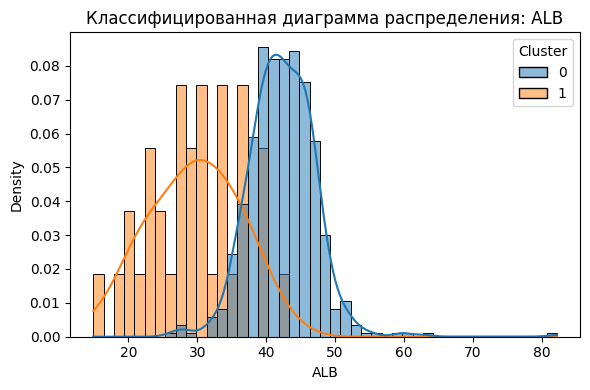

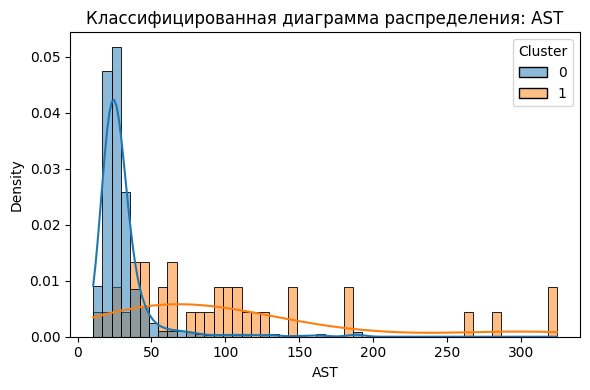

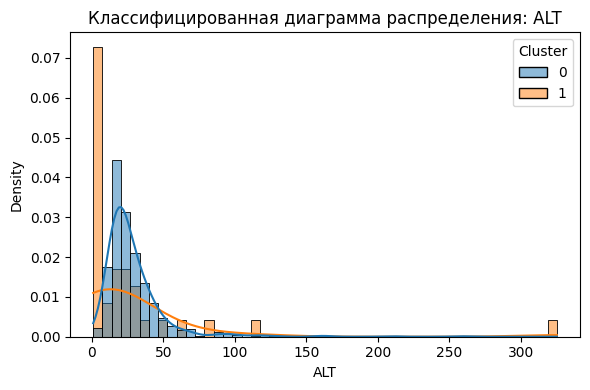

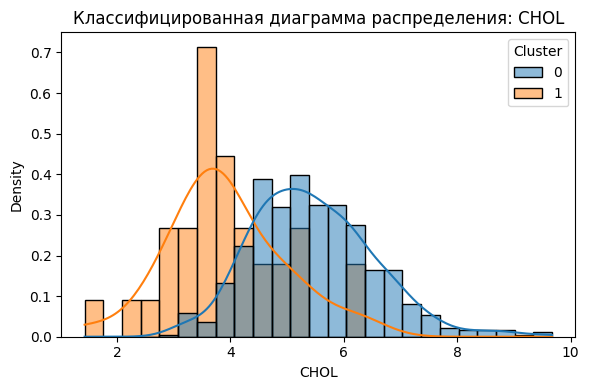

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

# =========================
# 1. Загрузка HCV data
# =========================

hcv_data = fetch_ucirepo(id=571)

X = hcv_data.data.features    # ID, Age, Sex, ALB, ALP, AST, BIL, CHE, CHOL, CREA, CGT, PROT, ALT
y = hcv_data.data.targets     # Category

df = pd.concat([X, y], axis=1)

# =========================
# 2. Подготовка данных для кластеризации
# =========================

# Не используем ID, Sex, Category
drop_cols = ["ID", "Sex"]
feature_cols = [c for c in X.columns if c not in drop_cols]

X_clust = X[feature_cols].copy()

# Импутация пропусков (медиана)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clust)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =========================
# 3. KMeans и кластеры (k = 2)
# =========================

k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# добавим кластеры в df для визуализации
df_plot = df.copy()
df_plot["Cluster"] = labels.astype(str)  # строкой, чтобы красиво в легенде

print("Распределение объектов по кластерам:")
print(df_plot["Cluster"].value_counts())

# =========================
# 4. Классифицированные диаграммы распределения
# =========================
# Возьмём несколько ключевых признаков, чтобы не перегружать графики
plot_cols = ["Age", "ALB", "AST", "ALT", "CHOL"]

# 4.1. Составная диаграмма рассеяния (pairplot) с раскраской по кластерам
sns.pairplot(
    df_plot,
    vars=plot_cols,
    hue="Cluster",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 30}
)
plt.suptitle("Классифицированные диаграммы рассеяния (по кластерам)", y=1.02)
plt.show()

# 4.2. Диаграммы распределения (hist+KDE) по кластерам
for col in plot_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df_plot,
        x=col,
        hue="Cluster",
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.5
    )
    plt.title(f"Классифицированная диаграмма распределения: {col}")
    plt.tight_layout()
    plt.show()


Используем признаки для кластеризации:
['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT', 'ALT']

=== Метод: kmeans ===
k = 2: silhouette = 0.5942
k = 3: silhouette = 0.1344
k = 4: silhouette = 0.1391
k = 5: silhouette = 0.1272
k = 6: silhouette = 0.1356
k = 7: silhouette = 0.1359
k = 8: silhouette = 0.1426
k = 9: silhouette = 0.1241
k = 10: silhouette = 0.1318

=== Метод: agg_ward ===
k = 2: silhouette = 0.5133
k = 3: silhouette = 0.5022
k = 4: silhouette = 0.4946
k = 5: silhouette = 0.4537
k = 6: silhouette = 0.1053
k = 7: silhouette = 0.1117
k = 8: silhouette = 0.0836
k = 9: silhouette = 0.0914
k = 10: silhouette = 0.0870

=== Метод: agg_average ===
k = 2: silhouette = 0.8087
k = 3: silhouette = 0.7849
k = 4: silhouette = 0.7466
k = 5: silhouette = 0.6807
k = 6: silhouette = 0.6487
k = 7: silhouette = 0.6124
k = 8: silhouette = 0.6055
k = 9: silhouette = 0.5663
k = 10: silhouette = 0.5633

=== Метод: gmm_full ===
k = 2: silhouette = 0.4024
k = 3: silhouette = 

method,agg_average,agg_ward,gmm_diag,gmm_full,kmeans
k,,,,,
2,0.809,0.513,0.423,0.402,0.594
3,0.785,0.502,0.045,0.065,0.134
4,0.747,0.495,0.037,0.145,0.139
5,0.681,0.454,0.043,0.029,0.127
6,0.649,0.105,0.023,0.029,0.136
7,0.612,0.112,0.022,0.029,0.136
8,0.605,0.084,-0.002,0.016,0.143
9,0.566,0.091,0.021,0.029,0.124
10,0.563,0.087,0.030,0.027,0.132



Лучший результат:
метод = agg_average, k = 2, silhouette = 0.8087


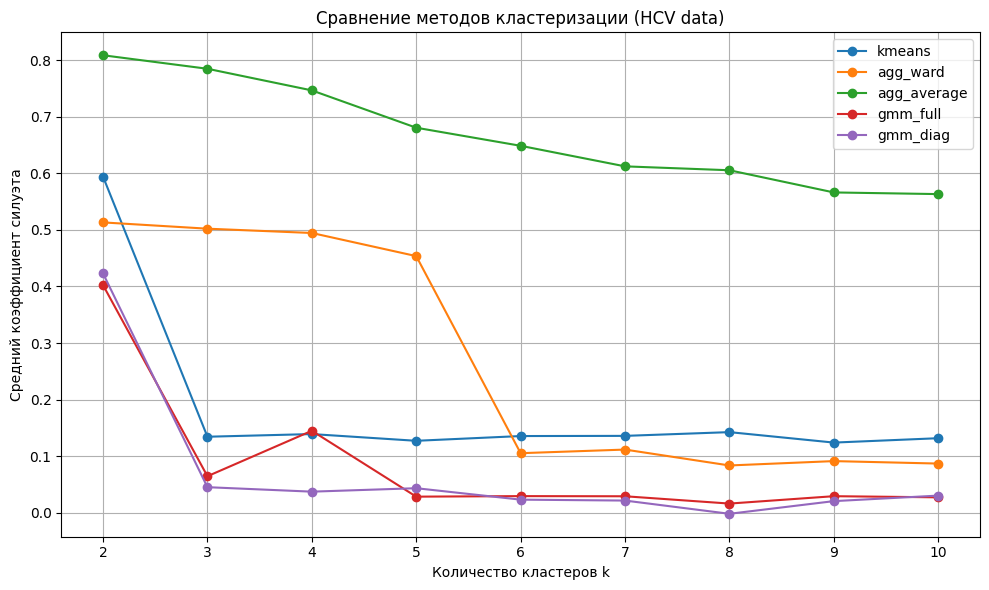

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

%matplotlib inline

# =========================
# 1. Загрузка и подготовка данных
# =========================

hcv_data = fetch_ucirepo(id=571)

X = hcv_data.data.features    # ID, Age, Sex, ALB, ALP, AST, BIL, CHE, CHOL, CREA, CGT, PROT, ALT

# выбрасываем ID и Sex, оставляем возраст + анализы
drop_cols = ["ID", "Sex"]
feature_cols = [c for c in X.columns if c not in drop_cols]

X_clust = X[feature_cols].copy()

# Импутация пропусков (медианой)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clust)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Используем признаки для кластеризации:")
print(feature_cols)

# =========================
# 2. Определяем набор кластеризаторов
# =========================

clusterers = {
    "kmeans": lambda k: KMeans(n_clusters=k, random_state=42, n_init=10),
    "agg_ward": lambda k: AgglomerativeClustering(n_clusters=k, linkage="ward"),
    "agg_average": lambda k: AgglomerativeClustering(n_clusters=k, linkage="average"),
    "gmm_full": lambda k: GaussianMixture(
        n_components=k, covariance_type="full", random_state=42
    ),
    "gmm_diag": lambda k: GaussianMixture(
        n_components=k, covariance_type="diag", random_state=42
    ),
}

# =========================
# 3. Прогоняем все методы по k = 2..10
# =========================

results = []
k_range = range(2, 11)

for name, builder in clusterers.items():
    print(f"\n=== Метод: {name} ===")
    for k in k_range:
        model = builder(k)
        # для GMM используем fit + predict, для остальных fit_predict
        if isinstance(model, GaussianMixture):
            labels = model.fit(X_scaled).predict(X_scaled)
        else:
            labels = model.fit_predict(X_scaled)

        sil = silhouette_score(X_scaled, labels)
        results.append({"method": name, "k": k, "silhouette": sil})
        print(f"k = {k}: silhouette = {sil:.4f}")

# =========================
# 4. Таблица результатов
# =========================

res_df = pd.DataFrame(results)
pivot = res_df.pivot(index="k", columns="method", values="silhouette")
print("\nСилуэт по методам и числу кластеров:")
display(pivot.round(3))

# Найдём глобально лучший вариант
best_idx = res_df["silhouette"].idxmax()
best_row = res_df.loc[best_idx]
print(
    f"\nЛучший результат:\n"
    f"метод = {best_row['method']}, k = {int(best_row['k'])}, "
    f"silhouette = {best_row['silhouette']:.4f}"
)

# =========================
# 5. График зависимости силуэта от k для разных методов
# =========================

plt.figure(figsize=(10, 6))
for name in res_df["method"].unique():
    subset = res_df[res_df["method"] == name]
    plt.plot(subset["k"], subset["silhouette"], marker="o", label=name)

plt.xlabel("Количество кластеров k")
plt.ylabel("Средний коэффициент силуэта")
plt.title("Сравнение методов кластеризации (HCV data)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

%matplotlib inline

# =========================
# 1. Загрузка и подготовка данных
# =========================

hcv_data = fetch_ucirepo(id=571)

X = hcv_data.data.features    # ID, Age, Sex, ALB, ALP, AST, BIL, CHE, CHOL, CREA, CGT, PROT, ALT

# убираем ID и Sex, оставляем возраст + анализы
drop_cols = ["ID", "Sex"]
feature_cols = [c for c in X.columns if c not in drop_cols]

X_clust = X[feature_cols].copy()

# Импутация пропусков (медианой)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clust)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Признаки для кластеризации (DBSCAN):")
print(feature_cols)

# =========================
# 2. Перебор параметров DBSCAN
# =========================

eps_values = np.linspace(0.3, 2.0, 15)   # сетка eps (подберёшь при необходимости)
min_samples_values = [3, 5, 10]          # несколько вариантов min_samples

results = []

for min_samples in min_samples_values:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
        labels = db.fit_predict(X_scaled)

        # количество кластеров (без шума)
        unique_labels = set(labels)
        n_clusters = len([l for l in unique_labels if l != -1])
        n_noise = np.sum(labels == -1)

        # если меньше 2 кластеров (или все шум) — силуэт бессмысленен
        if n_clusters < 2:
            sil = np.nan
        else:
            # считаем силуэт только по точкам, которые НЕ шум
            mask_core = labels != -1
            X_core = X_scaled[mask_core]
            labels_core = labels[mask_core]

            if len(np.unique(labels_core)) < 2:
                sil = np.nan
            else:
                sil = silhouette_score(X_core, labels_core)

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": int(n_noise),
            "silhouette_core": sil
        })

# =========================
# 3. Таблица результатов
# =========================

res_df = pd.DataFrame(results)
print("\nРезультаты DBSCAN (отфильтрованы случаи с >=2 кластерами):")
display(res_df[~res_df["silhouette_core"].isna()].sort_values(
    by="silhouette_core",
    ascending=False
).head(20).round(3))

# Найдём лучший вариант
valid = res_df[~res_df["silhouette_core"].isna()]
if not valid.empty:
    best_idx = valid["silhouette_core"].idxmax()
    best_row = valid.loc[best_idx]
    print(
        f"\nЛучший результат DBSCAN:\n"
        f"eps = {best_row['eps']:.3f}, "
        f"min_samples = {int(best_row['min_samples'])}, "
        f"n_clusters = {int(best_row['n_clusters'])}, "
        f"n_noise = {int(best_row['n_noise'])}, "
        f"silhouette_core = {best_row['silhouette_core']:.4f}"
    )
else:
    print("\nDBSCAN ни при каких параметрах не дал разбиения хотя бы на 2 кластера (все точки — один кластер или шум).")


Признаки для кластеризации (DBSCAN):
['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT', 'ALT']

Результаты DBSCAN (отфильтрованы случаи с >=2 кластерами):


,eps,min_samples,n_clusters,n_noise,silhouette_core
4,0.786,3,8,585,0.423
36,1.029,10,2,594,0.324
20,0.907,5,7,570,0.257
13,1.879,3,3,86,0.205
8,1.271,3,3,221,0.119
5,0.907,3,19,489,0.113
9,1.393,3,3,179,0.070
10,1.514,3,4,145,0.043
21,1.029,5,3,461,0.013
7,1.150,3,6,287,-0.020



Лучший результат DBSCAN:
eps = 0.786, min_samples = 3, n_clusters = 8, n_noise = 585, silhouette_core = 0.4232


Признаки для кластеризации:
['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT', 'ALT']

Распределение по кластерам:
Cluster
0    614
1      1
Name: count, dtype: int64


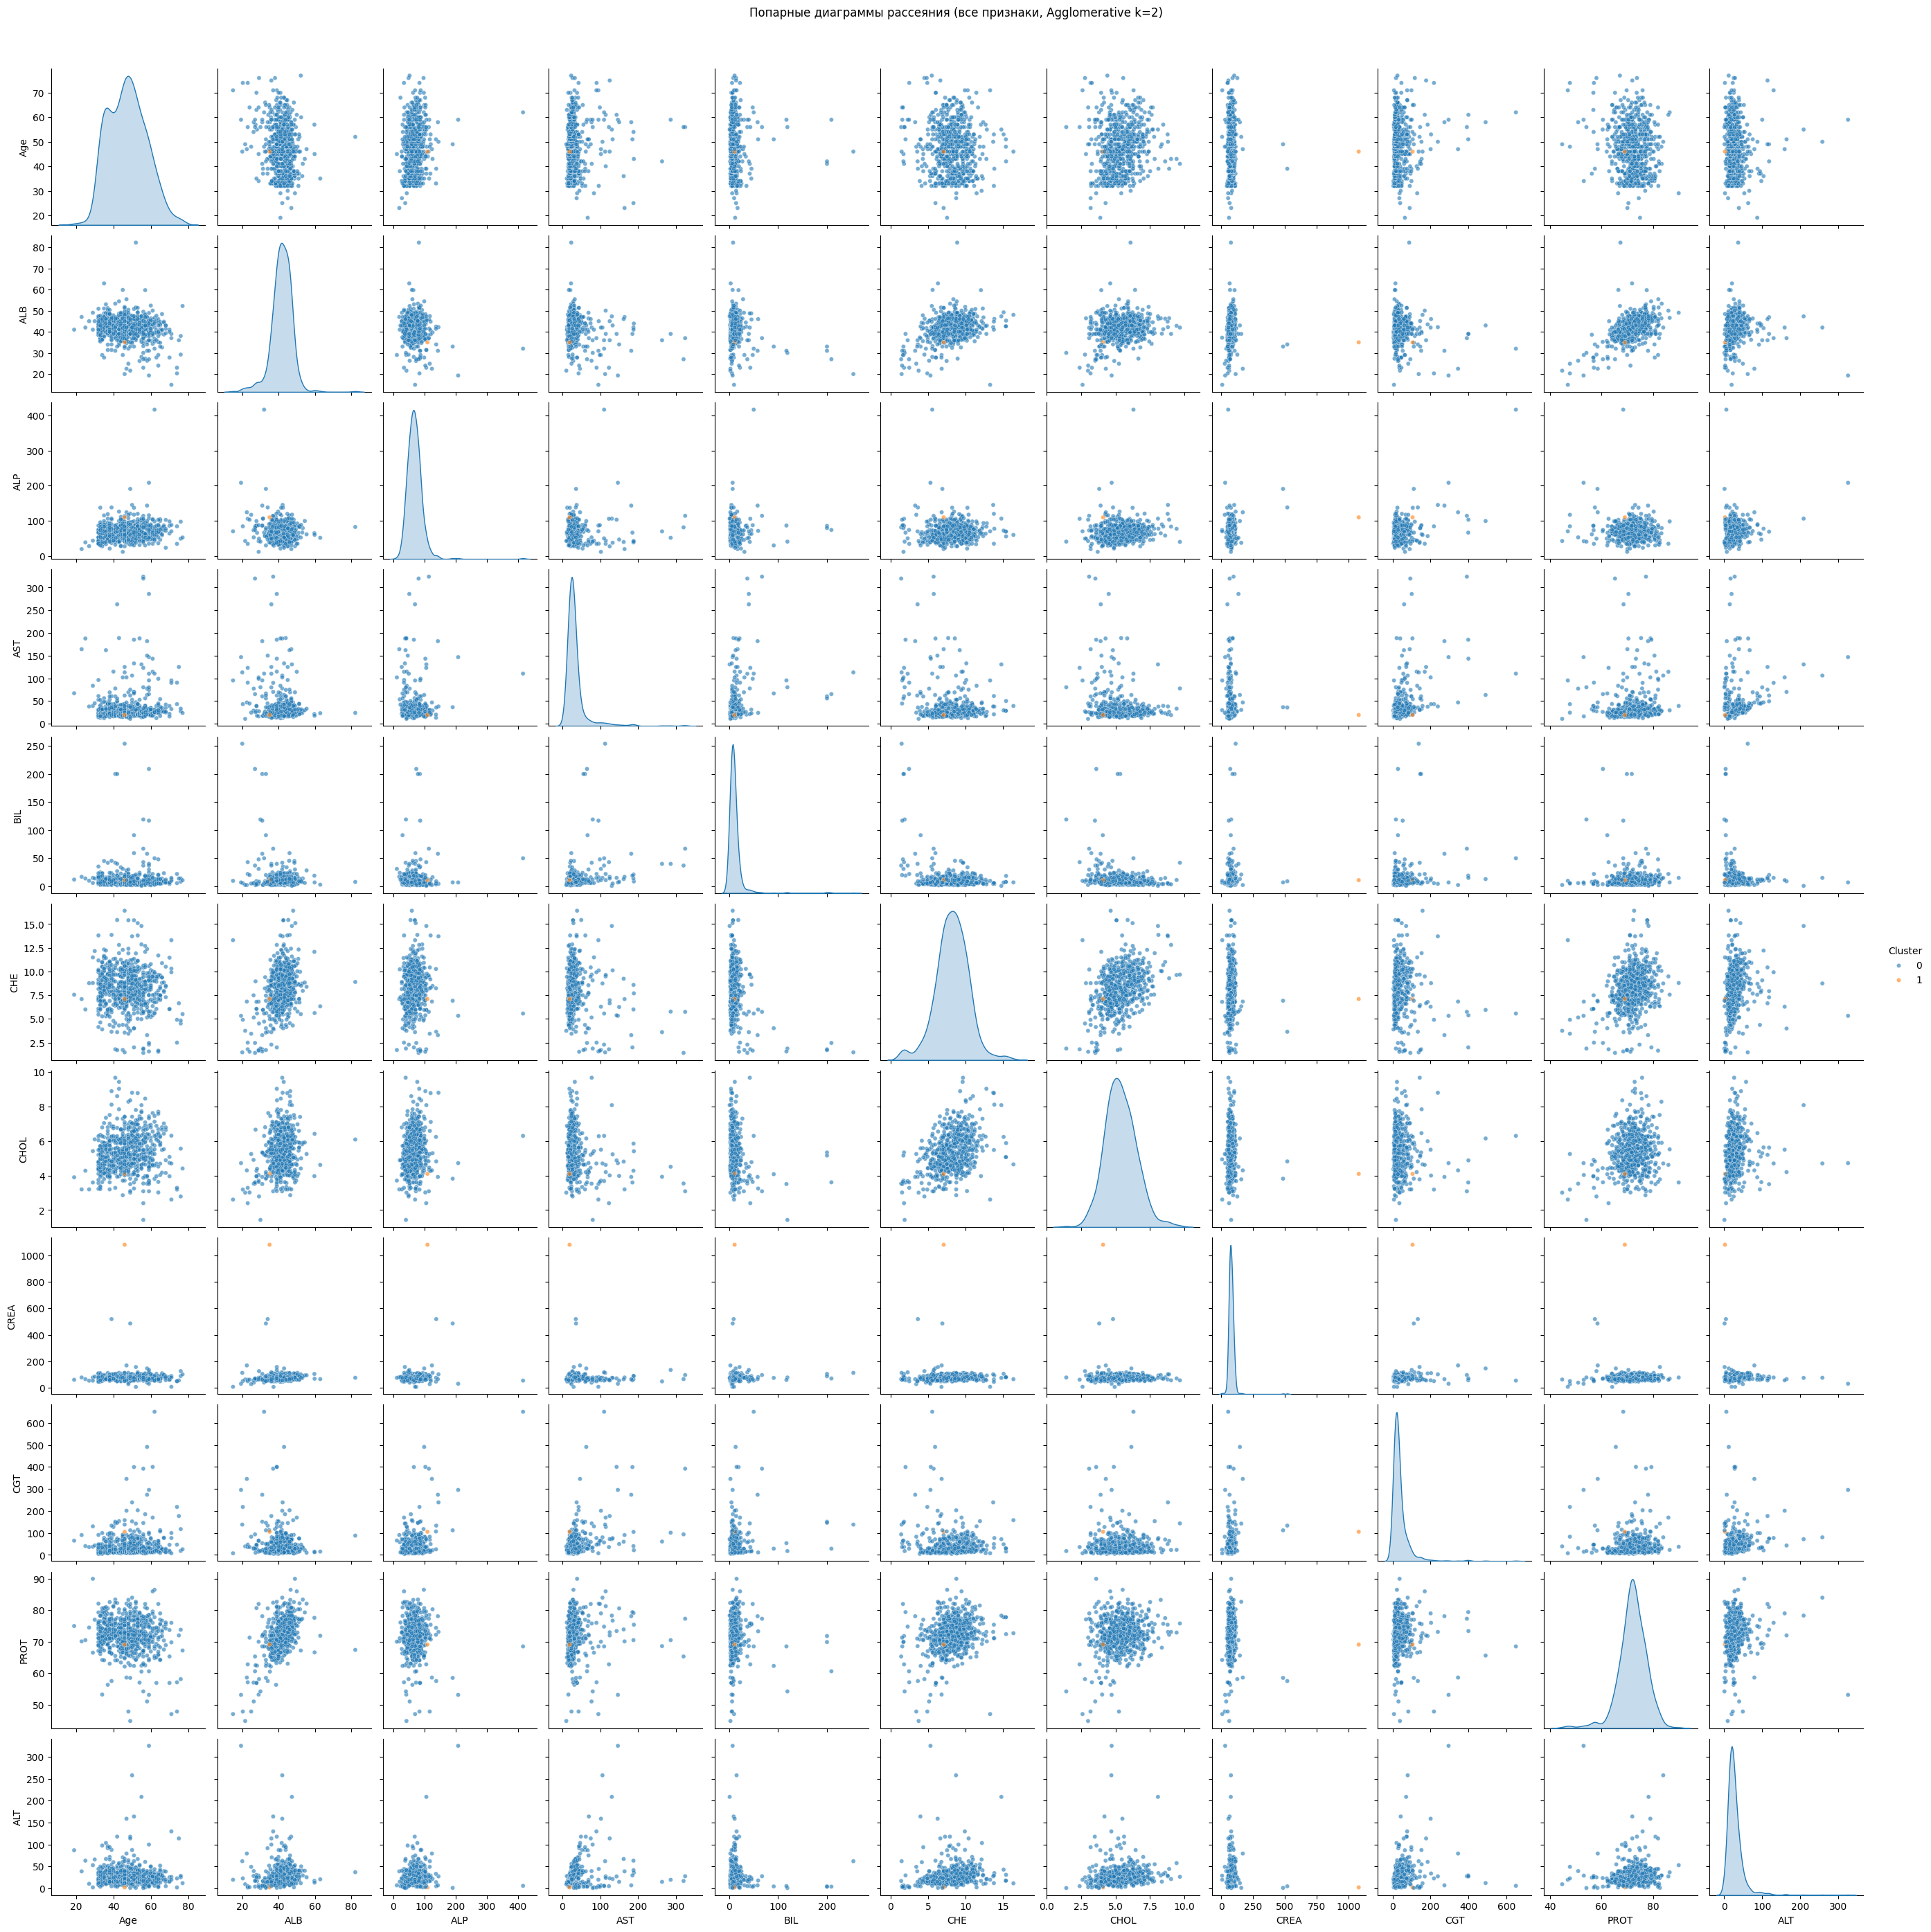

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

%matplotlib inline

# =========================
# 1. Загрузка и подготовка данных
# =========================

hcv_data = fetch_ucirepo(id=571)

X = hcv_data.data.features    # ID, Age, Sex, ALB, ALP, AST, BIL, CHE, CHOL, CREA, CGT, PROT, ALT
y = hcv_data.data.targets     # Category

# Убираем ID и Sex, оставляем возраст + анализы
drop_cols = ["ID", "Sex"]
feature_cols = [c for c in X.columns if c not in drop_cols]

X_clust = X[feature_cols].copy()

# Импутация пропусков (медианой)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clust)

# Масштабирование
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Признаки для кластеризации:")
print(feature_cols)

# =========================
# 2. Лучшая кластеризация: Agglomerative (average), k = 2
# =========================

agg = AgglomerativeClustering(n_clusters=2, linkage="average")
labels_agg2 = agg.fit_predict(X_scaled)

# Собираем датафрейм для визуализации
df_plot = X_clust.copy()
df_plot["Cluster"] = labels_agg2.astype(str)   # строкой, чтобы красиво в легенде

print("\nРаспределение по кластерам:")
print(df_plot["Cluster"].value_counts())

# =========================
# 3. Попарные диаграммы рассеяния для ВСЕХ признаков
# =========================

sns.pairplot(
    df_plot,
    vars=feature_cols,     # все признаки
    hue="Cluster",         # раскраска по кластерам
    diag_kind="kde",       # на диагонали плотности
    corner=False,          # полный квадрат (если хочешь половину — поставь True)
    plot_kws={"alpha": 0.6, "s": 20}
)
plt.suptitle("Попарные диаграммы рассеяния (все признаки, Agglomerative k=2)", y=1.02)
plt.show()


Первые строки исходного датасета:


,Gender,Age,Height,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   family_history_with_overweight  2111 non-null   object 
 4   FAVC                            2111 non-null   object 
 5   FCVC                            2111 non-null   float64
 6   NCP                             2111 non-null   float64
 7   CAEC                            2111 non-null   object 
 8   SMOKE                           2111 non-null   object 
 9   CH2O                            2111 non-null   float64
 10  SCC                             2111 non-null   object 
 11  FAF                             2111 non-null   float64
 12  TUE       

,Gender,Age,Height,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,1,1
1,0,21.0,1.52,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,1,1
2,1,23.0,1.80,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,1,1
3,1,27.0,1.80,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,3,2
4,1,22.0,1.78,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,1,3



Матрица корреляции (таблица):


,Gender,Age,Height,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
Gender,1.000,0.048,0.618,0.103,0.065,-0.275,0.068,-0.092,0.045,0.108,-0.103,0.190,0.017,-0.008,-0.080,-0.031
Age,0.048,1.000,-0.026,0.206,0.064,0.016,-0.044,-0.084,0.092,-0.045,-0.116,-0.145,-0.297,0.044,-0.491,0.283
Height,0.618,-0.026,1.000,0.248,0.178,-0.038,0.244,-0.049,0.055,0.213,-0.134,0.295,0.052,0.130,-0.032,0.134
family_history_with_overweight,0.103,0.206,0.248,1.000,0.208,0.040,0.071,-0.170,0.017,0.147,-0.185,-0.057,0.023,-0.037,-0.108,0.505
FAVC,0.065,0.064,0.178,0.208,1.000,-0.027,-0.007,-0.150,-0.051,0.010,-0.191,-0.108,0.068,0.090,-0.152,0.248
FCVC,-0.275,0.016,-0.038,0.040,-0.027,1.000,0.042,0.055,0.014,0.068,0.072,0.020,-0.101,0.061,0.052,0.228
NCP,0.068,-0.044,0.244,0.071,-0.007,0.042,1.000,0.098,0.008,0.057,-0.016,0.130,0.036,0.072,-0.034,0.027
CAEC,-0.092,-0.084,-0.049,-0.170,-0.150,0.055,0.098,1.000,0.055,-0.145,0.109,0.030,0.049,-0.048,0.074,-0.329
SMOKE,0.045,0.092,0.055,0.017,-0.051,0.014,0.008,0.055,1.000,-0.032,0.048,0.011,0.018,0.082,-0.004,0.003
CH2O,0.108,-0.045,0.213,0.147,0.010,0.068,0.057,-0.145,-0.032,1.000,0.008,0.167,0.012,0.091,0.042,0.133


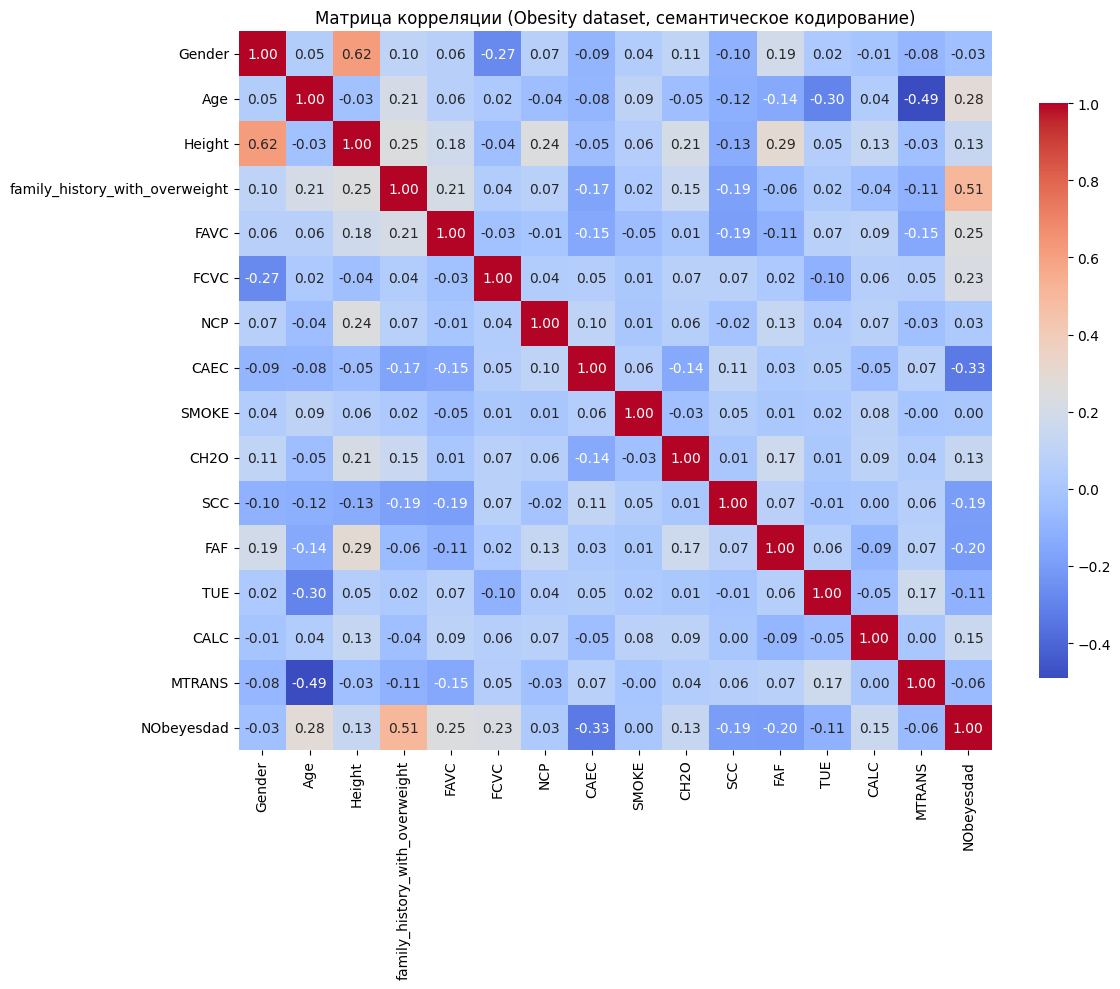


Признаки, используемые для кластеризации (без таргета):
['Gender', 'Age', 'Height', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']

Средний коэффициент силуэта для k-means при разных k:
k = 2: silhouette = 0.1227, inertia = 28348.97
k = 3: silhouette = 0.1323, inertia = 26184.19
k = 4: silhouette = 0.1171, inertia = 24205.33
k = 5: silhouette = 0.1227, inertia = 22658.51
k = 6: silhouette = 0.1273, inertia = 21286.00
k = 7: silhouette = 0.1442, inertia = 19737.62
k = 8: silhouette = 0.1451, inertia = 18754.99
k = 9: silhouette = 0.1537, inertia = 18113.53
k = 10: silhouette = 0.1465, inertia = 17667.36

Лучшее k по среднему силуэту: 9 (silhouette = 0.1537)


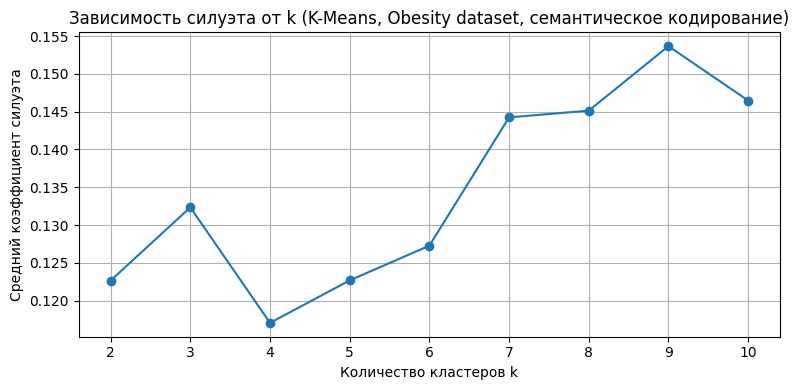

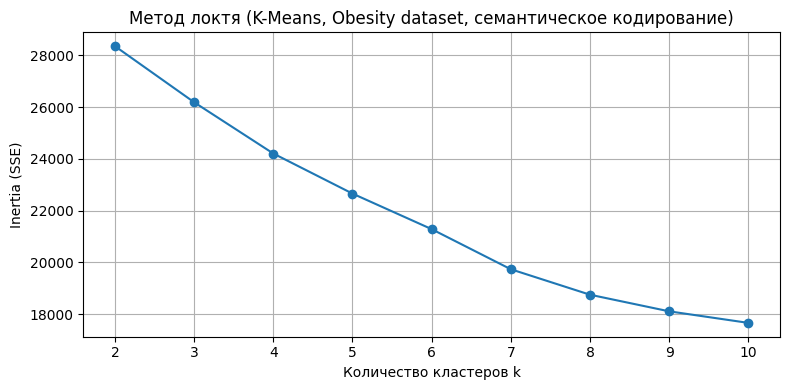

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

# =========================
# 1. Загрузка датасета
# =========================

obesity_data = fetch_ucirepo(id=544)

X = obesity_data.data.features    # признаки
y = obesity_data.data.targets     # таргет NObeyesdad

df = pd.concat([X, y], axis=1)
df = df.drop(columns=["Weight"])  # выбрасываем ID

print("Первые строки исходного датасета:")
display(df.head())

print("\nИнформация о колонках:")
df.info()

# =========================
# 2. Семантическое кодирование категорий
# =========================

df_mapped = df.copy()

# 2.1. Gender: Female=0, Male=1
gender_map = {"Female": 0, "Male": 1}
df_mapped["Gender"] = df_mapped["Gender"].map(gender_map)

# 2.2. Бинарные признаки yes/no -> 1/0
binary_map = {"no": 0, "yes": 1}

for col in ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]:
    df_mapped[col] = df_mapped[col].map(binary_map)

# 2.3. Упорядоченные частоты: no < Sometimes < Frequently < Always
ordinal_freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_mapped["CAEC"] = df_mapped["CAEC"].map(ordinal_freq_map)
df_mapped["CALC"] = df_mapped["CALC"].map(ordinal_freq_map)

# 2.4. Транспорт по "активности":
#    0 - самый "пассивный" (сидим), 3 - самая активная форма
mtrans_map = {
    "Automobile": 0,
    "Motorbike": 0,
    "Public_Transportation": 1,
    "Bike": 2,
    "Walking": 3,
}
df_mapped["MTRANS"] = df_mapped["MTRANS"].map(mtrans_map)

# 2.5. Таргет NObeyesdad: шкала тяжести
obesity_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6,
}
target_col = y.columns[0]  # 'NObeyesdad'
df_mapped[target_col] = df_mapped[target_col].map(obesity_map)

print("\nИнформация о датафрейме после кодирования:")
df_mapped.info()

print("\nПервые строки после кодирования:")
display(df_mapped.head())

# =========================
# 3. Матрица корреляции (после кодирования)
# =========================

corr = df_mapped.corr()

print("\nМатрица корреляции (таблица):")
display(corr.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции (Obesity dataset, семантическое кодирование)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# 4. Подготовка данных для кластеризации (без таргета)
# =========================

feature_cols = [c for c in df_mapped.columns if c != target_col]

print("\nПризнаки, используемые для кластеризации (без таргета):")
print(feature_cols)

X_clust = df_mapped[feature_cols].copy()

# Импутация (на всякий случай, если вдруг что-то пропало при map)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clust)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =========================
# 5. K-Means и средний коэффициент силуэта
# =========================

sil_scores = {}
inertias = {}
k_values = range(2, 11)

print("\nСредний коэффициент силуэта для k-means при разных k:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
    inertias[k] = kmeans.inertia_
    
    print(f"k = {k}: silhouette = {sil:.4f}, inertia = {inertias[k]:.2f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nЛучшее k по среднему силуэту: {best_k} "
      f"(silhouette = {sil_scores[best_k]:.4f})")

# =========================
# 6. Графики: силуэт и локоть
# =========================

plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Средний коэффициент силуэта")
plt.title("Зависимость силуэта от k (K-Means, Obesity dataset, семантическое кодирование)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.xlabel("Количество кластеров k")
plt.ylabel("Inertia (SSE)")
plt.title("Метод локтя (K-Means, Obesity dataset, семантическое кодирование)")
plt.grid(True)
plt.tight_layout()
plt.show()


Первые строки исходного датасета:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Колонки после кодирования:
Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

Признаки, используемые для кластеризации (без таргета и без Weight):
['Gender', 'Age', 'Height', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']

Матрица корреляции по признакам (без таргета):


,Gender,Age,Height,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
Gender,1.000,0.048,0.618,0.103,0.065,-0.275,0.068,-0.092,0.045,0.108,-0.103,0.190,0.017,-0.008,-0.080
Age,0.048,1.000,-0.026,0.206,0.064,0.016,-0.044,-0.084,0.092,-0.045,-0.116,-0.145,-0.297,0.044,-0.491
Height,0.618,-0.026,1.000,0.248,0.178,-0.038,0.244,-0.049,0.055,0.213,-0.134,0.295,0.052,0.130,-0.032
family_history_with_overweight,0.103,0.206,0.248,1.000,0.208,0.040,0.071,-0.170,0.017,0.147,-0.185,-0.057,0.023,-0.037,-0.108
FAVC,0.065,0.064,0.178,0.208,1.000,-0.027,-0.007,-0.150,-0.051,0.010,-0.191,-0.108,0.068,0.090,-0.152
FCVC,-0.275,0.016,-0.038,0.040,-0.027,1.000,0.042,0.055,0.014,0.068,0.072,0.020,-0.101,0.061,0.052
NCP,0.068,-0.044,0.244,0.071,-0.007,0.042,1.000,0.098,0.008,0.057,-0.016,0.130,0.036,0.072,-0.034
CAEC,-0.092,-0.084,-0.049,-0.170,-0.150,0.055,0.098,1.000,0.055,-0.145,0.109,0.030,0.049,-0.048,0.074
SMOKE,0.045,0.092,0.055,0.017,-0.051,0.014,0.008,0.055,1.000,-0.032,0.048,0.011,0.018,0.082,-0.004
CH2O,0.108,-0.045,0.213,0.147,0.010,0.068,0.057,-0.145,-0.032,1.000,0.008,0.167,0.012,0.091,0.042


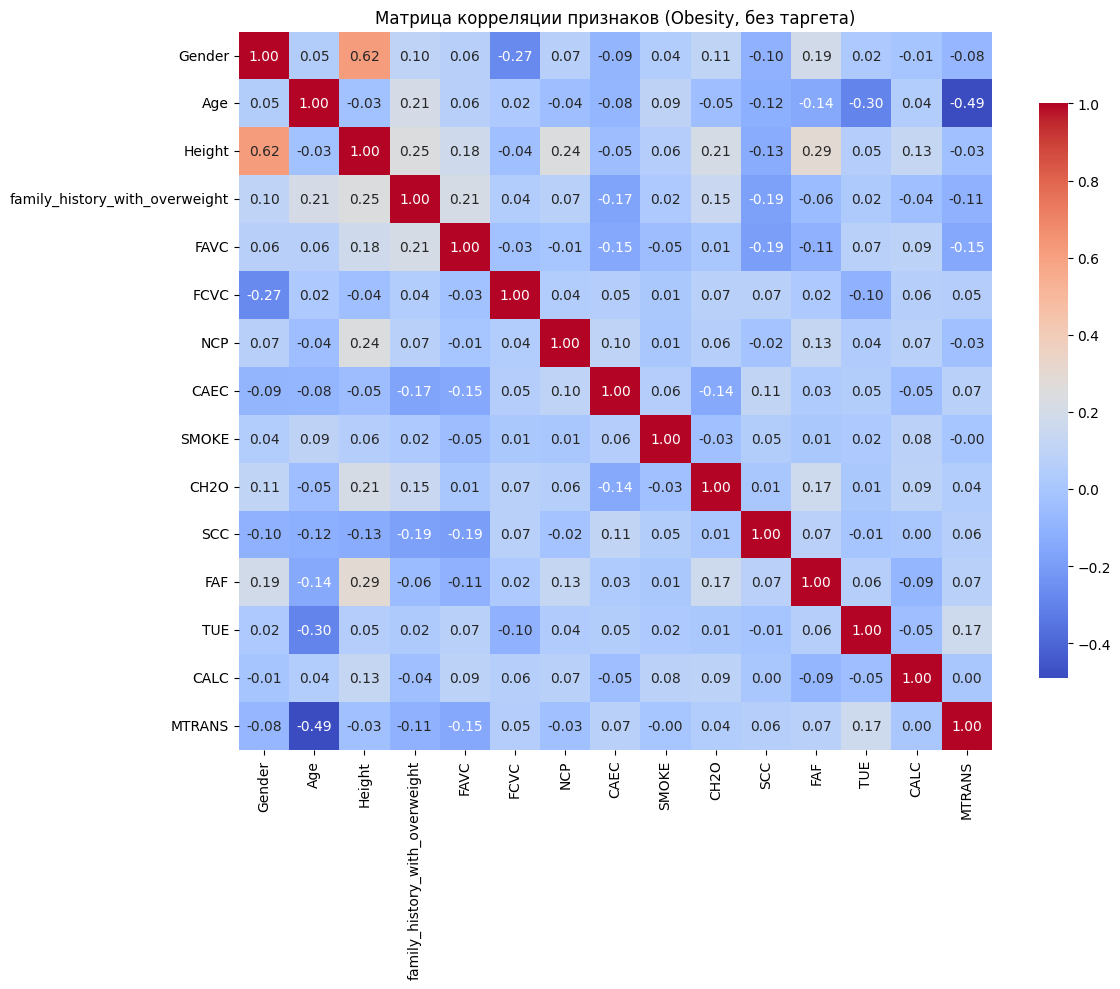


Матрица корреляции по всем числовым столбцам (с таргетом и Weight):


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
Gender,1.000,0.048,0.618,0.162,0.103,0.065,-0.275,0.068,-0.092,0.045,0.108,-0.103,0.190,0.017,-0.008,-0.080,-0.031
Age,0.048,1.000,-0.026,0.203,0.206,0.064,0.016,-0.044,-0.084,0.092,-0.045,-0.116,-0.145,-0.297,0.044,-0.491,0.283
Height,0.618,-0.026,1.000,0.463,0.248,0.178,-0.038,0.244,-0.049,0.055,0.213,-0.134,0.295,0.052,0.130,-0.032,0.134
Weight,0.162,0.203,0.463,1.000,0.497,0.272,0.216,0.107,-0.287,0.026,0.201,-0.202,-0.051,-0.072,0.207,-0.046,0.913
family_history_with_overweight,0.103,0.206,0.248,0.497,1.000,0.208,0.040,0.071,-0.170,0.017,0.147,-0.185,-0.057,0.023,-0.037,-0.108,0.505
FAVC,0.065,0.064,0.178,0.272,0.208,1.000,-0.027,-0.007,-0.150,-0.051,0.010,-0.191,-0.108,0.068,0.090,-0.152,0.248
FCVC,-0.275,0.016,-0.038,0.216,0.040,-0.027,1.000,0.042,0.055,0.014,0.068,0.072,0.020,-0.101,0.061,0.052,0.228
NCP,0.068,-0.044,0.244,0.107,0.071,-0.007,0.042,1.000,0.098,0.008,0.057,-0.016,0.130,0.036,0.072,-0.034,0.027
CAEC,-0.092,-0.084,-0.049,-0.287,-0.170,-0.150,0.055,0.098,1.000,0.055,-0.145,0.109,0.030,0.049,-0.048,0.074,-0.329
SMOKE,0.045,0.092,0.055,0.026,0.017,-0.051,0.014,0.008,0.055,1.000,-0.032,0.048,0.011,0.018,0.082,-0.004,0.003


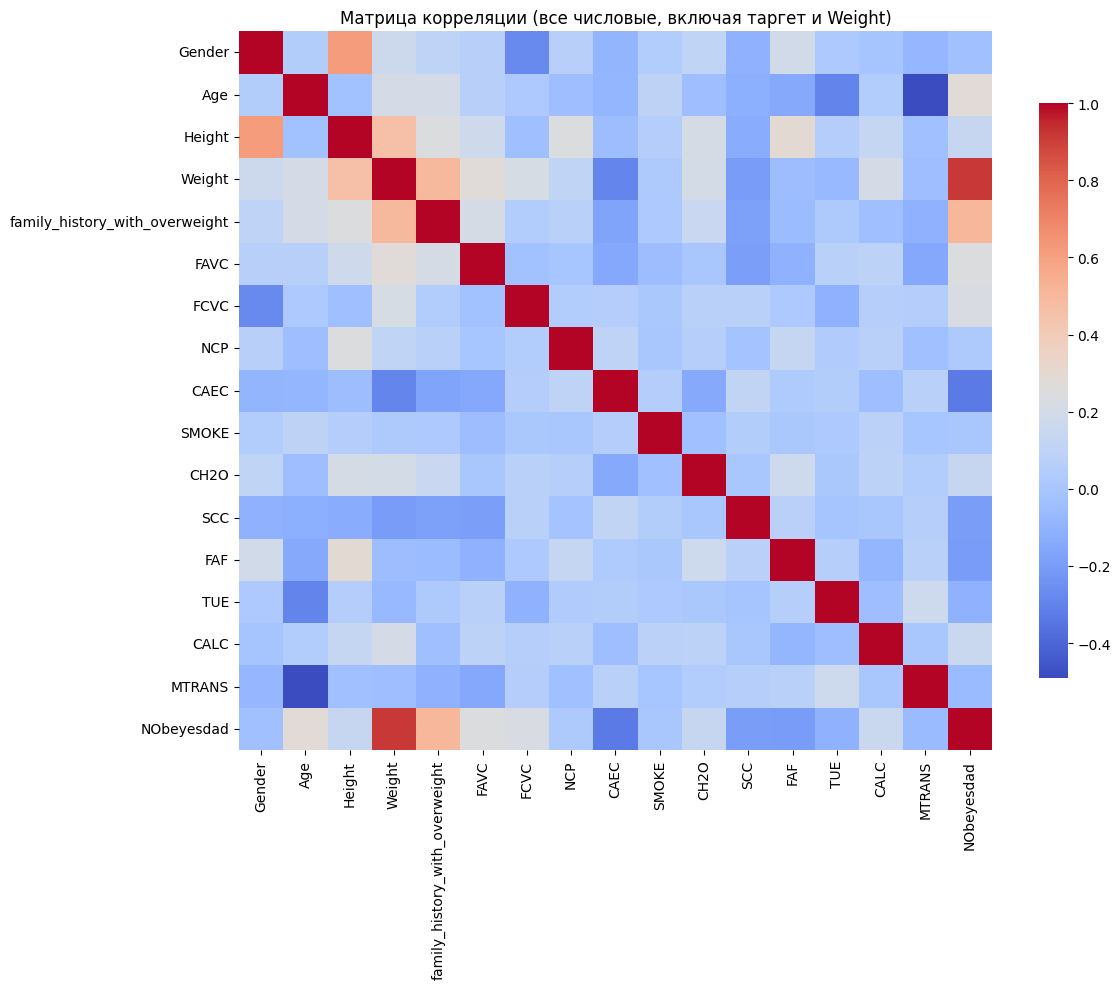


Средний коэффициент силуэта для k-means при разных k:
k = 2: silhouette = 0.1227, inertia = 28348.97
k = 3: silhouette = 0.1323, inertia = 26184.19
k = 4: silhouette = 0.1171, inertia = 24205.33
k = 5: silhouette = 0.1227, inertia = 22658.51
k = 6: silhouette = 0.1273, inertia = 21286.00
k = 7: silhouette = 0.1442, inertia = 19737.62
k = 8: silhouette = 0.1451, inertia = 18754.99
k = 9: silhouette = 0.1537, inertia = 18113.53
k = 10: silhouette = 0.1465, inertia = 17667.36

Лучшее k по среднему силуэту: 9 (silhouette = 0.1537)

Распределение по кластерам (k-means):
Cluster
2    506
1    401
4    254
3    232
6    218
7    183
0    182
8     91
5     44
Name: count, dtype: int64

Распределение по классам ожирения:
Class_str
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


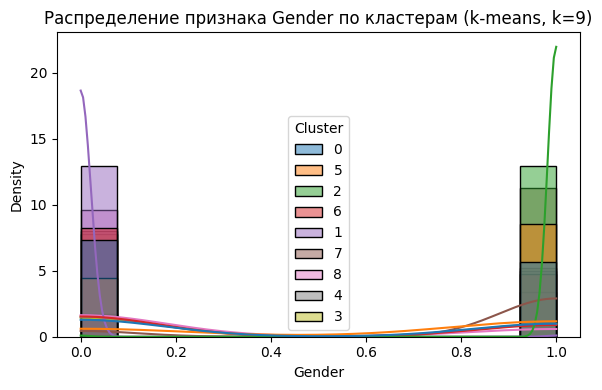

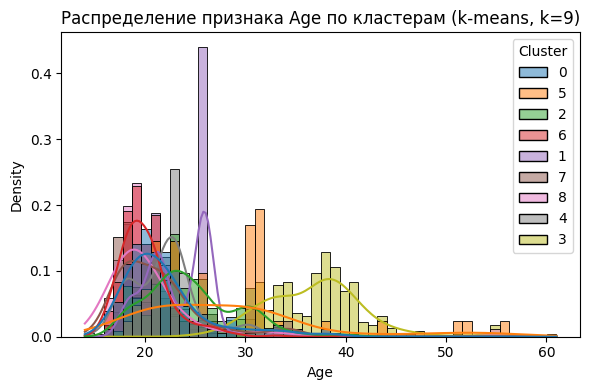

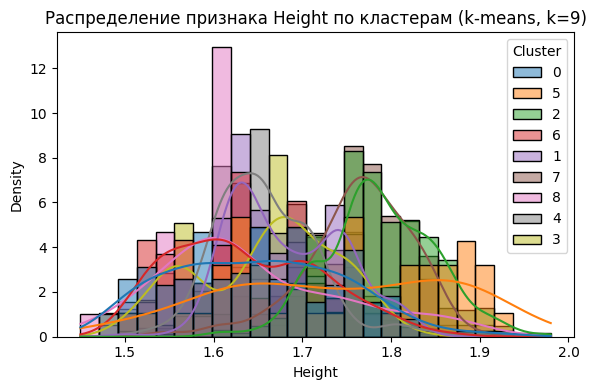

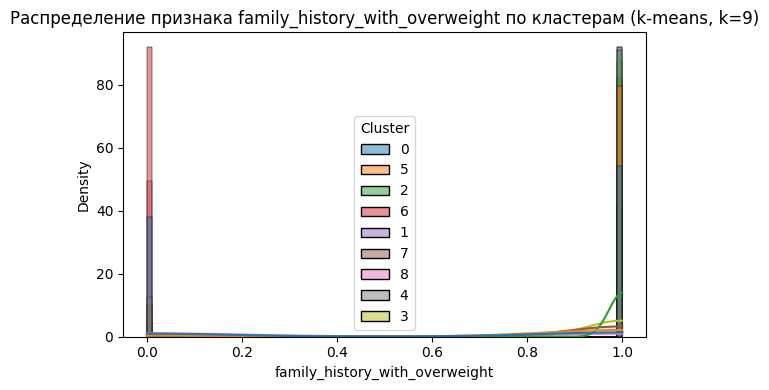

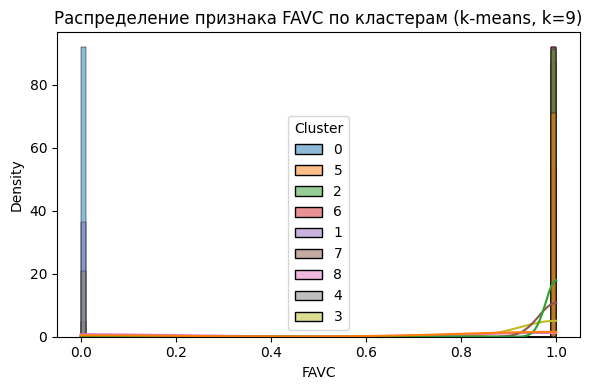

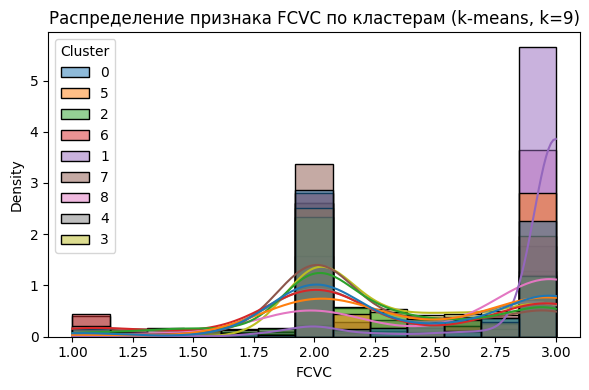

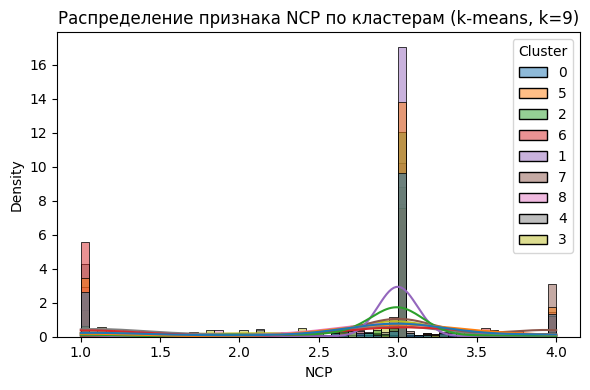

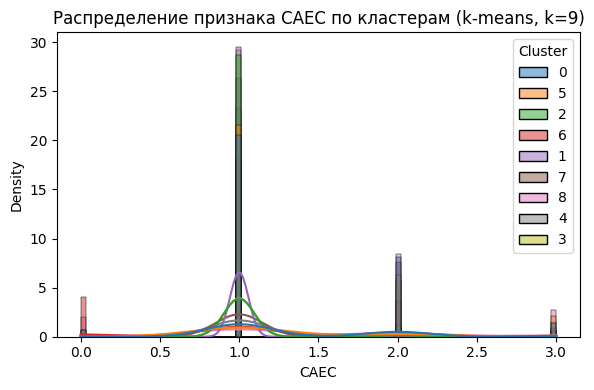

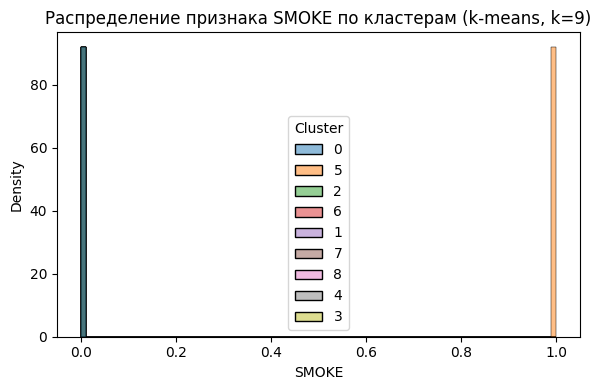

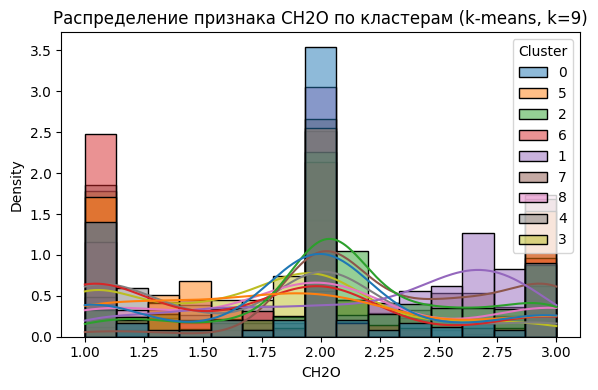

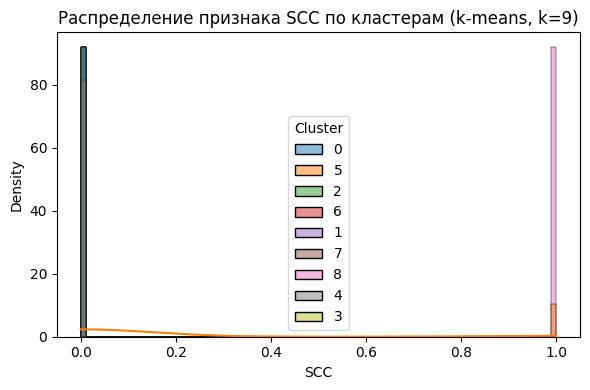

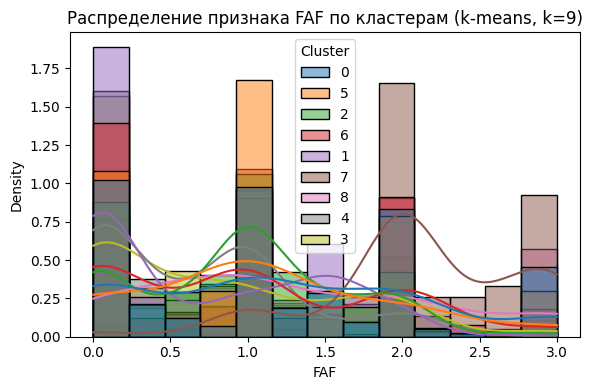

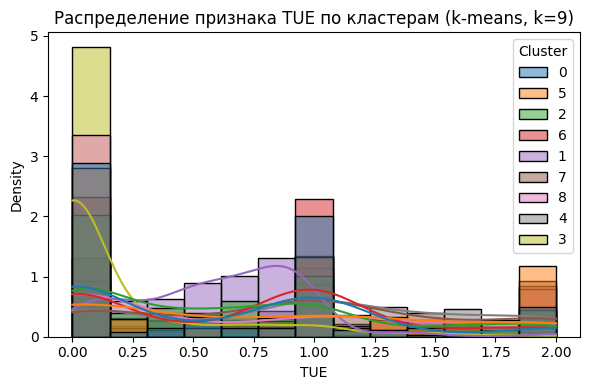

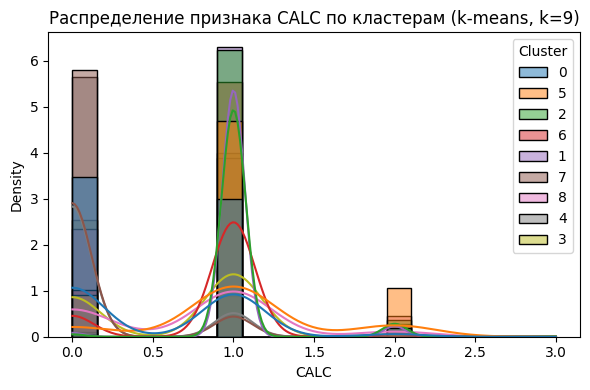

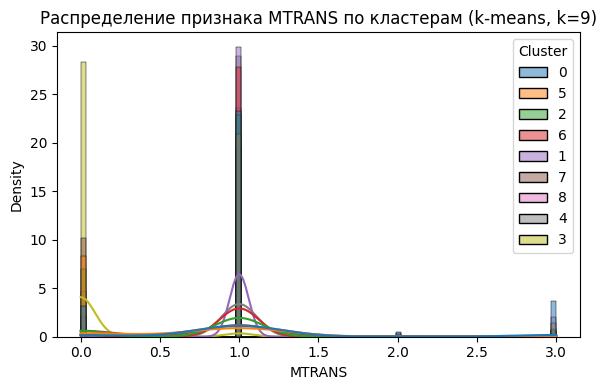

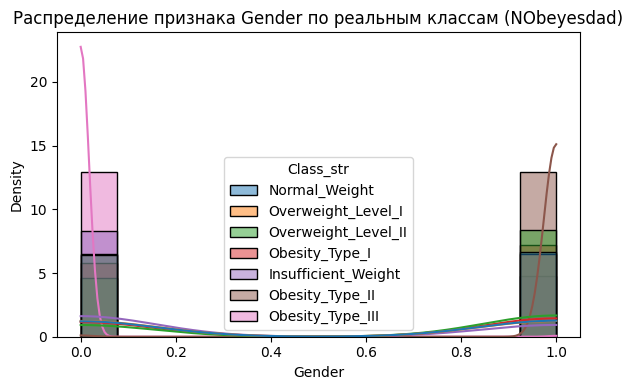

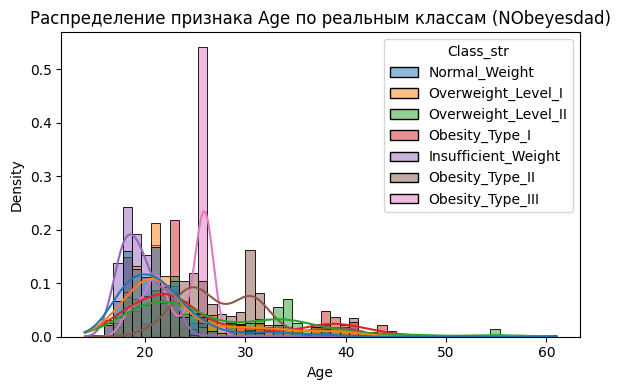

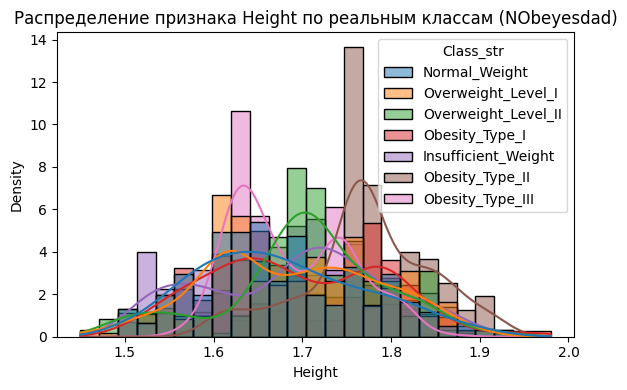

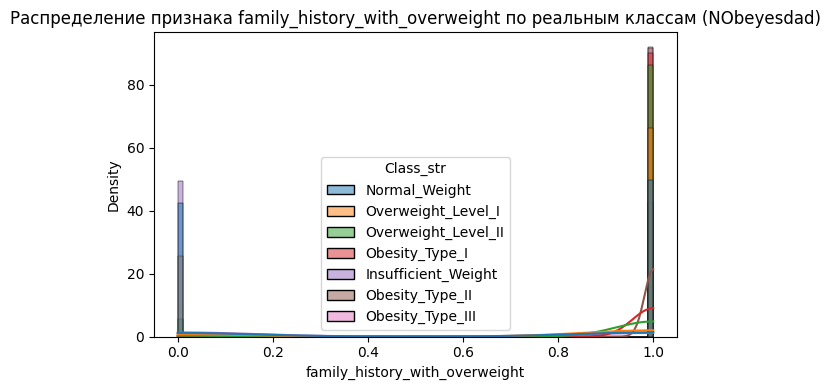

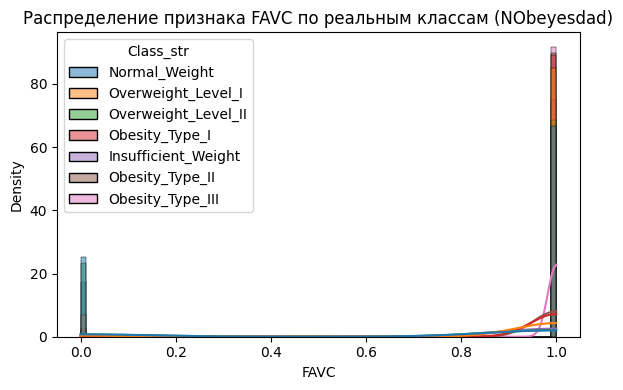

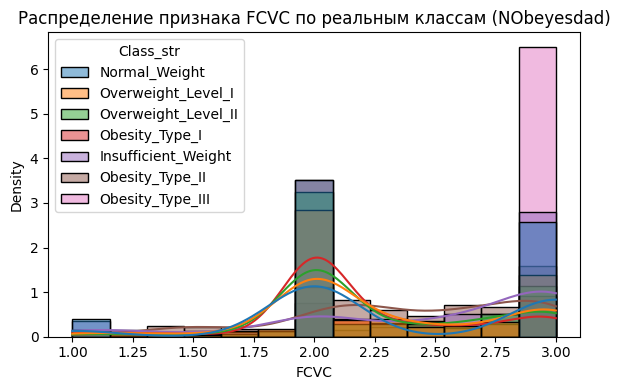

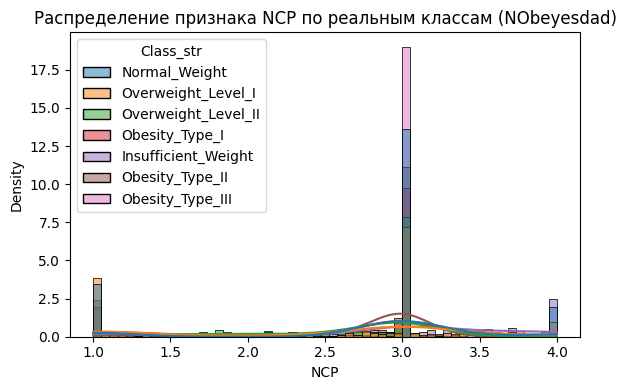

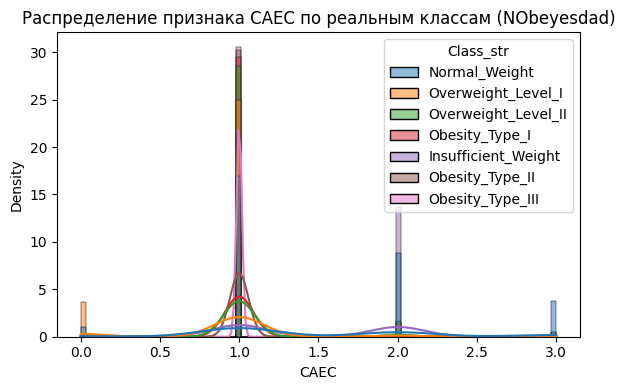

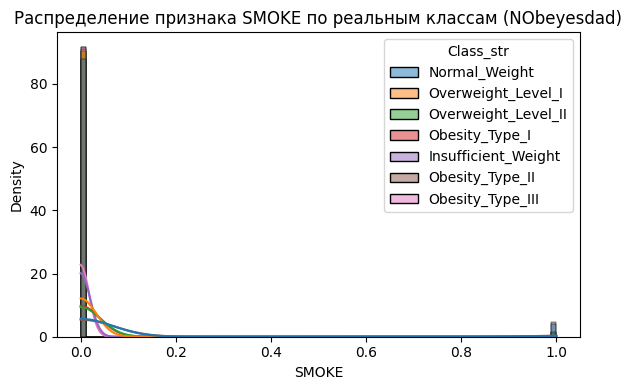

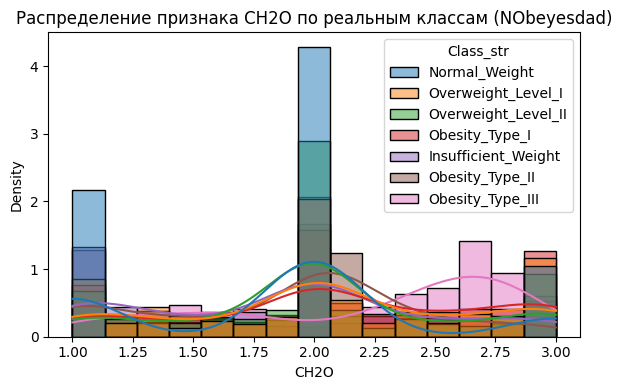

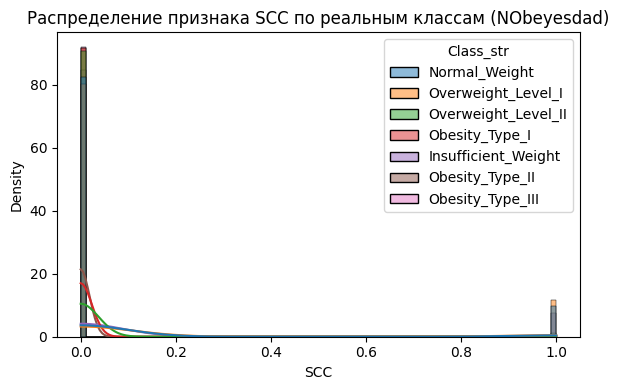

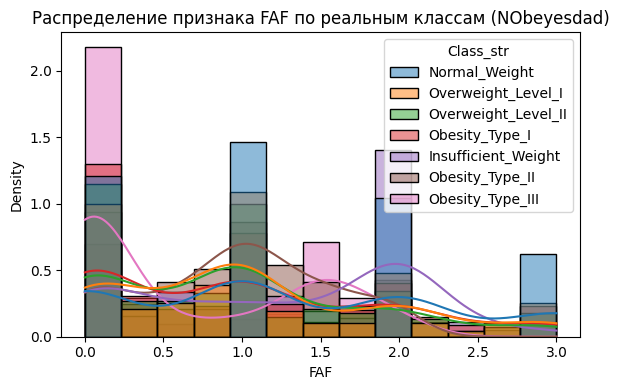

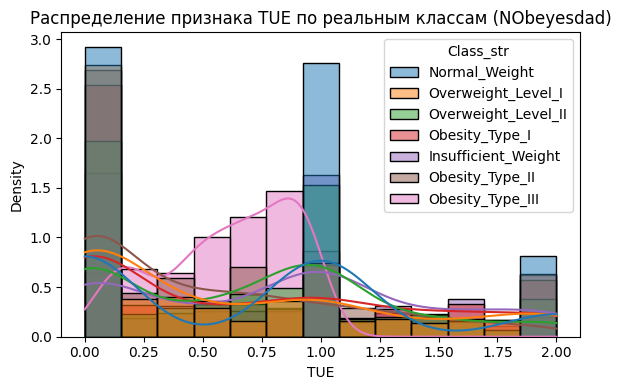

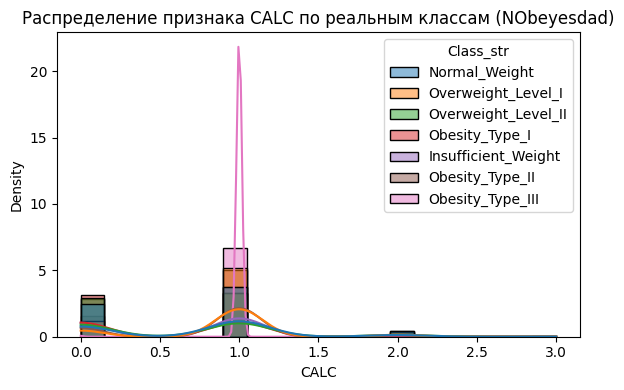

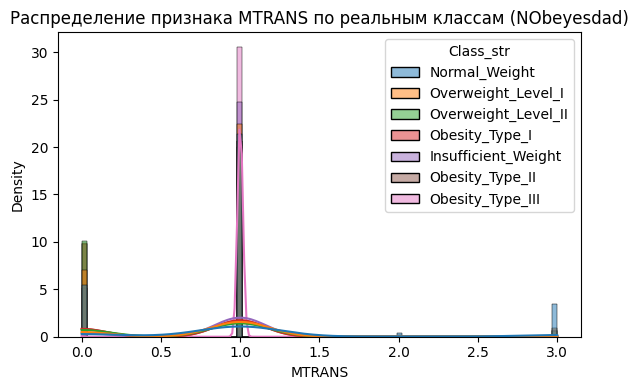

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

# =========================
# 1. Загрузка датасета
# =========================

obesity_data = fetch_ucirepo(id=544)

X = obesity_data.data.features    # признаки
y = obesity_data.data.targets     # таргет NObeyesdad (строковый)

df = pd.concat([X, y], axis=1)

print("Первые строки исходного датасета:")
display(df.head())

target_col = y.columns[0]  # 'NObeyesdad'

# =========================
# 2. Семантическое кодирование категорий (как делали раньше)
# =========================

df_mapped = df.copy()

# 2.1. Gender: Female=0, Male=1
gender_map = {"Female": 0, "Male": 1}
df_mapped["Gender"] = df_mapped["Gender"].map(gender_map)

# 2.2. Бинарные yes/no -> 1/0
binary_map = {"no": 0, "yes": 1}
for col in ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]:
    df_mapped[col] = df_mapped[col].map(binary_map)

# 2.3. Упорядоченные частоты: no < Sometimes < Frequently < Always
ordinal_freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_mapped["CAEC"] = df_mapped["CAEC"].map(ordinal_freq_map)
df_mapped["CALC"] = df_mapped["CALC"].map(ordinal_freq_map)

# 2.4. Транспорт по "активности"
mtrans_map = {
    "Automobile": 0,
    "Motorbike": 0,
    "Public_Transportation": 1,
    "Bike": 2,
    "Walking": 3,
}
df_mapped["MTRANS"] = df_mapped["MTRANS"].map(mtrans_map)

# 2.5. Таргет NObeyesdad: шкала тяжести
obesity_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6,
}
df_mapped[target_col] = df_mapped[target_col].map(obesity_map)

# 2.6. Убираем Weight (как ты делала) — из признаков
# сам столбец можно оставить в df_mapped, но не использовать в кластеризации
print("\nКолонки после кодирования:")
print(df_mapped.columns)

# =========================
# 3. Матрица корреляции
# =========================

# Признаки для кластеризации — все, кроме таргета и Weight
feature_cols = [
    c for c in df_mapped.columns
    if c not in [target_col, "Weight"]  # таргет и вес не используем в X
]

print("\nПризнаки, используемые для кластеризации (без таргета и без Weight):")
print(feature_cols)

# 3.1. Корреляция по всем используемым признакам (ТОЛЬКО фичи)
corr_feats = df_mapped[feature_cols].corr()

print("\nМатрица корреляции по признакам (без таргета):")
display(corr_feats.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_feats,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции признаков (Obesity, без таргета)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3.2. Корреляция по ВСЕМ числовым столбцам, включая таргет и Weight (для анализа)
corr_all = df_mapped.select_dtypes(include=[np.number]).corr()

print("\nМатрица корреляции по всем числовым столбцам (с таргетом и Weight):")
display(corr_all.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_all,
    annot=False,
    cmap="coolwarm",
    square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("Матрица корреляции (все числовые, включая таргет и Weight)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# 4. Подготовка данных для кластеризации
# =========================

X_clust = df_mapped[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_clust)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =========================
# 5. K-Means и средний коэффициент силуэта
# =========================

sil_scores = {}
inertias = {}
k_values = range(2, 11)

print("\nСредний коэффициент силуэта для k-means при разных k:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
    inertias[k] = kmeans.inertia_
    
    print(f"k = {k}: silhouette = {sil:.4f}, inertia = {inertias[k]:.2f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nЛучшее k по среднему силуэту: {best_k} "
      f"(silhouette = {sil_scores[best_k]:.4f})")

# =========================
# 6. Обучаем k-means на лучшем k и готовим датафрейм для графиков
# =========================

kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_best.fit_predict(X_scaled)

df_plot = df_mapped.copy()
df_plot["Cluster"] = cluster_labels.astype(str)        # кластеры k-means
df_plot["Class_str"] = df[target_col]                  # строковый таргет (Normal_Weight и т.д.)

print("\nРаспределение по кластерам (k-means):")
print(df_plot["Cluster"].value_counts())

print("\nРаспределение по классам ожирения:")
print(df_plot["Class_str"].value_counts())

# =========================
# 7. Кластеризованные и классифицированные диаграммы распределения
# =========================

# Чтобы не рисовать миллион графиков, можно ограничиться ключевыми признаками.
# Если хочешь все — просто убери [:N] в циклах.
plot_features = feature_cols  # или, например: ['Age', 'Height', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# 7.1. Кластеризованные (hue = Cluster)
for col in plot_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df_plot,
        x=col,
        hue="Cluster",
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.5
    )
    plt.title(f"Распределение признака {col} по кластерам (k-means, k={best_k})")
    plt.tight_layout()
    plt.show()

# 7.2. Классифицированные (hue = Class_str, реальные классы ожирения)
for col in plot_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df_plot,
        x=col,
        hue="Class_str",
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.5
    )
    plt.title(f"Распределение признака {col} по реальным классам (NObeyesdad)")
    plt.tight_layout()
    plt.show()


Размер датасета: (12330, 18)

Первые строки:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.0

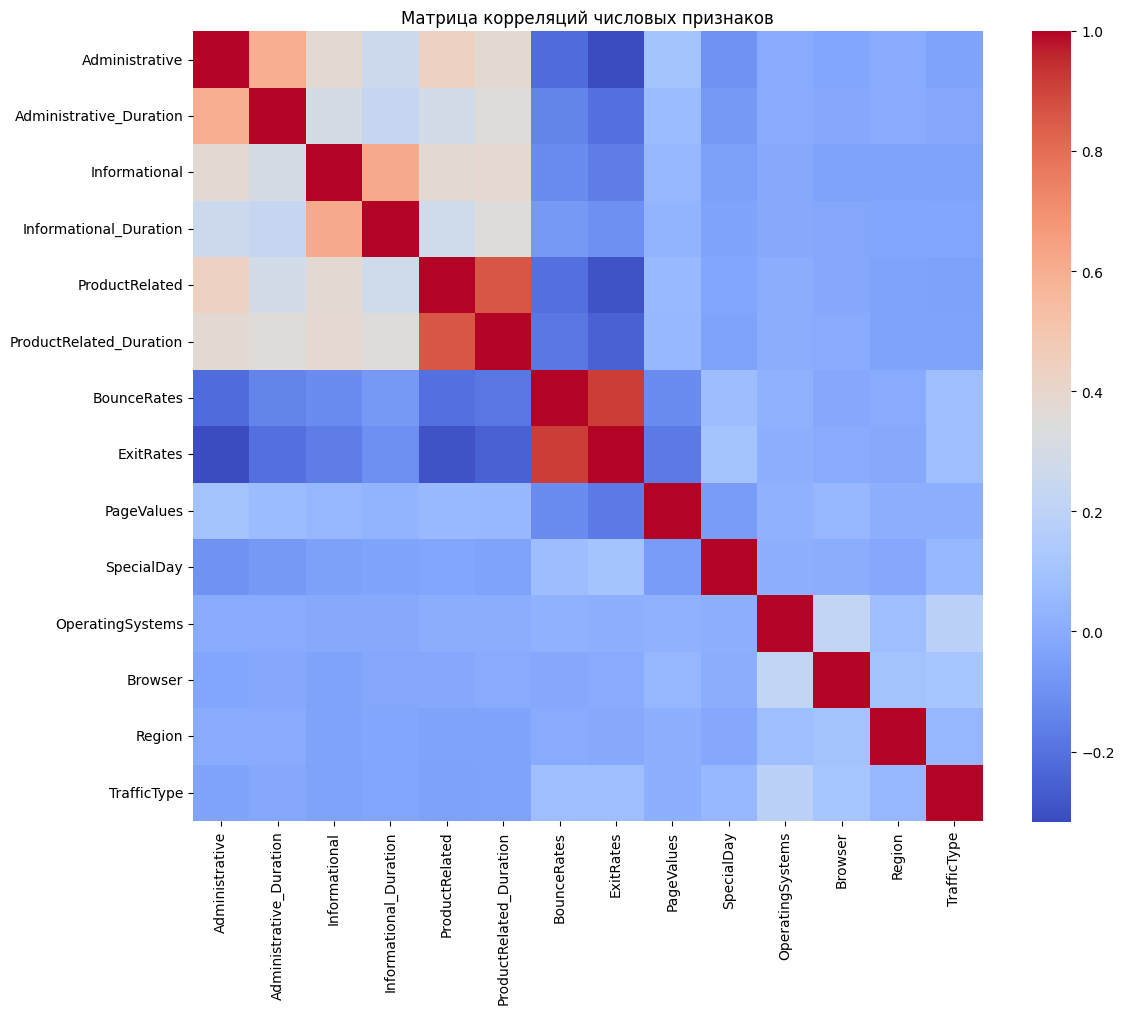

k = 2: средний силуэт = 0.3219
k = 3: средний силуэт = 0.3167
k = 4: средний силуэт = 0.2712
k = 5: средний силуэт = 0.2366
k = 6: средний силуэт = 0.1863
k = 7: средний силуэт = 0.2197
k = 8: средний силуэт = 0.1972
k = 9: средний силуэт = 0.1942
k = 10: средний силуэт = 0.1972


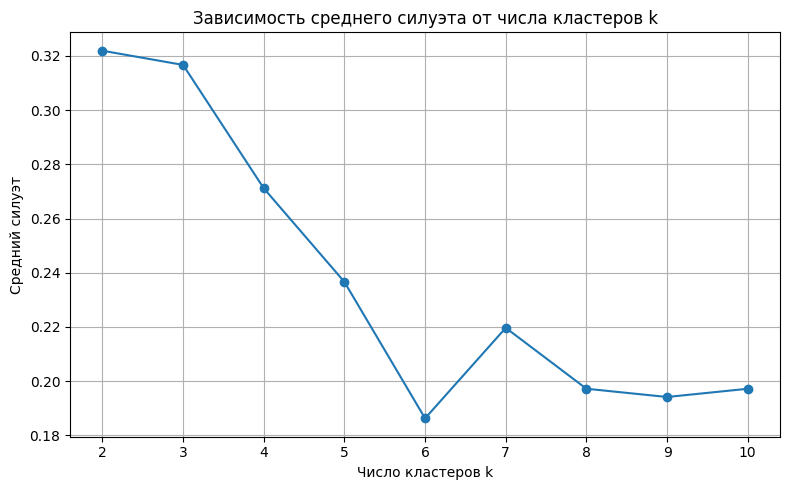


Оптимальное k по силуэту (по максимуму): 2


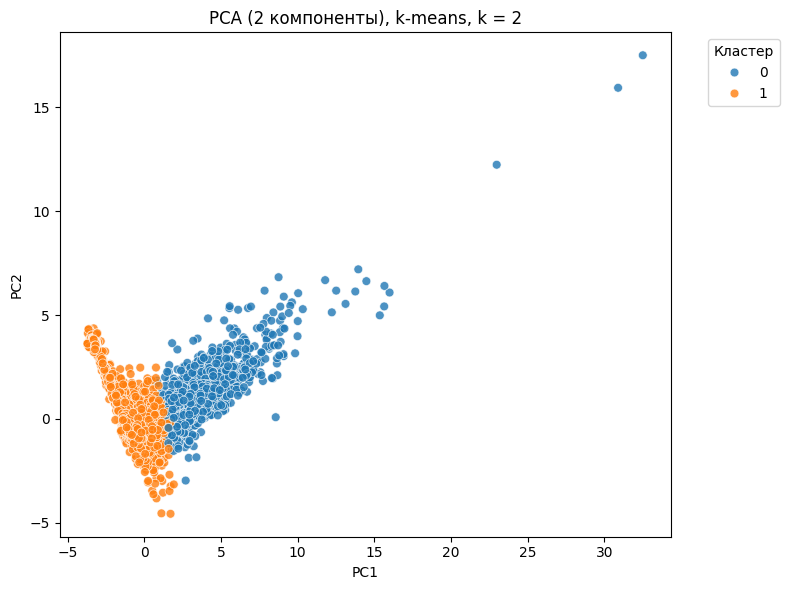

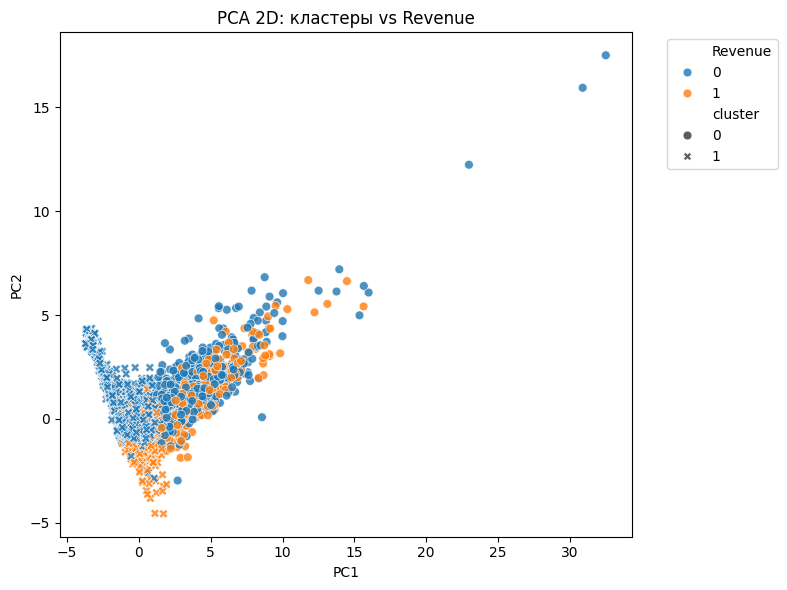

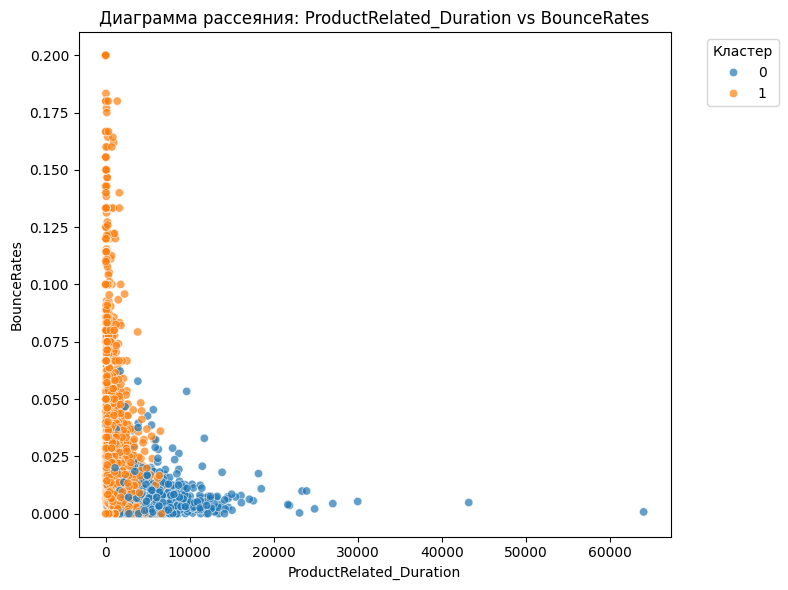

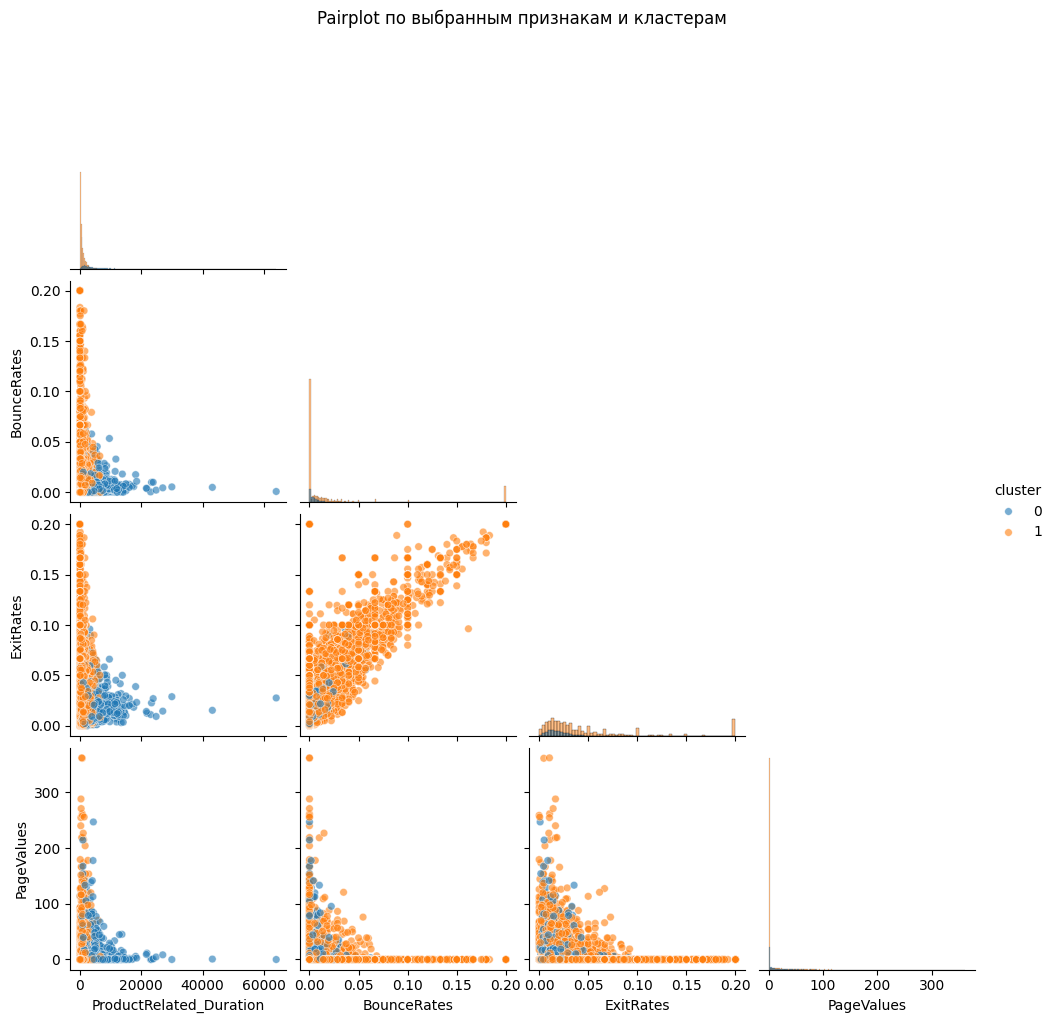

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ==========================
# 1. Загрузка данных
# ==========================
df = pd.read_csv("online_shoppers_intention.csv")

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())

print("\nИнформация о признаках:")
print(df.info())

print("\nОписание числовых признаков:")
print(df.describe().T)

# ==========================
# 2. Матрица корреляций
# ==========================
# Берём только числовые признаки
num_df = df.select_dtypes(include=[np.number]).copy()

# Если есть таргет Revenue и он числовой — можно удалить из корреляции при желании
if "Revenue" in num_df.columns:
    num_df_corr = num_df.drop(columns=["Revenue"])
else:
    num_df_corr = num_df

corr = num_df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", square=True)
plt.title("Матрица корреляций числовых признаков")
plt.tight_layout()
plt.show()

# ==========================
# 3. Подготовка данных для кластеризации
# ==========================
# Вариант попроще: кластеризуем только числовые признаки
X = num_df_corr.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================
# 4. Подбор числа кластеров по среднему силуэту
# ==========================
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"k = {k}: средний силуэт = {sil:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker="o")
plt.xlabel("Число кластеров k")
plt.ylabel("Средний силуэт")
plt.title("Зависимость среднего силуэта от числа кластеров k")
plt.grid(True)
plt.tight_layout()
plt.show()

# Выбираем k с максимальным силуэтом
best_k = k_range[int(np.argmax(silhouette_scores))]
print(f"\nОптимальное k по силуэту (по максимуму): {best_k}")

best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
cluster_labels = best_kmeans.fit_predict(X_scaled)

# Добавим метки кластеров в исходный датафрейм
df["cluster"] = cluster_labels

# ==========================
# 5. Диаграмма рассеяния (PCA 2D)
# ==========================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=40,
    alpha=0.8
)
plt.title(f"PCA (2 компоненты), k-means, k = {best_k}")
plt.legend(title="Кластер", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ==========================
# 6. Доп. диаграмма рассеяния с учётом Revenue (если нужен внешний признак)
# ==========================
if "Revenue" in df.columns:
    # Переведём Revenue в 0/1, если он bool
    if df["Revenue"].dtype == "bool":
        rev = df["Revenue"].astype(int)
    else:
        rev = df["Revenue"]

    pca_df["Revenue"] = rev.values

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="Revenue",
        style="cluster",
        s=40,
        alpha=0.8
    )
    plt.title("PCA 2D: кластеры vs Revenue")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# ==========================
# 7. Простые диаграммы рассеяния по исходным признакам
# (пример: пара признаков для визуальной интерпретации кластеров)
# ==========================
# Выбери признаки, которые тебе интересны
cols_for_scatter = [
    col for col in num_df_corr.columns
    if col in ["ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]
]

if len(cols_for_scatter) >= 2:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df,
        x=cols_for_scatter[0],
        y=cols_for_scatter[1],
        hue="cluster",
        palette="tab10",
        alpha=0.7
    )
    plt.title(f"Диаграмма рассеяния: {cols_for_scatter[0]} vs {cols_for_scatter[1]}")
    plt.legend(title="Кластер", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# ==========================
# 8. (Опционально) Pairplot по нескольким признакам
# ==========================
if len(cols_for_scatter) >= 3:
    sns.pairplot(
        df[cols_for_scatter + ["cluster"]],
        hue="cluster",
        diag_kind="hist",
        corner=True,
        plot_kws={"alpha": 0.6, "s": 30}
    )
    plt.suptitle("Pairplot по выбранным признакам и кластерам", y=1.02)
    plt.show()
